Dylan Ross

Perform basic differential expression analysis (Welch's t-test) to identify top features within each block for all mutation state comparisons.

## Setup

### Imports

In [15]:
import os
import pickle

import polars as pl
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt, rcParams

# set max font size 
rcParams["font.size"] = 7

### Constants

In [16]:
# Jupyter server should be running from src/python
CACHE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache"
)

# cached metadata table 
META_CACHE = os.path.join(CACHE_DIR, "meta.arrow")

# directory for figures
FIGURE_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_figures",
    "volcano"
)

# directory for differentially expressed features
DIFFEX_DIR = os.path.join(
    os.path.dirname(os.path.dirname(os.getcwd())),
    "analysis",
    "dylan",
    "_cache",
    "diffex"
)

# define some colors for plotting
RED = "#AD3838"
BLUE = "#4040B1"
GREY = "#454545"

### Load Data

#### Utility Function: Load a mutant vs. WT comparison data subset, add ∆z and t-test p-value

In [ ]:
def load_data_add_delta_z_and_ttest_p(
    subset_id: str,
    block: str
) :
    """ 
    loads a specified -omics block for a selected data subset, 
    adds ∆z and t-test p-value columns for the comparison of mutant vs. WT samples
    """
    # load subset sample columns
    with open(os.path.join(CACHE_DIR, f"{subset_id}_cols.pkl"), "rb") as pf:
        wt_cols, mut_cols = pickle.load(pf)

    # load subset omics data
    omics_subset = pl.read_ipc(os.path.join(CACHE_DIR, f"{subset_id}.arrow"))

    # select out the block of interest, add columns, return
    return (
        omics_subset
        .filter(pl.col("Block") == block)
        .drop("Block")
        # add the ∆z and t-test p-value columns
        .with_columns(
            (
                pl.concat_list(wt_cols)
                .list.drop_nulls()
                .alias("wt")
            ),
            (
                pl.concat_list(mut_cols)
                .list.drop_nulls()
                .alias("mut")
            ),
        )
        .filter(
            (pl.col("wt").list.len() >= 5)
            & (pl.col("mut").list.len() >= 5)
        )
        .with_columns(
            (
                (
                    pl.col("mut").list.mean() - pl.col("wt").list.mean()
                )
                .alias("delta_z")
            ),
            (
                pl.struct("wt", "mut")
                .map_elements(
                    lambda x: stats.ttest_ind(
                        x["wt"], 
                        x["mut"], 
                        equal_var=False  # Welch's t-test
                    ).pvalue,  # type: ignore
                    return_dtype=pl.Float64
                )
                .alias("ttest_p")
            )
        )
        .drop(
            "wt",
            "mut"
        )
        # correct p-values for multiple comparisons
        # Benjamini-Hochberg
        .with_columns(
            pl.col("ttest_p")
            .map_batches(
                lambda s: pl.Series(stats.false_discovery_control(s.to_numpy()))
            )
            .alias("ttest_p_adj")
        )
    )

#### Load data for all comparisons

In [40]:
comps = {}
for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    "B_FLT3-ITD-WT", 
    "W_FLT3-ITD-WT", 
    "B_FLT3-ITDxNPM1-WT", 
    "W_FLT3-ITDxNPM1-WT"
]:
    for block in [
        "Acetylomics",
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Lipidomics",
        "Metabolomics"
    ]:
        print(f"{subset_id=} {block=}")
        comps[(subset_id, block)] = load_data_add_delta_z_and_ttest_p(subset_id, block)

subset_id='B_NPM1-WT' block='Acetylomics'
subset_id='B_NPM1-WT' block='Transcriptomics'


/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan

subset_id='B_NPM1-WT' block='Proteomics'
subset_id='B_NPM1-WT' block='Phosphoproteomics'
subset_id='B_NPM1-WT' block='Lipidomics'
subset_id='B_NPM1-WT' block='Metabolomics'
subset_id='W_NPM1-WT' block='Acetylomics'
subset_id='W_NPM1-WT' block='Transcriptomics'


/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan

subset_id='W_NPM1-WT' block='Proteomics'
subset_id='W_NPM1-WT' block='Phosphoproteomics'
subset_id='W_NPM1-WT' block='Lipidomics'
subset_id='W_NPM1-WT' block='Metabolomics'
subset_id='B_FLT3-ITD-WT' block='Acetylomics'
subset_id='B_FLT3-ITD-WT' block='Transcriptomics'


...

subset_id='W_FLT3-ITD-WT' block='Proteomics'
subset_id='W_FLT3-ITD-WT' block='Phosphoproteomics'
subset_id='W_FLT3-ITD-WT' block='Lipidomics'
subset_id='W_FLT3-ITD-WT' block='Metabolomics'
subset_id='B_FLT3-ITDxNPM1-WT' block='Acetylomics'
subset_id='B_FLT3-ITDxNPM1-WT' block='Transcriptomics'


/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan

subset_id='B_FLT3-ITDxNPM1-WT' block='Proteomics'
subset_id='B_FLT3-ITDxNPM1-WT' block='Phosphoproteomics'
subset_id='B_FLT3-ITDxNPM1-WT' block='Lipidomics'
subset_id='B_FLT3-ITDxNPM1-WT' block='Metabolomics'
subset_id='W_FLT3-ITDxNPM1-WT' block='Acetylomics'
subset_id='W_FLT3-ITDxNPM1-WT' block='Transcriptomics'


/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan_policy.py:592: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/Users/dylan.ross/Projects/AML_outcome_disparities/260422_prep_PR/amlMultidrugResistance/aml_outcome_disparities/src/python/.venv/lib/python3.13/site-packages/scipy/stats/_axis_nan

subset_id='W_FLT3-ITDxNPM1-WT' block='Proteomics'
subset_id='W_FLT3-ITDxNPM1-WT' block='Phosphoproteomics'
subset_id='W_FLT3-ITDxNPM1-WT' block='Lipidomics'
subset_id='W_FLT3-ITDxNPM1-WT' block='Metabolomics'


## Volcano Plots

### Utility Functions

#### Make the volcano plot

In [41]:
def volcano_plot(
    df: pl.DataFrame, 
    min_abs_delta_z: float, 
    max_p_value: float, 
    adjusted_p: bool,
    figname=None, 
    delta_z_range=None, 
    point_labels=None
) :
    # choose whether to select adjusted or unadjusted p-values
    p_col = "ttest_p_adj" if adjusted_p else "ttest_p"
    # helper: colors
    def _get_color(fold_change, p_value):
        if p_value <= max_p_value:
            if fold_change >= min_abs_delta_z:
                return RED
            if fold_change <= -min_abs_delta_z:
                return BLUE
        # default color
        return GREY
    fig, ax = plt.subplots(figsize=(4, 4))
    c = [
        _get_color(dz, pv)
        for dz, pv in df.select("delta_z", p_col).iter_rows()
    ]
    ax.scatter(df["delta_z"], df[p_col], c="#00000000", marker="o", edgecolors=c, s=6, linewidths=1.)
    # add point labels if provided
    if point_labels is not None:
        for lbl, dz, pv in point_labels.iter_rows():
            ax.plot(
                [dz, dz + 0.2 if dz > 0 else dz - 0.2],
                [pv, pv],
                #c=_get_color(dz, pv),
                c="k",
                lw=0.5, 
                marker=".",
                ms=2
            )
            ax.text(
                dz + 0.15 if dz > 0 else dz - 0.15,
                pv,
                lbl,
                color=_get_color(dz, pv),
                size=6, 
                va="center",
                ha="left" if dz > 0 else "right",
                #rotation=-15 if dz > 0 else 15,
                rotation_mode="anchor", 
                bbox=dict(
                    fc="w",
                    #ec=_get_color(dz, pv),
                    ec="k",
                    lw=0.5,
                    pad=0.3
                )
            )
    ax.set_yscale("log")
    ax.invert_yaxis()
    ax.axhline(max_p_value, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(-min_abs_delta_z, lw=0.5, c="#666666", zorder=-1, ls="--")
    ax.axvline(0, lw=1., c="k", zorder=-1)
    for d in ["top", "left", "right"]:
        ax.spines[d].set_visible(False)
    if delta_z_range is not None:
        ax.set_xlim(delta_z_range)
    ax.set_xlabel("∆z")
    ax.set_ylabel("p-value")
    if figname is not None:
        plt.savefig(figname, bbox_inches="tight", transparent=True, dpi=400)
    plt.show()
    plt.close()

#### Make the plot plus select out the top/bottom features

In [42]:
def plot_volcano_and_select_top_features(
    df,
    dz, 
    pv,
    subset,
    block,
    adjusted_p=False,
    label_top_n=10,
    export_top_n=250
) : 
    # choose whether to select adjusted or unadjusted p-values
    p_col = "ttest_p_adj" if adjusted_p else "ttest_p"
    # select the top up/down features
    top_up = (
        df
        .filter(
            (pl.col(p_col) <= pv)
            & (pl.col("delta_z") >= dz)
        )
    )
    top_down = (
        df
        .filter(
            (pl.col(p_col) <= pv)
            & (pl.col("delta_z") <= -dz)
        )
    )
    # make the plot
    volcano_plot(
        df,
        dz,
        pv,
        adjusted_p=adjusted_p,
        figname=os.path.join(
            FIGURE_DIR, 
            f"{subset}_{block}.png"
        ),
        # add text labels for the top N up and down features 
        point_labels=(
            pl.concat([
                (
                    top_up
                    .select(
                        "Feature",
                        "delta_z",
                        p_col
                    )
                    .sort(p_col)
                    .head(label_top_n)
                ),
                (
                    top_down
                    .select(
                        "Feature",
                        "delta_z",
                        p_col
                    )
                    .sort(p_col)
                    .head(label_top_n)
                ),
            ])
        )
    )
    # write top up/down features to file
    for df, up_or_down in [(top_up, "up"), (top_down, "down")]:
        if len(df) > 0:
            # write just the identified features
            (
                df
                .sort(p_col)
                .head(export_top_n)
                .select("Feature")
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.txt"
                    ),
                    include_header=False
                )
            )
            # write the full table
            (
                df
                .sort(p_col)
                .head(export_top_n)
                .write_csv(
                    os.path.join(
                        DIFFEX_DIR,
                        f"{subset}_{block}_{up_or_down}.csv"
                    ),
                )
            )
    # return the selected top up/down features (+ their full data)
    return top_up, top_down

### Make the volcano plots for selected comparisons

============ B_NPM1-WT ============
Transcriptomics


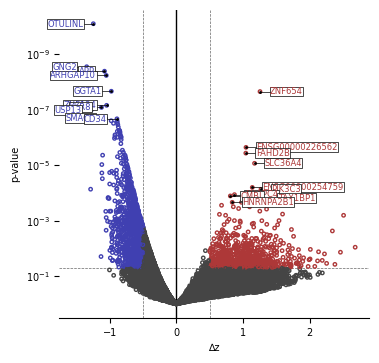

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""NDUFAF7""",null,-0.991452,0.157166,-0.39828,-1.577523,null,0.801231,-0.176396,null,0.492625,null,-0.582581,2.307229,0.534452,1.080005,-0.888015,2.362524,-0.82611,-0.641577,-0.456211,-1.135177,0.847847,-0.49372,3.478906,null,0.169659,null,null,null,null,-0.400863,-0.008583,0.212686,-0.162229,-0.813427,null,…,1.376892,-1.540403,null,-0.735934,-0.566203,null,null,null,-0.863286,-1.082135,0.021798,1.004956,-1.060726,0.751889,-1.158407,null,-0.34889,-0.809343,0.450062,-0.311723,null,null,null,null,0.64548,null,null,0.900462,0.448179,1.214005,0.715825,-0.183455,null,null,0.699753,0.013672,0.238555
"""CDC27""",null,-0.338022,-0.614552,0.031607,2.124105,null,-0.326796,-0.977349,null,0.848493,null,-0.865608,0.519405,-0.600539,0.439431,-0.452783,0.499281,-0.555965,-0.479958,-0.992307,-0.5546,0.761849,0.00615,0.918521,null,-0.883708,null,null,null,null,0.102051,2.947986,0.102414,-1.14312,-0.843376,null,…,1.486753,-1.699659,null,-1.080974,-0.987708,null,null,null,-1.158744,-0.797053,0.370174,0.491629,-0.294349,0.001706,-1.668135,null,0.119981,-0.667602,0.207104,-0.265646,null,null,null,null,2.342513,null,null,1.590578,0.5696,0.849817,0.375145,-0.309402,null,null,1.013618,0.04501,0.402064
"""HCCS""",null,-0.772143,-0.725042,1.010386,2.34866,null,-0.564979,-1.196396,null,0.289525,null,-1.484304,2.343301,0.030755,-0.032876,-1.081535,1.446702,-0.932042,-0.624957,-0.689741,-0.922616,0.937524,1.055565,-0.944395,null,2.053895,null,null,null,null,1.487549,0.48571,-0.195521,-1.34371,-1.116575,null,…,0.220414,-2.077954,null,-0.78966,-1.235693,null,null,null,0.093068,-0.402302,0.7226,1.668673,0.389616,0.609229,0.386763,null,-1.306028,-0.424145,0.253205,-0.787658,null,null,null,null,0.715234,null,null,0.943328,-0.2121,0.326452,1.043539,0.223908,null,null,0.568775,0.039324,0.381109
"""LIG3""",null,-0.858955,1.082478,-0.83223,1.49741,null,-0.042283,-0.220525,null,-0.809619,null,0.095043,-0.313443,-0.80052,-0.142034,-0.602785,-0.004272,0.163768,0.528489,-0.568984,-0.856607,-0.780595,-0.760036,4.6196,null,-0.591193,null,null,null,null,0.29377,0.625549,0.457509,-0.510842,0.080536,null,…,-0.408918,-1.145312,null,0.221976,0.378397,null,null,null,-0.438718,-0.656282,-0.252398,-0.608064,-0.340609,0.006535,-1.231182,null,-0.790063,-0.472591,-0.192446,0.250755,null,null,null,null,1.43985,null,null,1.016292,1.510311,3.04187,0.5441,0.306138,null,null,1.470139,0.012205,0.225757
"""CIAPIN1""",null,-1.331903,-0.356113,-0.617588,-3.261082,null,-0.682191,-0.493065,null,0.1086,null,-0.189866,-0.220423,1.218123,1.097111,0.552251,0.944151,-0.551103,-0.392622,0.22191,1.492654,0.576238,0.530052,1.476962,null,1.337851,null,null,null,null,0.023015,-0.110306,-0.762627,1.437077,-0.778789,null,…,0.953077,-2.485786,null,-0.102764,-0.625107,null,null,null,1.4751,0.004367,-0.694318,-0.668446,-0.181383,0.083619,-0.612846,null,-1.09612,0.142106,0.274133,-1.542712,null,null,null,null,1.219109,null,null,0.605661,0.857691,1.013262,0.054221,0.238478,null,null,0.746133,0.0076

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""KLHL13""",null,-0.64954,0.379956,-0.188343,-0.668779,null,0.018899,0.109502,null,1.924571,null,-0.506758,-0.111719,-0.592535,-0.578996,-0.29082,1.790347,-0.02126,0.177387,0.52679,-0.244269,-0.031734,-0.558153,-0.275459,null,-0.216483,null,null,null,null,-0.082339,3.985946,1.054098,0.327145,-0.214218,null,…,-0.284565,-0.662704,null,-0.637722,0.569714,null,null,null,-0.038326,-0.640416,-0.569403,-0.616235,-0.563693,-0.598521,-0.535928,null,-0.504364,-0.653042,1.14192,-0.184069,null,null,null,null,-0.41421,null,null,-0.578531,-0.597618,-0.270831,-0.554052,-0.482023,null,null,-0.542005,0.001247,0.063683
"""CD38""",null,-0.830895,-0.252257,-0.037754,-0.303425,null,-0.761319,0.727811,null,1.053701,null,0.14829,-0.674078,0.035512,-0.560487,0.526957,1.495515,-0.345326,0.844852,0.347989,0.182776,-0.486335,-0.658368,-0.542382,null,3.32825,null,null,null,null,-0.706347,3.34373,-0.857765,0.866552,-0.104443,null,…,-0.873489,-0.821791,null,-0.468579,-0.576041,null,null,null,-0.656721,-0.08748,-0.657872,-0.473148,-0.56563,0.378498,-0.896695,null,-0.793929,-0.849318,1.166878,0.180314,null,null,null,null,-0.903443,null,null,0.143792,-0.744126,-0.809862,-0.103459,-0.319456,null,null,-0.511941,0.042392,0.394385
"""MCUB""",null,1.075373,-0.40303,-0.232042,-0.648507,null,-1.230942,0.498585,null,0.621986,null,-0.635484,0.741006,0.232768,0.033473,-0.932434,2.65925,0.896884,0.174384,2.595694,0.065138,0.317266,-1.113719,-0.982483,null,-0.446565,null,null,null,null,-1.125249,-0.986798,-0.803019,1.891153,-0.063466,null,…,1.405517,-1.270388,null,-0.582573,-0.76616,null,null,null,-0.598469,0.872959,0.115344,-0.867693,1.826864,-0.293962,1.817799,null,0.553454,1.020501,1.24296,-1.136007,null,null,null,null,-0.728918,null,null,-0.479651,-0.828339,-1.366932,-0.596471,-0.499248,null,null,-0.841754,0.00039,0.033726
"""THSD7A""",null,-0.457245,1.769,-0.518364,0.629519,null,-0.511058,-0.241597,null,-0.511033,null,2.983351,-0.516523,0.127556,-0.444405,5.39141,-0.510236,0.319819,0.641092,-0.516406,-0.192151,-0.515345,0.616932,-0.513349,null,0.846195,null,null,null,null,0.410399,-0.508999,-0.506602,1.406929,-0.413719,null,…,-0.47722,-0.517822,null,-0.513929,0.824683,null,null,null,-0.513005,0.102581,-0.466422,0.288129,-0.210775,-0.514184,-0.515518,null,-0.514696,-0.514151,-0.431717,-0.258834,null,null,null,null,-0.399097,null,null,-0.515142,-0.516549,-0.518364,-0.496683,-0.518364,null,null,-0.554527,0.000627,0.044747
"""GCFC2""",null,-1.168314,0.782821,0.157229,4.675775,null,-0.059765,-0.847088,null,1.294381,null,-0.202836,-1.300436,-0.051768,0.615037,-0.098233,1.885541,0.750511,-0.081345,-0.747687,0.092407,0.05468,-0.717767,0.561565,null,-0.930194,null,null,null,null,0.979458,0.686169,0.706462,0.220897,0.42804,null,…,0.106709,-1.195559,null,-0.246419,1.002571,null,null,null,-0.732633,-0.620295,-0.624988,0.122148,-0.813738,-0.587868,-0.700979,null,-0.377075,-1.045749,1.237991,-1.037707,null,null,null,null,-1.212503,null,null,0.278062,-1.148799,-0.7343,-0

Proteomics


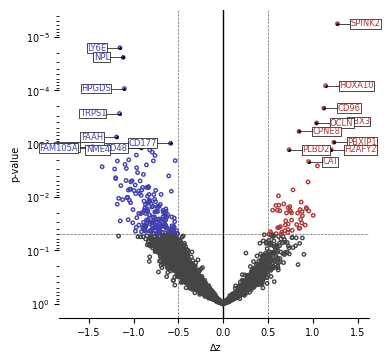

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALDH5A1""",-1.636885,-1.685539,-0.520642,-0.617834,null,null,null,null,null,null,-1.055934,0.295147,0.027569,0.497498,-0.471951,-0.357757,1.000938,-1.570717,0.914959,-0.403026,-0.267776,-0.934058,0.371211,0.972956,0.272329,-0.710898,-1.198361,0.223153,0.554236,0.073548,0.403825,1.186309,1.537115,1.625774,-0.063956,-0.265909,…,0.388004,-0.509326,2.077739,-0.489341,0.178698,-1.809202,-1.281635,-0.131939,-0.515776,-1.042803,0.079512,0.491136,-1.184134,-0.996292,-0.119448,-0.654951,-1.99034,-1.490546,0.998856,-2.43985,2.218574,-0.243718,-0.074936,0.70023,null,null,-0.069435,-0.540156,1.106514,1.976467,1.13383,-0.340791,1.488114,0.641198,0.694735,0.033394,0.999855
"""ARSA""",0.032506,0.781203,-0.745059,0.524555,null,null,null,null,null,null,0.567754,0.629336,0.062353,1.824556,-1.356563,-0.350023,-1.413901,-2.147134,-2.056281,-0.751503,-0.160018,-0.787671,1.210461,0.650755,0.759602,-0.14174,-0.083161,-1.017337,-0.202118,-0.529639,-1.385965,0.54382,-0.330215,-0.534694,0.032385,1.08745,…,-0.702438,-0.983544,0.43603,-1.117548,-2.274589,0.315208,-0.549148,0.589382,0.206795,0.747261,2.192836,-0.947574,-1.061391,0.690121,0.439093,-0.413738,0.472079,-0.808587,-1.034359,-0.139117,-0.194979,-0.672937,-0.011101,0.862634,null,null,-0.150123,0.553751,0.722815,0.220764,0.705577,1.503662,-0.247767,2.451226,0.762858,0.01973,0.999855
"""ATP8B4""",-0.82754,1.191326,-0.580083,-0.031687,null,null,null,null,null,null,-1.644191,-1.002383,-1.761926,-1.259805,-0.814558,-1.718367,-1.236569,-2.551685,-0.182197,-0.79815,1.03107,-1.070946,-0.310645,-0.272563,0.363773,0.53989,-0.998695,-0.930064,0.424567,-0.500973,-2.171013,0.952665,-0.151611,0.28517,-0.522613,1.499142,…,-2.797841,-1.12422,0.267145,0.11061,-1.140175,0.524447,0.066189,1.911065,0.223933,1.145049,0.606927,0.423116,1.101346,-0.350735,0.449943,0.872374,-0.457761,0.840368,-0.319348,0.141629,1.389604,-1.172613,0.127639,0.69232,null,null,0.279617,0.220311,0.262749,2.144563,1.239107,0.899336,-0.216925,1.107627,0.779578,0.007322,0.999855
"""BAHCC1""",-0.262754,-0.531515,null,0.440557,null,null,null,null,null,null,-1.128795,-1.201001,-2.830161,-1.628183,-1.622899,-1.62877,0.65424,-1.102399,-1.065292,-0.281965,-0.861467,-0.113136,-0.448313,0.17752,-0.529111,-0.102937,-1.560273,-1.013206,-0.106594,-0.207385,0.510036,1.328747,0.090256,-0.141892,0.0858,-2.099997,…,-0.165477,1.395153,1.267892,-0.313169,-0.958267,-0.137041,-0.450997,1.486779,1.285272,1.427608,0.818838,-0.190803,-0.071963,-0.373496,0.706285,1.797683,0.5578,1.378678,1.428042,-0.651474,0.470509,-1.518853,0.415498,null,null,null,-0.002395,0.163885,-0.200666,1.206952,0.522402,0.814861,1.216118,0.22385,0.552633,0.017652,0.999855
"""CAT""",-0.131117,0.131812,-0.973319,1.025617,null,null,null,null,null,null,-2.03785,-1.56646,-0.286758,-1.96826,-1.461018,-0.311323,-0.62125,-2.207095,-1.317326,0.769584,-0.439878,-1.447926,-0.820189,0.486788,-0.323553,-0.593299,-0.963967,-1.32495,0.267318,-0.721893,-0.83708,0.360413,-1.157816,2.009841,-1.3184

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABAT""",0.908251,1.18767,null,null,null,null,null,null,null,null,-1.536492,0.268764,-0.208044,1.560516,0.071137,-1.191214,-1.213074,-0.758474,-1.854291,-0.921256,1.028928,0.7821,-0.452642,-1.310555,0.218175,1.008145,-0.288884,0.141115,-1.032421,1.433645,0.17353,0.052259,-1.295965,3.699362,1.629181,-0.036783,…,0.36033,-0.067336,-1.516726,-0.458912,-0.155553,0.752693,-0.388651,-0.39409,0.694024,1.37565,-0.121348,-0.53583,1.120275,-0.58758,0.849934,-0.157022,-0.529227,-0.503317,0.588029,-0.98903,1.149821,-0.89727,-1.481292,null,null,null,-2.28603,-0.353005,-1.145287,0.079779,0.623472,0.051155,-1.232254,-0.125274,-0.745236,0.048531,0.999855
"""ABCB1""",-0.849585,0.015547,-0.395564,-0.898192,null,null,null,null,null,null,-1.679824,-0.251665,0.193138,0.915544,-0.325995,-1.877693,1.327621,-0.847815,1.530777,-0.304214,-0.370946,-0.109135,-0.789633,-0.247103,0.838534,-0.834072,-0.802034,0.756583,-1.008619,0.152007,0.052055,1.088148,1.975611,0.637032,0.377247,0.325839,…,-0.002425,1.142121,2.15251,-0.873016,1.682252,-0.403075,1.339757,-0.042884,0.085292,0.680726,-0.804107,1.711031,0.135673,-0.828339,0.670911,-0.076736,-0.512542,-0.119378,0.691289,-1.521658,1.756305,0.288305,null,-0.073318,null,null,-1.838972,-0.37782,-3.008472,-0.455561,-0.632119,-0.599097,-1.474883,-0.563545,-1.141471,0.006104,0.999855
"""ALOX12""",null,2.43145,null,null,null,null,null,null,null,null,0.432565,0.416826,0.30262,1.363449,0.23977,0.429405,0.034235,-1.463945,-0.58965,1.546862,0.117842,1.52446,1.416487,-0.925613,-0.874908,-0.784071,-0.74623,0.055452,-2.500077,-0.153398,0.222196,-0.913833,1.070116,0.11177,1.937788,0.171355,…,-0.012345,-1.181325,0.960681,0.156305,2.843787,0.472139,-1.264747,-0.184636,-0.100116,0.447489,0.278213,0.050608,-0.208966,-1.205727,0.435118,0.017107,-0.380598,0.077911,-0.79605,-0.460335,0.219084,-0.915812,null,-0.234821,null,null,-1.828784,-1.177702,-0.967485,-0.942971,-0.976509,-0.083319,-0.581378,0.066208,-0.855914,0.002498,0.648893
"""ALOX5""",0.761181,1.280557,-0.555611,1.421964,null,null,null,null,null,null,0.55159,0.462426,-0.656798,-0.464008,0.227109,-1.372554,-1.365004,0.402498,-2.203394,0.673513,1.30237,0.045252,0.79841,-2.028813,0.653021,0.427148,0.440023,-0.255696,-0.539198,0.850824,-0.42299,-0.484289,-1.18039,-0.021081,1.368059,1.870523,…,-1.520767,0.592453,-1.470272,0.242557,0.401072,1.172974,-0.261982,0.578108,1.520512,0.391173,-0.152606,-0.177279,0.62544,-1.401579,0.849598,1.056506,0.902332,1.419148,-1.288494,-0.379355,-1.146939,-0.833295,-0.499819,0.182759,null,null,-2.411655,0.295928,-1.592178,-0.064295,0.151558,0.245596,-2.190603,-0.822271,-0.773651,0.048666,0.999855
"""ANPEP""",0.630306,0.338042,0.997687,0.387941,null,null,null,null,null,null,-2.325397,-1.232857,-1.352032,-2.03428,0.65666,-2.200388,-0.608131,0.569372,-0.196663,-1.500468,-0.251232,0.220313,-1.039174,-1.525449,0.113158,0.33866,0.464311,0.869011,-0.327172,1.149979,-0.230176,-0.092191,0.011338,0.026219,2.225789,1.862844,…,-1.109672,-0.11734,-0

Phosphoproteomics


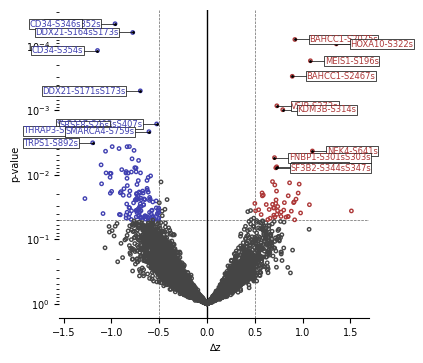

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ARID1B-S1542s""",-0.868959,1.159554,0.476302,-1.042698,null,null,null,null,null,null,-1.015762,-1.466849,-2.438259,-1.032799,-1.585168,-1.707226,1.284633,0.203502,1.620326,-0.433527,-1.76411,-0.385366,-1.031319,0.204357,-1.019384,-0.846112,0.047225,-0.107984,-0.995333,-0.025167,0.92514,0.803573,0.727226,-0.170831,1.728356,-0.418099,…,-1.229327,-0.073547,2.283613,0.393908,-0.656827,-0.591228,-0.002776,1.011684,1.278005,0.142829,0.511004,0.417348,0.060325,0.109754,0.080353,0.495814,-0.43597,0.111562,1.687185,-1.941557,-3.018192,-0.567561,0.413854,-0.570316,null,null,1.504189,0.190279,0.312726,0.302233,0.531716,0.511008,1.358507,0.43857,0.576088,0.019141,0.9999
"""ARID1B-S1710sS1715s""",null,-1.57626,0.269483,null,null,null,null,null,null,null,-1.455307,null,-2.802197,-1.005885,-0.370485,-1.321494,0.534297,null,0.660709,-0.595593,-1.671692,-0.432719,0.872924,null,0.55091,-0.31543,-0.137038,null,-0.821548,null,1.36952,0.20874,null,null,null,null,…,null,-0.535301,1.52568,null,-0.076755,-0.952352,-0.308687,null,0.770545,null,0.996993,0.780279,null,-1.239478,0.282259,-0.850094,-0.551376,null,1.208431,-1.730646,null,0.29583,0.232811,1.732515,null,null,1.53489,null,null,0.733762,0.826135,-0.157157,null,null,0.931181,0.023906,0.9999
"""BAHCC1-S2075s""",null,-0.58789,0.11932,0.242958,null,null,null,null,null,null,-1.504016,null,-2.014588,-1.780984,-0.613034,-1.912709,0.61726,-0.803893,-0.613718,-0.189799,-0.887435,-0.970822,-0.124342,-0.13121,-0.96563,0.387523,-1.507917,-1.108506,0.364823,null,1.26166,1.581598,null,0.728934,-0.736349,null,…,null,-0.119811,1.506884,-0.516223,-1.121959,0.112989,-0.114056,1.437317,0.150892,null,0.821911,-0.350268,null,-0.707768,0.014628,0.236822,-0.871159,null,1.375658,-1.322976,1.98492,-0.921086,0.865073,0.437001,null,null,0.640923,0.442551,null,1.158711,0.562104,0.567005,1.746793,0.671337,0.919268,0.00008,0.155535
"""BAHCC1-S2467s""",-1.673905,null,null,0.115639,null,null,null,null,null,null,-0.608553,0.271333,-2.09602,null,-1.711241,-1.216738,0.822056,-0.484808,-0.34288,0.880922,null,-0.892753,0.207428,-0.103979,-0.993905,null,-1.6395,-0.417913,0.461338,-0.612037,null,1.526063,0.702183,0.610008,0.014548,-2.061676,…,-0.168338,0.151275,null,-1.281223,-1.149027,-0.679175,0.163815,0.956333,-0.37828,-0.127769,0.802121,-0.964425,1.0312,-0.936144,0.170895,null,-0.545553,-0.177366,1.773592,-0.549172,-0.326648,null,1.094408,1.136995,null,null,null,0.610634,-0.030686,0.730374,0.97953,null,0.427897,1.265628,0.891936,0.000297,0.309044
"""CTSD-S359s""",-1.34327,-0.680464,-0.282922,-0.60878,null,null,null,null,null,null,-1.166514,-0.535018,null,null,-0.974751,-0.719,-0.309946,-1.529801,0.263434,-0.252181,null,-2.679967,0.022816,1.629379,0.69646,null,-0.716513,-0.071072,0.581823,-0.76419,null,1.47806,-0.857833,-0.329114,-0.133959,1.571915,…,-0.597044,-0.645998,null,-0.45743,-1.079416,-0.263102,-0.460048,1.206874,0.204888,0.109863,0.867143,0.820144,-1.137834,-0.315008,-0.437387,null,-0.284566,-1.20641,-0.108

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AKNA-S997s""",null,0.206186,0.311829,null,null,null,null,null,null,null,null,-1.234736,-2.643,0.776028,null,null,null,-0.37643,-0.110973,null,-1.950341,0.068781,null,0.274946,-1.360975,0.186214,null,-0.325547,null,0.360363,1.484786,0.557275,0.017389,1.416285,1.404402,-0.022988,…,0.733307,null,1.518316,-0.925533,null,null,-0.576778,0.605569,null,1.464341,0.402349,null,1.720882,null,0.223333,1.193532,null,0.442847,null,-1.548755,0.000036,0.544847,-0.346285,-0.783457,null,null,-1.230675,-0.734348,-1.776831,0.197333,-0.069099,-0.695161,0.252818,0.328897,-0.601319,0.038321,0.9999
"""ANK1-S856s""",null,0.07654,null,null,null,null,null,null,null,null,-2.931432,-1.037881,-1.072333,-1.277982,-0.669521,-0.225492,-1.206764,-0.700961,-0.318649,-0.379743,-0.169197,-0.169612,-0.568872,-0.680365,0.018828,-0.335581,-0.766511,0.270514,-0.127725,0.148375,1.503725,2.290998,-0.792573,-0.241906,-0.157678,2.021847,…,-0.807096,-0.370263,0.396823,-0.897426,0.522731,-0.434921,-0.132236,1.766617,0.277416,1.148879,-0.213992,0.018634,0.161662,-0.095997,-0.043778,2.503034,-0.155354,0.434236,0.941317,-1.014191,0.48267,-0.607444,-0.422065,-0.259271,null,null,-1.371527,0.220791,-1.970918,-0.202992,0.159892,-0.482401,-2.009961,0.213411,-0.711295,0.03397,0.9999
"""ANXA2-S26s""",-0.081824,-0.884722,1.860987,-0.577806,null,null,null,null,null,null,-0.420036,-0.857682,-1.484371,-0.171234,-1.092629,-1.514279,-0.860931,0.106896,-0.86644,-1.138894,0.050632,-0.350113,-0.549726,-0.659232,-1.440322,0.009025,-0.367962,0.412424,-1.197959,0.020887,1.529421,-0.258081,-0.909883,0.896671,2.438888,-0.442671,…,0.841811,0.202968,-0.349598,-1.017568,-0.123612,1.781337,-0.044324,1.121914,1.368319,1.708346,-0.193324,1.557757,1.864785,0.245134,1.215203,1.429861,-0.34843,1.573426,1.38133,-1.211554,-0.849517,0.301034,-0.35084,-0.062175,null,null,-2.425815,-0.578941,-1.52029,-0.123047,0.065516,0.508862,-1.264492,-0.347787,-0.703732,0.037782,0.9999
"""ARID4A-S147s""",-1.33144,-0.959047,null,0.173085,null,null,null,null,null,null,-0.426541,-1.173717,null,0.572367,-0.237356,-1.444448,-0.393398,-0.501269,0.587005,1.056436,0.810427,0.805116,0.672004,0.74105,-0.773416,1.520762,-0.38096,0.687472,0.512012,1.964526,1.96802,1.200897,0.972129,0.730527,0.209087,-0.066847,…,1.408006,-0.494647,0.774714,0.133334,-0.991443,0.131595,-0.349909,0.676394,-0.44932,-0.13494,0.515976,-0.122538,0.358405,-1.203856,-0.8122,-0.97095,-0.533879,-2.164895,-0.422599,-1.932578,-3.214115,-0.154581,null,null,null,null,-1.272217,-0.586527,-1.129857,-0.901564,-0.178718,-0.510936,0.354928,-0.228492,-0.627362,0.016271,0.9999
"""ATAD5-S356s""",-1.518198,0.269186,-0.571606,null,null,null,null,null,null,null,null,-1.299127,-1.424508,null,-0.431507,-2.430218,0.83649,0.458639,-0.057294,-0.309408,null,-0.394063,-0.209983,0.433052,-0.948803,null,null,0.426919,null,1.059603,null,1.435663,-0.753003,-0.227173,0.592618,0.252375,…,-0.627036,-0.547463,null,-0.091617,null,0.267991,-0.568251,2.917167,null,0.774259,0.210848,n

Acetylomics


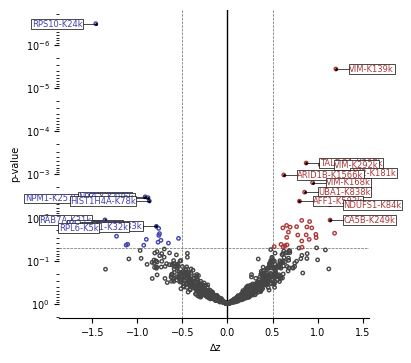

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACADVL-K278k""",null,null,-0.558571,-1.446914,null,null,null,null,null,null,0.366006,0.244718,0.293471,1.422577,-0.079951,-1.91651,-0.886565,-1.047041,0.562909,-0.975941,0.174007,0.46546,0.707448,0.543218,0.318328,0.958388,-0.204386,-0.399425,0.395759,-0.00752,0.092212,-0.706294,0.504962,1.254531,-0.516901,-1.462531,…,0.329567,0.598718,-1.225687,-0.093939,-0.113427,-0.856787,-1.891903,-0.748777,-0.445648,-0.827466,1.615464,0.685283,-0.449116,0.281045,0.328865,-1.000903,-0.926497,-0.089373,1.630105,-2.37135,1.407588,0.704384,-1.446914,1.983679,null,null,0.080571,0.894905,0.975936,0.545286,0.695717,0.315873,1.948119,1.546314,0.873623,0.025421,0.653733
"""AFF1-K582k""",0.370778,null,1.344913,1.269822,null,null,null,null,null,null,-1.226366,-0.622428,null,-0.276548,0.569096,-0.21576,-1.17436,0.585976,-0.406008,0.104296,-0.788378,-0.266133,-0.417087,0.664092,-1.621137,-0.883658,0.532529,-0.253741,-0.384698,0.043109,0.403737,-0.111706,0.46968,0.017484,1.30474,-2.094513,…,0.035064,-1.605444,0.971317,0.157912,0.065308,0.21857,0.549936,0.929233,0.843183,0.665819,0.694846,0.764781,0.922932,0.416489,0.30287,-1.385447,0.180432,-0.01287,1.061572,-0.866482,-2.996234,1.826926,null,null,null,null,0.517194,0.491279,0.798617,0.967516,-0.247408,0.898369,0.532963,1.712071,0.798835,0.004203,0.291291
"""AK2-K181k""",-0.557482,-0.777492,0.564708,null,null,null,null,null,null,null,-0.386948,-0.968084,-3.396061,0.199957,0.096749,-0.175031,-0.396669,-1.117557,0.244363,-0.225252,-0.039226,0.12187,1.133976,1.884882,0.297831,0.925052,-0.157751,-0.381382,0.499187,-0.575541,-0.736357,1.27909,-0.185122,0.120403,-0.273114,-0.288184,…,-0.786493,-0.552273,1.411012,0.881598,0.160986,0.669604,-0.750883,-1.14253,-0.847489,-0.980398,0.705638,0.77122,1.356134,1.35926,1.268824,-1.790954,-0.961531,-1.736324,-0.958142,-1.075589,-1.172594,0.546664,null,2.288813,null,null,0.234252,0.154374,0.932538,1.078301,1.575486,0.248783,1.27096,1.840408,1.219697,0.000948,0.156674
"""ARID1B-K1566k""",null,null,2.741034,0.538009,null,null,null,null,null,null,0.178414,-0.718831,null,null,0.539944,-0.738847,0.080173,0.538825,null,-0.049291,null,null,1.038277,-0.390835,null,null,-0.246043,-0.400144,1.055226,-0.188021,null,null,1.403142,0.08457,0.323999,-0.684583,…,0.365591,-0.926312,null,-0.331379,0.462882,-0.932231,null,2.423499,-0.606213,-1.964566,null,0.243851,-1.690628,-1.059002,null,null,-0.754649,0.24061,0.310901,null,-0.826762,null,0.840802,null,null,null,null,0.453946,0.514087,null,null,null,0.406541,0.584424,0.625072,0.001043,0.156674
"""CA5B-K249k""",null,null,0.333966,null,null,null,null,null,null,null,-0.112636,0.576445,-0.754029,-0.252424,-0.465374,0.218639,-1.242142,-0.174479,-0.277932,-1.730394,-0.281373,-0.913114,1.555721,-0.373882,0.553658,1.09441,-0.678739,-0.312877,0.216482,-0.420225,0.116541,0.229124,-0.330446,-0.477018,0.969148,-2.066543,…,0.731196,-2.149122,0.201688,1.1823,0.062203,-0.325891,0.336685,0.141649,0.392448,-0.15601,2.263548,1.115771,-0.585486

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACOT8-K52k""",null,0.907459,0.255254,null,null,null,null,null,null,null,-0.572861,null,-1.204041,-1.371107,null,null,null,1.58106,-0.577175,null,0.308931,-1.186283,-0.109124,-1.306874,-0.690068,-0.179167,-0.075082,-0.958942,0.124029,-0.385549,-3.420031,-0.26125,null,-0.686884,0.262831,0.726482,…,-1.380388,null,0.560031,-0.821217,1.188158,null,0.423531,0.391681,0.894237,-0.177253,-0.085566,-0.556535,-0.113264,-0.07799,0.677275,1.192764,1.22455,0.86058,null,3.125266,1.171316,-0.917325,null,null,null,null,-0.509972,-1.8311,null,-1.074118,0.242672,-0.578618,-0.083054,-0.889268,-0.762251,0.02612,0.653733
"""ANXA6-K299k""",-0.33181,null,-1.170909,1.519068,null,null,null,null,null,null,-0.56821,1.284269,1.53785,0.337355,1.911232,-0.590139,0.267341,0.492639,0.105828,0.556754,1.659559,1.918436,0.955252,-1.247347,2.380349,1.670231,1.26651,-0.54508,-0.576343,1.411202,-0.385545,-1.446047,-1.790954,-0.709695,2.188123,-0.562815,…,-0.920148,0.803138,-0.16931,-0.167559,0.226226,-0.877721,-0.255052,-0.028102,-0.606498,0.270102,-1.279633,0.20658,0.459504,-0.95132,-0.39313,-0.238034,0.566348,1.102397,-1.144913,-1.850415,-0.19679,-0.48664,null,0.464771,null,null,null,-1.432279,-0.562959,-0.692263,0.082313,-0.23364,-1.630663,-0.657606,-0.65564,0.039341,0.770568
"""BLVRA-K269k""",1.178042,-0.776423,1.394786,3.562225,null,null,null,null,null,null,1.120851,null,0.331827,0.33379,0.351155,0.896968,-0.495853,0.887229,-0.56112,0.362552,0.309786,-0.327075,1.179005,-1.194402,1.944582,-0.680502,0.249302,0.324864,-1.446943,0.319782,-0.899752,-0.0599,0.098598,0.320938,0.466876,0.775078,…,-0.754778,-0.486032,-1.535567,0.202735,1.179819,1.435134,1.275015,-0.866586,-0.789093,-0.64519,-0.61722,-0.695995,0.176838,-0.472287,0.897366,0.964546,-0.575234,0.857048,-1.189865,0.142533,-0.104169,-1.192661,-2.534875,-0.522926,null,null,-2.041233,-0.316211,-2.266113,-1.334435,-0.856759,1.110695,0.579033,0.143237,-0.929577,0.044148,0.779953
"""CANX-K170k""",null,0.61352,null,2.010855,null,null,null,null,null,null,null,null,null,-0.909638,-1.098486,-0.092816,-0.330105,0.304551,null,0.808617,0.768438,null,-0.573383,-0.913009,null,0.728913,null,-0.516109,null,-1.239436,-0.310983,null,0.311151,-0.958305,0.240408,0.449167,…,0.751996,-0.248067,0.407882,0.27762,null,-0.341393,null,2.713797,null,-0.618843,null,null,-0.149003,0.859034,null,-0.43838,null,-0.733098,-1.697754,null,-1.034335,-1.553452,null,-1.633463,null,null,-0.348627,-0.468691,0.556063,null,null,-0.589943,-1.524533,-0.597694,-0.77049,0.037447,0.74978
"""HIST1H4A-K78k""",null,-1.260672,null,null,null,null,null,null,null,null,0.105123,-0.624438,null,2.784274,-0.049631,-2.270404,0.227094,null,null,0.232347,null,null,0.536755,0.549662,null,null,1.085493,-1.259423,-0.330654,0.182156,-0.664696,null,1.147353,0.418978,0.517366,0.671055,…,0.52906,0.222058,0.083652,1.574015,-0.240453,-0.125351,null,-0.590864,0.771211,-0.310973,null,2.261559,1.291026,-1.233973,null,null,-1.256553,-1.730192,0.206048,null,1.643496,1.156

Lipidomics


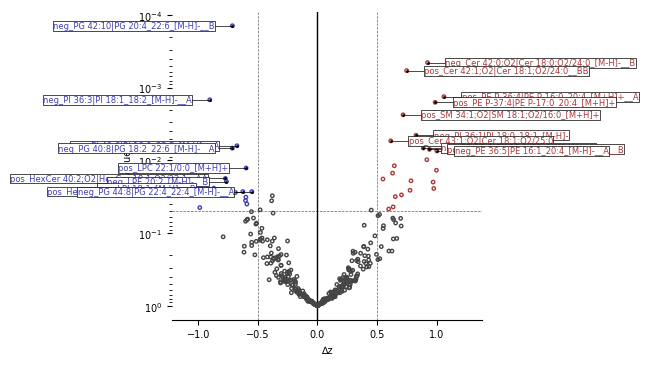

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.18435,null,0.852677,null,-2.468666,-1.980475,-0.90299,-0.459218,-0.874813,0.323036,-0.073667,0.852171,-0.815738,1.202509,-0.364585,-1.142606,-0.890606,-0.799543,-0.46435,-0.265044,-1.114378,-1.288024,0.074244,-0.059613,1.402354,0.446002,-0.516637,-0.956535,-0.839891,-0.528721,0.854735,0.279864,-0.387571,-0.322311,0.04359,0.0595,…,1.103042,0.112821,0.596856,-0.612459,-1.389322,-0.278186,1.210277,-1.359954,0.924322,-1.08676,2.478824,0.512053,0.188655,0.302156,0.245364,-1.0144,0.000409,-1.475517,0.481712,0.032386,2.25479,null,null,null,-0.887282,0.798565,1.858192,-0.635687,1.508183,1.271814,0.349975,0.427862,0.784573,1.298375,0.777083,0.025741,0.31623
"""neg_PG 34:1|PG 16:0_18:1_[M-H]…",-0.187739,null,0.050242,null,-1.819144,-3.05387,-0.912789,0.623155,-0.83366,0.893929,-1.106345,-0.399988,-0.79824,0.060949,0.416028,-0.26987,1.819228,-0.08059,0.648336,0.210139,-0.096195,-0.78182,0.276939,1.131143,-1.318946,0.058516,-0.384283,-0.271766,-0.345697,-0.298216,0.490249,0.811857,0.0232,-0.115382,-0.328059,-2.055953,…,0.721722,-0.698045,1.388893,0.66785,-2.253895,0.130198,-1.575813,0.022791,0.416943,-0.945085,-0.231697,0.63961,0.261862,2.045512,-0.29049,-0.031893,-0.281114,-0.473914,0.59292,-0.817331,1.596201,null,null,null,-0.849663,1.393401,2.009224,0.403648,-0.05107,-0.161836,1.056758,1.453125,2.392807,1.059018,0.998562,0.013647,0.260052
"""neg_PE 36:5|PE 16:1_20:4_[M-H]…",-1.702495,null,-0.51313,null,1.599926,0.745456,0.63223,1.80622,1.717921,1.583855,-1.436696,0.81537,-0.294098,-0.613113,-0.077921,0.978469,-0.609248,0.500334,0.738179,-0.104674,0.366812,-0.412246,0.179018,0.964931,-0.333065,0.557087,-0.300976,0.672258,1.960123,-0.730473,-0.038119,1.98644,0.825583,0.907777,-0.88732,-1.592258,…,0.196595,-0.435159,-1.624861,0.202881,-1.454633,-1.437103,-0.501322,0.254172,-1.956822,-1.040536,-1.300072,0.013157,0.329224,-0.123096,-0.745103,-0.159885,-1.842501,-0.816732,-1.160815,-0.76651,-0.268898,null,null,null,1.569649,0.671835,0.548935,0.127679,1.195339,1.451339,1.403485,-0.45927,2.47954,-0.256666,1.001596,0.007405,0.181416
"""neg_PI 38:3|PI 18:0_20:3_[M-H]…",-0.042631,null,0.540329,null,-0.939721,-1.505726,0.713462,1.37226,-1.62888,2.187071,-0.848309,0.377104,-0.47445,-0.422751,-1.023594,-0.642314,-0.218642,0.252588,1.834913,-0.295508,-0.721621,-0.427381,0.631919,0.286996,-0.918877,-0.863445,0.93951,0.251182,0.717813,0.061175,-0.025792,1.283179,1.101532,0.714568,0.6409,-0.650697,…,-0.640652,-0.212128,1.428308,-0.535864,-1.341177,-0.197767,1.024189,0.236703,0.170339,-1.072263,2.078754,0.586053,-0.351079,0.599148,0.022823,-1.938687,-1.800841,-1.6168,-0.383615,-1.973951,-0.673483,null,null,null,0.230399,2.46773,2.828171,0.79733,0.314964,1.082635,0.723882,0.054321,0.647602,-0.688208,0.970277,0.019869,0.283961
"""neg_PI 36:1|PI 18:0_18:1_[M-H]…",-0.092944,null,1.025883,null,-2.758405,-0.531446,-0.26754,0.377088,-1.111072,-0.975627,0.900877,-0.038665,1.069213,-1.093574,-0.125252,0.549391,1.873

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPI 18:1_[M-H]-__B""",-0.192176,null,-0.679443,null,null,null,-1.9456,-1.096782,null,null,0.856665,-0.808455,-0.707475,-1.430288,-2.889455,1.172899,-1.363523,-0.846031,-0.232566,-1.395245,0.399035,-0.234046,0.042062,0.137127,0.488433,0.467383,-1.364006,1.07489,0.578572,0.17519,-0.665203,0.494587,0.155608,-0.751223,-0.779181,0.832775,…,0.832828,1.959945,1.072255,-0.458636,0.178202,-0.646816,0.289428,1.064493,1.049533,0.364768,0.191905,0.787427,-1.62434,-1.297221,0.309149,1.070416,2.010791,0.351884,1.616026,0.500546,0.469841,null,null,null,null,-2.863016,-0.574443,-0.671826,-0.582348,0.305228,0.102668,-1.16893,-1.085664,-0.328055,-0.870219,0.02412,0.31623
"""neg_LPE 20:2_[M-H]-__B""",0.149748,null,-0.618175,null,-1.256569,1.70372,-1.01578,0.331478,0.521106,-0.741867,-0.423374,-0.554895,1.653012,-0.074595,-0.666409,0.602429,0.178388,-0.126344,0.552815,-0.328857,-0.265861,-0.358219,-1.371938,-0.209975,-0.773876,0.787041,-0.471227,-0.936926,-0.530202,0.348069,-0.245326,1.598047,0.239504,-0.600951,-1.262712,-0.574292,…,-1.245616,0.56514,0.360629,1.131789,1.755441,-0.307985,0.646669,-0.635749,0.222452,1.119198,-0.763462,-1.300445,-0.862817,-1.285094,-0.543449,-0.020171,1.018323,0.709875,3.793831,-0.199767,0.884547,null,null,null,0.878495,-1.930045,-1.054398,-0.387597,-0.04625,-0.666851,-1.686385,-0.16519,-0.491049,-1.108334,-0.763666,0.019509,0.283961
"""neg_PG 42:10|PG 20:4_22:6_[M-H…",0.347396,null,0.749373,null,0.512516,0.171182,-0.508622,0.030227,0.215251,-0.113265,2.378351,0.584806,null,1.587046,-0.125514,0.127634,-1.517862,1.413877,-1.734428,0.999647,0.891677,2.258667,1.458434,0.329331,2.423573,1.184204,0.197438,1.410817,0.475015,0.437931,1.056838,-0.035828,-1.01379,-1.253043,-0.118926,-0.437401,…,-1.598975,-0.435748,-1.159376,-1.196571,0.037028,-0.530015,-0.987321,-0.269791,-0.065467,-1.740659,-0.659661,0.824577,-0.593259,-1.364343,0.975402,-0.12695,0.560102,-1.803746,-0.596681,0.239507,-0.899428,null,null,null,-0.622988,-0.155464,-0.651791,-1.083093,-0.414178,-0.598413,-0.375554,-1.327171,-0.639646,-0.33922,-0.713401,0.00014,0.048112
"""neg_PG 40:8|PG 18:2_22:6_[M-H]…",0.674639,null,1.485179,null,-0.205839,-1.610096,-2.253761,0.345164,-0.441882,0.357441,1.907526,1.165508,null,1.245419,-0.653333,1.000217,-0.526787,0.496068,-1.547836,0.668242,1.34418,0.769587,0.946994,0.942137,0.418195,1.493066,0.214527,0.844432,0.218116,0.482469,2.113315,0.770184,-1.668108,0.842629,-0.386468,-0.11268,…,-1.685259,-1.734981,0.037512,-0.237844,1.178024,0.26557,-1.375861,0.562966,-0.716655,-0.615687,-0.998913,1.526568,-0.129734,-0.621713,0.332903,0.296087,0.793129,-2.245335,0.652585,0.698017,-1.487843,null,null,null,-1.386625,-0.384525,-0.598371,0.408415,-0.317421,-1.709052,-0.943006,-0.040918,-0.767048,-0.474804,-0.714072,0.006786,0.181416
"""neg_PI 36:4|PI 18:2_18:2_[M-H]…",-1.248855,null,0.362043,null,-1.479671,-0.78242,0.7346,-0.578647,0.315918,-0.840731,1.184269,0.511013,-0.322395,-0.378252,0.424764,0.699567,0.079483,0.125722,

Metabolomics


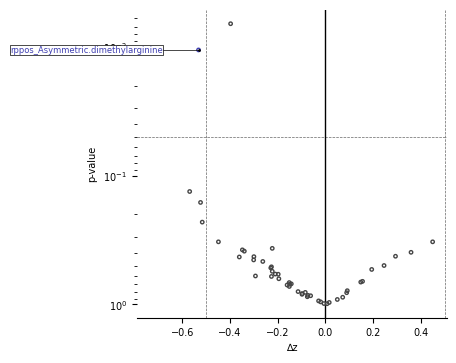

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00611,16-01267,C-00-1828,C-08-0176,C-97-0509,C-08-3381,C-09-1336,C-05-3084,C-05-1893,94-C-376,C-11-2295,C-01-0930,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Asymmetric.dimethylargin…",-0.748212,null,2.329708,null,-1.070975,0.439137,-1.487901,-0.447447,-0.452977,0.566629,0.616603,0.768408,1.336114,-0.458948,-0.580273,0.26682,-0.597199,1.482295,0.493616,0.582129,-0.000548,-1.3204,1.816296,-0.766258,-0.321119,-0.822305,1.701702,-0.084615,-0.052229,0.302268,-0.235249,1.484934,-2.098618,1.931128,0.42029,-1.74585,…,1.179569,1.383112,0.994241,-0.136369,-0.141225,0.54685,-2.180024,0.089168,1.037896,-0.162531,0.721014,-0.367629,-0.188123,-2.198667,-1.645721,-0.253575,-1.098217,-0.225697,1.419581,-1.310104,0.31882,null,null,null,-0.825228,-0.821697,-0.607922,-0.030656,-0.54919,-0.642668,-1.070979,0.382523,-0.563206,0.087988,-0.532354,0.010581,0.259236


============ W_NPM1-WT ============
Transcriptomics


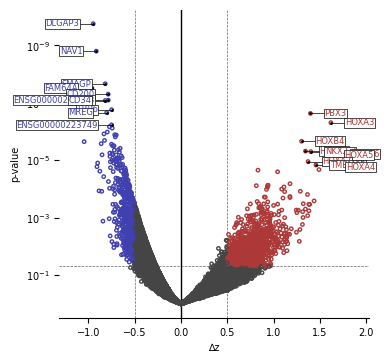

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SARM1""",null,-0.837461,null,-0.604918,-0.809385,null,-0.987276,-0.75683,1.749936,-0.986894,-1.003737,-0.934589,-0.615896,-0.863627,-0.82232,0.08919,-0.980652,-1.146124,null,0.698083,-0.747303,null,null,1.925631,-0.295839,-1.106964,-0.726277,-0.183752,null,-0.954659,0.520534,-0.159802,-0.885019,-0.647794,0.433941,-0.847841,…,3.339065,-0.167746,null,null,null,null,null,null,null,null,null,-0.14684,1.21818,-0.23774,0.203111,-0.07715,0.982391,0.736984,0.602372,1.026964,null,null,2.457364,null,-0.671089,null,-0.170722,-0.308634,0.377678,0.141203,-0.296864,2.402656,0.239365,1.629313,0.676436,0.007751,0.143228
"""PRKAR2B""",null,0.503714,null,-0.798632,1.120153,null,-0.887586,-0.504671,0.40415,-0.650447,-0.335292,-0.409896,-0.012486,-0.447719,0.31674,-0.737546,-0.785861,-0.922408,null,-0.201716,-0.153078,null,null,-0.683756,-0.576543,-0.444218,-0.800271,0.581446,null,-0.476561,-0.720636,-0.457192,4.537025,-0.678193,-0.46339,-0.931814,…,-0.683811,-0.635568,null,null,null,null,null,null,null,null,null,2.227572,0.898274,1.035411,-0.600109,1.135861,1.431075,-0.415318,-0.299986,0.348416,null,null,-0.570652,null,1.213519,null,0.241854,0.160249,0.24626,3.087148,-0.128523,1.10809,2.364695,-0.243671,0.885996,0.002587,0.088121
"""ZFX""",null,-1.286276,null,-0.428567,-1.623073,null,1.079971,-1.026519,-0.687671,0.336518,-0.790803,0.20835,-1.034393,-0.126911,-0.724681,-1.163834,0.875625,-1.427604,null,-1.47981,0.24711,null,null,2.423635,0.213432,2.123609,0.721678,0.496543,null,-1.414081,1.120794,-0.905739,0.147915,-1.639542,-0.347092,0.71417,…,2.085162,-1.486146,null,null,null,null,null,null,null,null,null,-1.457032,0.595614,-0.180995,-0.159031,0.935215,1.595324,1.468436,-0.441497,-0.69323,null,null,1.911237,null,0.648292,null,1.191063,0.245277,0.720517,1.337256,1.084262,-0.163836,0.758778,0.297593,0.648646,0.008743,0.150472
"""LAMP2""",null,0.543403,null,-0.849054,-0.043698,null,3.758948,0.572323,0.44975,-1.245733,-0.306164,-0.906538,-0.631089,-0.692456,0.548026,-0.160516,0.819838,-0.534494,null,0.113179,-0.892797,null,null,0.465972,-0.448576,0.069349,0.641554,-0.313096,null,-0.931864,0.156647,-1.569614,1.766763,-1.563935,1.220583,-0.135549,…,-0.799294,-1.313909,null,null,null,null,null,null,null,null,null,-0.126392,0.77144,0.711161,0.576595,0.679609,1.531701,0.79968,0.18361,1.240071,null,null,-0.773189,null,-0.374195,null,0.082672,-0.818607,1.124348,0.546195,0.529913,0.334335,0.241893,0.432748,0.514834,0.009619,0.155634
"""GDE1""",null,0.75223,null,0.239367,-1.333922,null,1.271979,-0.308431,-0.010192,0.529467,-1.82712,-1.044623,-0.05222,-0.850649,2.687393,-0.081141,-0.923487,-0.495338,null,-1.995355,-0.875357,null,null,0.335336,1.15824,-0.845305,-0.558777,-0.750971,null,0.540126,-0.735988,-0.154363,1.578343,0.556059,-0.096498,-0.573012,…,-0.964144,-0.005688,null,null,null,null,null,null,null,null,null,0.33219,-0.290735,0.38583,1.176442,-0.278201,-0.30587,0.375892,-0.748995,0.544973,null,null,0.346076,null,0.480341,null,2.476955,0.789622,1.635506

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""KLHL13""",null,-0.575132,null,3.601106,-0.516379,null,-0.350739,0.03607,0.229422,-0.084506,-0.46982,0.252338,-0.644411,-0.411554,0.028339,0.095454,-0.638184,-0.635981,null,-0.137446,-0.66369,null,null,-0.414893,3.304048,2.077443,-0.06422,2.020474,null,-0.534176,-0.00004,1.23796,-0.648983,-0.453087,-0.295291,-0.413656,…,-0.464766,-0.573613,null,null,null,null,null,null,null,null,null,-0.636659,-0.111028,-0.58514,-0.578065,-0.474921,-0.314007,0.296744,-0.37766,-0.60872,null,null,-0.509282,null,-0.587663,null,-0.496556,-0.525857,-0.596436,-0.590819,-0.620165,-0.395527,-0.486637,-0.000713,-0.548662,0.000239,0.02466
"""MPO""",null,0.362579,null,0.44832,0.269812,null,5.03725,1.01456,0.541884,0.101605,-0.510915,0.142108,-0.86518,0.466274,-0.866335,0.821241,0.490124,-0.02652,null,1.247348,-0.42351,null,null,0.084534,-0.73126,0.956299,-0.86029,-0.868498,null,-0.676504,0.185863,0.642363,1.983346,-0.684648,0.904704,1.447834,…,-0.843429,1.781097,null,null,null,null,null,null,null,null,null,-0.816329,-0.705899,-0.825739,-0.460051,-0.748552,-0.746603,0.288113,0.176937,-0.388608,null,null,-0.396009,null,0.503839,null,-0.59656,0.451019,-0.725965,-0.382829,-0.79652,-0.848389,-0.846433,0.375883,-0.501123,0.004775,0.115445
"""GCFC2""",null,-0.271534,null,0.475089,-0.748987,null,-0.422563,-0.301492,0.078651,-0.989717,1.208526,-0.194526,-0.878472,-0.66127,-0.534792,0.694902,-1.661172,-0.874878,null,-0.742816,-1.634347,null,null,-0.815505,-0.016482,1.094866,0.099733,-0.294603,null,-1.203236,0.321638,1.676711,-0.551171,0.669653,0.791802,0.985313,…,1.279965,0.023518,null,null,null,null,null,null,null,null,null,-1.329902,-0.395175,-0.084683,-0.503855,0.175093,0.274644,-1.406786,-0.433961,0.044293,null,null,0.65008,null,-0.714375,null,0.724577,-2.00732,0.291991,-0.194499,-1.322642,-0.023351,-0.468626,-1.572578,-0.555218,0.014697,0.191878
"""CD133""",null,-0.789803,null,1.388187,-0.737404,null,-0.784389,-0.093345,-0.103394,-0.30436,1.461371,1.073275,-0.788042,-0.180056,-0.788549,0.274602,-0.599271,-0.456537,null,-0.408384,-0.74171,null,null,-0.787749,0.784273,2.131012,-0.787185,-0.787974,null,-0.769805,1.072063,1.117634,-0.785907,-0.426035,-0.353263,0.620905,…,2.109982,-0.781441,null,null,null,null,null,null,null,null,null,-0.785478,0.111453,-0.450064,0.069106,-0.764899,-0.42389,-0.769656,-0.158723,-0.163639,null,null,-0.785336,null,-0.667121,null,-0.746368,-0.78273,-0.731629,-0.590082,-0.550541,-0.785453,-0.776513,-0.728461,-0.701295,0.000007,0.003549
"""CEACAM21""",null,-0.49846,null,0.294571,1.06512,null,-0.730488,0.482492,0.491832,0.055374,-0.348635,0.62385,-0.496093,-0.438895,-0.874791,-0.077176,1.002208,0.043841,null,2.57076,0.438366,null,null,-0.727143,-0.386258,0.145646,-0.305609,-0.747067,null,-0.668597,0.348306,-0.552722,-0.669878,-0.587398,0.373199,-0.437552,…,-0.539251,0.480672,null,null,null,null,null,null,null,null,null,-0.852333,0.077107,-0.492451,-0.34956,-0.517718,-0.661804,-0.767076,-0.700492,-0.579673,null,null,-0.908842,null,-0.196935,

Proteomics


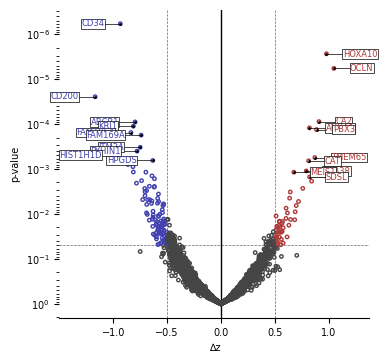

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADAM17""",-0.665392,1.224915,0.905927,-1.289711,-0.580579,-1.034554,-2.76773,-1.485318,-1.072367,2.004734,-0.168518,0.591877,0.483407,0.142449,0.420409,-0.499061,-1.221819,0.104633,1.551389,0.449577,-0.318794,-0.935332,-0.045894,0.144436,-0.877667,0.157169,0.398032,0.955394,0.427359,1.748021,0.147122,-2.282285,-0.462436,0.529315,-1.909896,0.53454,…,-1.441297,-1.242197,0.300899,-0.964804,0.54245,-1.394184,0.318126,-0.605924,0.078689,-0.760506,0.995764,1.735029,1.58869,1.671418,0.35504,0.583932,-0.010711,-0.131985,1.173206,0.575301,0.570328,0.455523,-1.044564,1.567608,-2.289457,-1.322203,1.081462,2.033856,-0.182031,0.376654,1.060139,2.126676,0.947719,-0.17454,0.718819,0.005296,0.911136
"""ADGRE1""",0.212514,-0.319913,0.240618,-0.406769,-0.93078,1.384855,-1.227328,-0.572988,-0.539529,0.519696,-0.320891,1.213798,0.180349,-1.107668,-1.866009,0.321514,-1.676999,-0.433661,1.444539,0.071857,-0.520091,0.012926,-2.283331,-1.335582,-0.578396,-0.700866,-0.219502,-0.006356,1.262056,-0.043022,0.405166,-1.135821,1.684745,-0.386502,-1.421445,-0.298842,…,-0.250656,0.073549,0.106304,-1.176539,-0.733248,0.112746,-0.523765,1.13719,0.223726,-0.782232,-0.373458,2.419594,0.548559,1.014661,-0.779293,0.887638,0.640656,-0.128819,0.147803,1.665655,-0.371706,1.31336,-1.076443,1.4963,-1.221205,-1.945514,0.734654,1.74902,0.08319,1.169133,1.318719,1.552357,2.043523,0.26312,0.687889,0.008997,0.999894
"""ANXA1""",-0.06518,-0.344929,0.957281,-2.142164,-0.211283,-0.536254,-2.376397,-0.702281,0.122102,0.954419,-1.233053,0.106148,-0.827532,-0.636065,0.042115,-0.512114,-1.188125,0.399051,0.828426,0.848993,-0.36088,-1.109749,0.343915,0.665714,-1.112489,-0.025598,-0.298367,-0.575521,1.024904,1.618668,0.839303,-2.293753,0.109387,1.065981,0.135978,1.193013,…,-0.730903,0.538181,0.601621,-2.382338,0.268843,-0.854527,0.160395,1.126109,0.391571,-0.175666,1.148714,1.281232,1.643098,0.516196,0.731983,1.327557,-0.074011,0.533037,1.056968,0.417164,0.378209,0.885557,-0.491742,0.787898,-1.279781,-1.122118,1.532681,1.813539,0.547609,1.398247,0.904882,1.393722,0.342455,0.003081,0.819942,0.000122,0.119046
"""ATP8B4""",-0.790298,2.088681,1.138581,-1.050874,1.365711,-0.27807,-2.467097,-1.317747,-0.09235,1.20482,-0.151848,-0.584371,-0.290392,-0.534578,1.911103,-0.463074,-0.158104,-1.475402,1.286741,0.646915,-0.366161,-0.241496,-0.618284,-0.546736,-1.224743,0.203028,0.780454,1.222834,1.220742,0.385972,0.623506,-2.171634,-0.235286,0.606868,-0.735349,-0.473925,…,-1.920242,-0.072982,-0.03202,-2.707013,0.893792,-0.467925,0.525011,0.229356,-0.271199,0.2122,-0.455179,2.188729,1.523544,1.474958,0.586817,2.157953,0.635725,-0.040278,0.511358,0.17133,0.289802,0.413079,-1.228806,1.150197,-1.261788,-1.230867,-0.129824,1.543692,-0.03137,1.179078,1.097089,0.178071,0.294264,-0.823517,0.5332,0.024717,0.999894
"""BEND5""",0.334537,-1.034769,-0.090292,-1.132711,-2.070787,null,-0.927829,0.099146,0.425883,-2.405819,-1.174425,0.50789,-1.917936,-0.460152,null,-0.176536,-0.354228,0.765829,0.613442,-0.538298,-

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB1""",1.242199,-0.276604,0.014818,0.496685,-0.197465,1.229728,-1.661001,-1.696032,-0.458131,0.990262,1.8688,0.032781,-0.069056,-0.205078,-0.871001,1.724275,null,-0.186125,0.054304,-0.090675,0.05239,-0.15966,1.065066,-1.403031,0.561542,1.9261,-0.607947,0.890605,-0.532857,0.112266,0.578762,-1.51821,-0.845604,0.709689,-0.413098,1.391581,…,-1.284009,-0.612396,2.190476,-1.049977,-0.449838,-1.131008,0.064151,-0.404539,-0.145416,-0.240245,-1.085909,0.517183,0.026922,-0.210375,-0.710001,-1.000752,-0.71029,-0.745064,-0.313236,-0.435649,-1.365115,-1.32168,-1.806276,0.404541,-2.332196,-1.310893,null,-0.365148,0.285544,-0.301275,0.44957,-0.79798,-0.93005,-0.433353,-0.796633,0.00009,0.119046
"""ABI3""",0.044575,0.064387,0.760996,-0.237147,1.021735,1.004611,-0.155803,-0.987911,-1.666024,1.978646,-0.83516,0.668123,1.569287,0.0809,-0.2341,0.425855,-0.973206,0.564091,1.931837,0.700082,0.053814,-0.658503,0.569209,-0.776581,-0.262192,-0.188789,0.241942,0.204719,1.839326,0.766904,-0.201972,-1.849395,-0.123897,1.716547,-1.557149,0.219637,…,-1.98506,-1.04744,0.174295,0.432228,0.046612,-1.182127,1.864389,0.114563,-0.188096,1.123874,-1.751048,0.811165,0.625739,1.533878,-1.095258,0.110025,-1.105796,-1.171008,-0.660578,1.009656,-0.402801,-0.839687,-1.559993,-0.081121,-1.674104,-1.291952,-1.038478,-0.236912,0.272755,0.053614,1.425902,-1.580911,-0.644449,-1.473478,-0.563055,0.018411,0.999894
"""ACY3""",-0.677411,0.014411,0.369566,-1.10196,-0.433711,2.107696,-1.313932,-1.39325,-0.687844,1.371531,2.746766,1.634147,0.341104,-0.15323,-0.724472,-0.305954,-1.37972,0.001026,-0.28601,-0.196973,-0.387401,1.57594,0.823634,-1.180652,-0.083727,2.234612,-0.138471,-0.180916,0.078604,0.317764,1.834311,0.687702,-1.137373,1.327892,-1.705709,0.378834,…,-0.674347,-0.511358,0.507078,-0.617943,-0.905869,-0.966837,null,-0.055469,0.533155,1.553371,-0.824482,0.085516,0.909598,0.118007,0.881792,-0.732288,-0.601376,-1.192405,-0.150394,0.584805,-1.54045,-1.135597,-1.183214,0.39261,-1.653545,-1.765982,-0.363578,-0.245775,-0.088371,-0.541955,0.452196,-1.20164,-0.741817,-1.285464,-0.619796,0.00254,0.639757
"""AGTRAP""",-0.85065,0.265313,1.802697,-0.836056,2.146507,-0.150034,-2.049022,0.248781,1.265485,0.594802,1.044328,0.275145,0.19429,0.40164,-0.061575,-1.192054,0.531611,-0.442434,1.060728,1.778767,0.743067,-0.840942,0.065615,-0.640481,-0.456719,-0.153834,0.28908,0.384794,1.690671,-0.149588,0.457438,-1.123674,0.260161,0.805248,-1.886129,0.876606,…,-1.822711,1.043288,1.060545,-1.35208,-0.150696,1.361417,-0.939787,1.729951,0.724083,1.026792,-0.901615,0.913211,0.355084,0.674144,-0.72813,0.233291,-1.351146,-1.429025,-0.351273,-0.045862,-1.084117,-1.007195,-1.537767,0.370742,-2.735067,-0.738135,-0.114935,-0.029649,-0.251517,0.528471,0.23748,-0.600471,-0.49552,-1.17358,-0.589089,0.005799,0.956623
"""AIF1L""",0.435112,0.244671,1.007247,-0.519597,0.158912,1.189721,0.530207,-1.404789,-0.475074,0.532776,0.54368,0.632032,0.282405,1.160556,-0.827461,0.768149,-1.192135,1.112,0.284147,0.833389,-

Phosphoproteomics


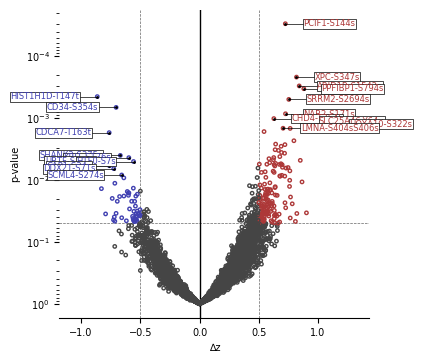

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACIN1-S410s""",-0.080125,0.516113,-0.057046,-0.782353,-2.236067,0.412706,null,null,-2.37341,1.277877,1.244464,0.309406,null,-0.923185,null,-2.773837,-2.214766,0.429939,0.796708,-0.435717,-0.378135,0.167716,0.856411,-0.367019,0.940863,0.76273,0.113318,1.060511,-0.266845,1.470782,0.615756,-0.407694,0.245518,null,-2.414232,-0.110028,…,-1.211095,-1.725097,-0.788052,-1.588792,-1.061046,0.919325,-0.275609,1.287452,-0.348281,0.135508,0.352747,1.242883,0.036777,0.251322,0.527838,0.395598,0.227507,0.750602,0.103042,0.566307,null,1.136265,-0.096015,0.74523,null,-1.6946,1.320951,0.809174,-0.577684,null,0.894982,1.581156,null,-0.207317,0.521632,0.013528,0.999164
"""ADD1-S436s""",-0.681157,0.419594,null,-1.484626,-0.926434,null,null,null,-1.980132,1.735046,null,0.496456,-0.458069,-1.417365,null,-2.555984,-1.888462,null,1.093946,null,null,null,1.206238,null,0.605868,0.704278,-0.192702,1.294015,null,null,0.918901,null,-0.329452,null,-1.774976,-0.930357,…,-0.838214,null,null,-1.195753,-0.296356,-0.039353,0.217512,1.161898,-0.183373,0.210422,0.317451,1.865359,-0.160619,0.826082,1.273653,0.430223,-0.140139,0.57656,0.051965,1.534577,null,0.109,null,1.002339,null,null,0.842217,0.476675,-1.911565,0.392877,null,null,null,-0.525079,0.513409,0.044402,0.999164
"""AHNAK-S210sS216s""",0.000912,null,-0.910179,null,-1.276307,-0.316794,null,null,-1.403047,null,0.595524,null,-0.722186,-0.816741,2.05977,-2.463947,-2.652446,0.89601,null,-0.242864,-1.369839,0.271415,0.344411,-0.660332,0.188281,null,null,1.321522,0.042509,1.71103,0.585302,null,0.433449,null,-1.933024,-0.796738,…,-1.241305,-1.872126,null,-0.050687,1.190413,-0.781309,1.395906,1.09698,-0.317102,-0.330112,0.645698,1.636976,null,0.976623,null,-0.106045,0.083544,0.482398,null,null,0.543497,0.114573,-1.010993,null,null,0.880328,0.955619,1.195152,-0.905537,null,0.61643,1.057793,null,null,0.581593,0.016464,0.999164
"""AHNAK-S5430s""",-0.654094,-0.175374,-0.387775,-1.306584,null,null,-2.114429,0.226238,-0.703024,-2.35686,null,-0.178938,-0.590462,0.081118,null,null,-1.21598,1.532687,1.789352,null,-1.182857,-0.673757,null,null,1.018225,0.321382,-0.395579,0.740544,null,null,null,null,null,null,-1.456155,-0.869396,…,-1.809449,-0.956963,0.785444,null,1.058802,-0.864189,1.660192,1.256813,null,null,null,null,2.497645,0.650959,null,null,1.258218,null,-0.586298,null,null,2.032778,null,null,null,0.022391,0.426395,null,-0.333413,null,1.007097,null,null,null,0.901918,0.033942,0.999164
"""AHNAK-S5448s""",-0.163686,1.040162,-0.379937,-1.388349,-0.747882,0.674906,-2.380552,-1.176104,-1.747432,1.745461,-0.197422,0.01664,0.344823,0.132067,0.797789,-1.590094,-2.024086,0.39617,1.493822,0.341693,-0.646581,-0.15993,0.477345,0.227167,-0.657709,-0.473069,0.349839,1.032855,0.415486,1.201779,-0.458051,-0.719927,0.769657,0.374606,-1.586532,0.451271,…,-1.674442,-0.906747,-0.341333,0.408518,0.288938,-1.763089,0.567856,0.025159,-0.587577,-0.617775,-0.071501,2.02116,1.433591,1.079609,0.723377,-0.166039,-0.071918,-1.35057,0.138813,1.029

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ARHGEF18-S1014s""",null,-0.89489,0.654392,null,null,1.362707,-0.423646,null,null,1.462152,0.20439,1.088866,-0.317951,1.351941,1.305095,-1.237559,null,-0.670965,1.570662,null,-1.639664,0.553119,1.217462,1.139177,1.228915,-1.138096,-1.231363,null,-0.419688,null,0.360245,null,-0.755302,null,0.188324,null,…,null,-0.930838,0.091337,-1.496627,1.211069,null,2.292819,-1.557112,null,1.74077,-1.094603,null,1.344238,-0.361458,null,null,-0.378393,null,-1.577918,null,-0.819376,null,-0.887708,null,null,null,null,0.031354,-1.071223,null,-0.309464,-1.237069,null,null,-0.693995,0.022092,0.999164
"""ATP8A1-S29s""",0.930038,-1.573265,0.94016,0.144411,1.484873,-0.673875,-2.561877,-0.989692,0.353046,0.997027,0.384759,1.431023,-0.805678,-0.358798,0.0204,-1.44479,-0.292,0.055936,-0.999013,1.312219,-0.598498,0.615631,1.526395,-2.342745,1.110185,1.721821,0.13611,1.604885,-0.233537,0.58945,0.557478,-0.829889,-0.264788,-0.344278,-0.739555,1.043889,…,-1.753157,0.185748,-0.094059,-1.279888,0.244121,0.770618,-0.986462,1.613922,-0.811284,0.213809,-0.053547,-0.123077,0.604431,0.461185,1.150641,1.101057,0.179125,-0.921358,-0.883841,-0.284763,-1.337083,-1.726953,-1.595484,-0.849742,-1.589402,-2.284975,0.464171,-0.350583,0.455948,0.533949,0.973755,-1.310068,-0.223361,-2.008513,-0.503095,0.037978,0.999164
"""BAZ1A-S1320s""",-0.34213,-0.031508,0.511837,-1.209071,1.604116,null,null,-1.933373,0.389217,null,null,-0.102619,-0.788544,-1.00639,null,-1.180065,null,-0.293898,-0.492266,0.628056,-0.238926,-1.181307,-0.146389,null,1.090618,null,0.451443,0.012059,null,1.374858,-0.634565,-2.49682,0.529661,-0.286986,0.137761,0.060205,…,-2.790203,2.054696,1.106884,-0.358775,-0.442833,1.390762,-0.477647,1.134259,null,0.452067,null,null,null,-0.207147,-0.957206,-0.380558,-1.521088,-1.218581,-0.327769,-0.297054,null,-0.396515,null,null,-2.100481,-1.314811,null,0.343636,0.25155,0.167642,0.284095,null,0.315056,null,-0.600455,0.016123,0.999164
"""CAMK2G-T382t""",0.31909,1.415155,0.535668,0.03286,0.087214,0.243221,-2.82309,-1.951177,-0.447654,1.199957,null,1.034461,-0.190588,0.195832,-0.299057,-2.09006,null,-0.111523,0.485766,0.560724,-1.056073,0.239622,1.117896,null,-0.365876,0.801653,-0.278688,0.782969,0.809545,0.715432,-0.044766,-1.048234,-0.035905,1.355903,-0.817331,1.277997,…,-2.470006,-2.073392,0.739778,-2.243279,-0.338345,-0.595166,-0.886466,2.113335,0.40187,1.279024,-0.335056,0.560129,-0.349004,-0.004223,1.180699,0.556323,-0.756899,-1.081628,0.336967,-0.678405,-0.239797,-0.522734,null,-0.17322,-2.42511,-2.652186,null,-0.412529,-0.291398,0.87433,0.42343,-1.648906,-1.278514,-0.487633,-0.540834,0.026428,0.999164
"""CAP1-S34s""",0.57958,null,null,-0.993345,1.397907,0.709404,-2.322578,null,1.065753,null,1.294078,-0.087996,0.088049,null,-0.23891,null,-1.690856,null,1.265455,1.307627,null,null,null,-1.252246,-0.638789,null,0.835643,2.113561,-0.369712,0.810445,null,-1.178283,null,null,-0.044458,0.959685,…,-2.130766,null,null,0.976452,1.49855,0.343101,1.466214,1.094238,0.744563,1.067417,

Acetylomics


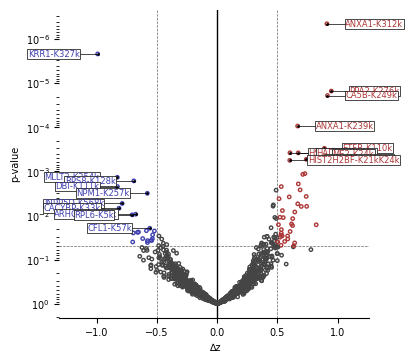

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AK2-K62k""",null,0.293556,null,-0.805706,null,null,null,null,null,-0.452461,0.114833,-0.393368,-0.055881,-1.681596,null,null,null,null,2.665026,-0.48923,null,null,-1.56341,1.466093,-0.493169,0.914558,1.863987,null,null,null,null,null,-0.31195,0.70445,null,-1.392696,…,null,null,-1.235115,-0.725891,-0.570705,null,null,null,null,-1.790083,0.384297,1.383363,0.129278,1.227095,-0.691459,0.59283,null,0.436561,-1.011875,0.068871,null,-0.133358,0.910619,1.601351,null,null,0.556061,0.697884,-0.166188,1.341341,null,null,2.40239,0.42343,0.73907,0.003683,0.153394
"""ANXA1-K161k""",null,-2.517452,null,-1.342926,0.965308,-0.030123,0.152303,0.550476,null,-0.718178,-2.117613,-0.196722,-2.509122,-0.18506,-1.167997,null,null,null,0.569635,null,null,null,null,0.699582,null,-0.49077,-0.114256,null,1.597553,null,null,null,null,0.718741,null,null,…,null,0.946982,0.264758,-4.009466,-0.625318,0.224289,-0.23394,1.123778,0.099313,0.155348,0.379712,-0.256698,0.542146,0.538814,0.602122,0.694584,-0.160903,0.125647,0.424693,0.210197,1.122745,null,1.027783,-0.651539,0.46551,null,1.088592,null,null,2.005722,null,0.248098,-0.190058,-0.288352,0.541194,0.007703,0.225072
"""ANXA1-K239k""",0.19462,-1.643977,1.363615,null,0.976925,-0.513651,null,1.528868,0.983535,-0.7417,-1.005002,-1.049069,-1.941431,0.280728,-0.938901,null,-1.996516,0.285178,-0.535685,0.0438,0.55498,-1.038052,-1.159237,1.20938,-2.128717,-0.575345,-0.828732,null,0.395237,0.475659,0.15507,-1.049069,0.131934,0.094477,1.407682,1.473783,…,0.603454,1.793271,-0.466279,-3.618385,-0.258747,0.783064,null,null,null,-0.458611,0.990145,0.440405,1.300819,-0.297722,0.634302,0.807266,0.097782,0.316576,0.658539,-0.624921,1.113533,-0.231621,1.00667,0.440405,0.838113,null,1.181838,0.385321,1.385649,0.834808,-0.055351,0.600149,-0.206282,0.500998,0.667745,0.000093,0.017436
"""ANXA1-K312k""",0.947525,-1.740429,0.80269,-1.559386,-1.293146,-0.813915,0.032726,null,-0.417751,-0.423076,-2.113164,0.047635,-1.719129,-0.032236,-0.708485,-1.921471,null,0.637622,0.125377,-0.082289,-0.099329,-1.665882,0.381074,1.088099,-0.771317,0.060415,-0.384737,-1.218599,0.421649,0.401734,0.254024,-1.921471,1.276597,-0.234578,1.325585,1.018877,…,1.254232,1.338364,0.280222,-1.10919,-0.404874,0.773939,-0.168882,1.194607,1.0189,0.15873,1.271272,0.550295,1.383092,-0.442245,0.891082,1.078514,0.679155,0.756897,1.300026,-0.057795,1.072125,0.386718,1.06893,-0.221799,-0.474194,null,1.304285,1.174361,0.55988,1.200985,0.847419,1.443795,0.233045,0.761157,0.91125,4.4492e-7,0.000416
"""ANXA1-K97k""",0.433492,null,1.617348,-0.878406,-0.3463,-0.271784,null,null,0.299154,0.086416,null,-0.626521,-2.181907,-0.102812,-1.121894,-0.717829,-0.873158,0.11066,1.375959,1.533387,0.457631,-1.163874,0.074557,null,-1.048427,-0.579293,-0.473292,-2.097945,0.957201,-0.218259,-0.686344,null,-0.23715,1.428435,0.820764,0.426145,…,1.554377,1.470416,null,-2.720848,-0.284374,0.146029,-0.384464,0.90364,0.356357,-0.173362,0.2302,-0.004157,0.125563,0.833358,0.926765,0.683277,0.364224,0.

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ANXA11-K408k""",-0.334804,null,-0.081317,1.384366,0.27989,null,null,null,2.013851,0.73187,null,0.713791,null,null,null,null,1.586524,0.626682,-0.768705,2.09603,0.957039,-1.366963,-0.132974,null,null,-0.046358,0.629969,-0.361101,null,-0.977438,0.23387,null,-0.601061,0.166484,null,-0.389041,…,null,1.931673,null,-2.837643,-0.974921,1.362853,null,null,1.026524,1.509224,-1.703894,0.046668,-0.059276,-0.382467,-0.686527,0.156622,-1.130289,-0.742408,0.230583,-0.87225,null,-1.685814,null,0.549435,1.535574,null,-1.143438,-1.519814,null,0.524781,-0.290427,null,-0.283853,null,-0.538546,0.033299,0.446568
"""ARHGDIB-K30k""",-0.694828,0.480708,null,-1.014306,1.301465,0.78077,null,-0.795437,0.657215,null,1.310291,0.203592,-1.36379,0.450702,0.66604,-0.649819,-1.866835,null,0.789595,0.621913,null,null,-0.971062,-1.178457,0.426873,null,-0.213759,-0.49361,0.476295,2.360507,0.294493,-0.450366,-0.046165,-1.549122,-0.603045,-0.468017,…,1.17791,2.475236,2.31638,1.610869,null,null,null,null,0.63677,1.084343,-2.069818,1.310291,null,-0.85192,-1.129035,-0.310043,0.456879,-0.979887,-1.434393,0.992578,-1.469694,0.966102,0.09857,0.288315,-2.237499,null,-1.213759,-1.23141,-0.587159,-0.881926,null,-0.745133,-0.788377,0.576022,-0.677595,0.009322,0.256348
"""BLVRA-K269k""",0.568471,-1.511207,1.395703,-1.959613,0.56074,0.463327,-0.137151,1.619907,-0.244845,-1.565325,0.668976,1.364779,0.503529,0.270049,0.385243,2.338903,0.885448,-0.561822,0.009509,0.351226,0.908641,0.501983,-0.355401,-1.271541,-0.604344,-1.178768,-1.812721,-1.634905,0.135527,-0.341485,0.800405,0.730825,-1.959613,0.334217,1.233349,0.535227,…,null,-0.350762,-0.326022,1.392458,1.117022,0.731663,-0.087618,0.39088,0.538542,1.25132,null,-0.470595,-0.103056,-0.313653,-0.432712,0.715363,-0.899673,-1.859108,0.877717,0.269276,-0.280409,-2.338439,null,-1.109187,1.789992,null,null,-2.261128,1.418897,-0.395603,-0.331434,-1.248348,-1.619443,-1.580787,-0.619185,0.033275,0.446568
"""CACYBP-K33k""",0.647876,null,0.854809,-0.109648,0.768587,0.412613,null,null,0.808003,0.631863,null,-1.044542,-0.578943,-0.5346,2.390796,0.628168,null,0.442174,0.325159,-0.010985,-1.014981,-2.043488,0.130543,0.243863,null,-0.51366,0.284511,0.666352,0.104676,-0.232822,null,null,0.187203,-0.368314,null,0.410149,…,null,1.368447,null,2.595216,1.271408,1.535089,0.946348,2.255252,null,1.186703,-0.830219,0.084968,-0.285787,-0.158794,0.41754,0.137933,-0.847463,0.299292,0.118225,-1.231768,-1.154168,-0.663933,-0.578943,1.799558,null,null,-0.582638,-4.026598,null,-2.80717,-1.236695,-1.378346,-0.109755,-0.353533,-0.816048,0.00681,0.2054
"""CFL1-K57k""",0.706335,null,null,null,-1.403358,1.180811,-0.268064,null,0.072607,0.399322,1.441855,null,-0.182691,0.095592,-0.42978,null,null,null,null,-2.166788,null,null,-0.421571,null,-1.186642,-1.513357,null,0.855738,-1.097986,-0.444556,-0.331929,null,-2.15037,0.348426,null,0.3238,…,null,-0.692465,null,2.12153,1.203426,0.474378,0.981191,2.084572,1.355326,1.910847,-1.871267,-0.276273,-0.33669,0.24171,0.27783,-0

Lipidomics


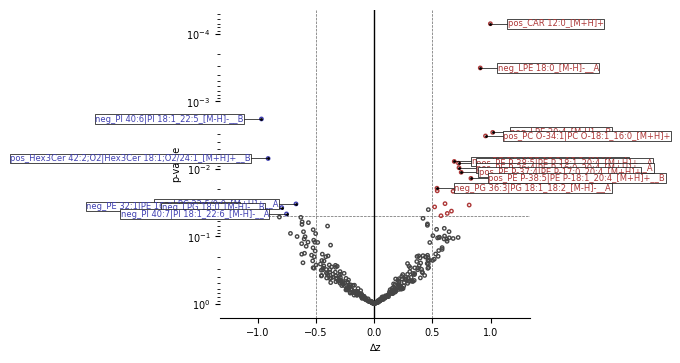

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 20:4_[M-H]-__B""",-1.217959,-1.344691,-0.816427,-1.050415,-0.352358,-0.520437,0.712664,0.246723,0.536047,-0.389379,2.546673,-0.137403,0.437424,0.480711,0.141586,0.840241,0.4177,0.454067,-0.542248,0.546063,1.12477,null,0.313037,0.215781,1.460932,0.143107,-1.357808,0.787002,null,null,null,-0.258605,null,null,null,null,…,null,-1.523733,null,null,null,null,null,null,null,null,0.057187,0.536386,-0.388609,2.05989,-0.11287,1.338484,0.843701,1.111489,1.561326,1.174794,null,null,null,null,null,null,null,null,null,null,null,null,null,null,1.017734,0.002874,0.222692
"""neg_LPE 18:0_[M-H]-__A""",-0.489491,1.490462,-0.608143,-0.188888,-0.10952,0.094944,1.083852,-0.627959,0.238045,-1.661388,0.730095,0.530309,-0.60934,0.823348,-0.565284,1.547882,-1.409107,0.247454,0.476169,-0.521882,0.884824,null,-0.885062,0.729633,-0.230812,0.212418,-2.875961,-0.695956,null,null,null,-0.554893,null,null,null,null,…,null,-2.477141,null,null,null,null,null,null,null,null,0.926342,1.559746,0.113014,0.709191,0.416003,0.871913,0.514576,0.212633,1.512474,0.486398,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.910822,0.000318,0.054587
"""neg_LPE 18:0_[M-H]-__B""",-0.474377,1.20688,-0.158231,-0.124113,0.29288,-1.070393,0.768266,-0.883941,-0.034019,-1.233477,0.021965,0.215701,-0.240262,1.14609,-1.031632,2.521988,-1.216066,0.581769,0.237599,-0.25021,0.728725,null,-0.30664,0.682558,-1.83111,-0.156932,-2.261828,-1.453368,null,null,null,-0.239855,null,null,null,null,…,null,-2.373192,null,null,null,null,null,null,null,null,0.939269,2.696234,0.317452,0.224568,0.182606,0.27757,0.356834,-0.285336,1.256789,0.426274,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.795135,0.01977,0.490573
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-1.133198,-3.220688,0.125181,0.096101,-1.386846,0.420012,-0.117235,-2.337717,1.104003,1.901639,-0.047856,-0.387314,0.366132,-1.075389,0.606893,-0.539675,-0.884714,0.141421,1.215144,1.735924,0.552457,null,-1.227325,1.241136,-0.252752,0.244693,0.639893,-1.249095,null,null,null,-0.206563,null,null,null,null,…,null,0.680682,null,null,null,null,null,null,null,null,-0.768064,0.602299,1.053026,0.937288,-0.1661,0.0311,1.656147,0.60584,0.920917,0.574638,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.677565,0.021454,0.490573
"""neg_PG 36:4|PG 18:2_18:2_[M-H]…",-0.878918,-2.558905,-0.408867,-0.5036,-0.644266,1.594429,0.303072,-2.161344,1.095326,0.856563,-0.248094,0.017941,-0.856501,-0.362979,-0.701365,-0.23365,-1.32585,0.340234,0.599398,1.693076,-0.513086,null,-1.880545,0.505725,-0.723625,0.740769,0.874965,-1.996768,null,null,null,-0.23787,null,null,null,null,…,null,1.876981,null,null,null,null,null,null,null,null,0.334373,1.830326,0.976712,0.072817,0.046423,0.29159,0.90435,0.184603,0.53316,0.353338,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.687591,0.007752,0.35304
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPG 18:0_[M-H]-__B""",-1.316757,0.613966,0.454285,0.708324,-1.543597,-0.7604,-0.934909,1.808597,-0.206104,0.452978,0.056766,1.757304,-0.542691,0.668559,0.092129,-0.479015,-0.455781,0.060028,0.735732,0.042487,0.40827,null,-1.203581,-1.497808,0.103549,0.478839,-0.969824,-0.076105,null,null,null,0.856784,null,null,null,null,…,null,-0.648909,null,null,null,null,null,null,null,null,-0.214526,-1.255442,-0.145961,-1.180484,-1.383335,-0.940859,0.210502,-0.423477,-2.26033,1.220584,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.79278,0.037456,0.611776
"""neg_PI 40:7|PI 18:1_22:6_[M-H]…",0.813278,0.596004,1.298655,0.738478,0.610638,1.416631,-1.353992,-0.388869,-0.206605,-0.427168,-0.049728,1.045813,-0.685876,-0.760736,-0.424438,-0.620316,-0.541353,-0.07748,0.200148,0.173423,-1.703934,null,2.648843,-0.49229,-1.939105,0.860748,1.199807,0.740875,null,null,null,1.184589,null,null,null,null,…,null,-0.107225,null,null,null,null,null,null,null,null,-0.452932,-1.495717,-1.245481,-2.207201,1.305096,0.37247,-0.275381,-0.733292,-0.750555,-0.559939,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.751682,0.046519,0.638247
"""neg_PI 40:6|PI 18:1_22:5_[M-H]…",0.418447,0.179615,1.225305,0.25206,-0.623791,0.001972,-0.070895,-0.406703,-0.952717,0.429583,-0.131546,0.656083,-1.371677,0.917328,-0.444487,1.052729,0.531485,-0.636603,0.336365,0.370596,0.6931,null,2.45676,-1.747753,-0.529379,-1.007443,2.994121,0.498273,null,null,null,1.065194,null,null,null,null,…,null,-0.089113,null,null,null,null,null,null,null,null,-0.284216,-0.942742,0.229484,-1.508664,-0.104943,-0.920156,-1.3941,-0.500445,-0.391193,-1.955459,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.966815,0.001817,0.207784
"""neg_PE 32:1|PE 16:0_16:1_[M-H]…",0.828407,0.935686,0.44954,0.109371,0.770609,0.955123,0.654104,-0.441954,-0.321299,1.476226,0.450193,0.487491,-0.877523,2.005371,0.969156,-0.633826,-1.200982,1.15979,0.586931,-0.356216,0.017669,null,0.832039,-1.34998,0.80411,-0.814782,0.075072,-1.192509,null,null,null,0.708492,null,null,null,null,…,null,-1.673687,null,null,null,null,null,null,null,null,-1.499606,0.384495,-2.313383,-1.67806,0.617605,-1.46787,-1.685738,0.654196,-1.909807,0.855614,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-1.000415,0.036156,0.611776
"""pos_LPC 22:5/0:0_[M+H]+__A""",-1.77279,1.012463,-0.031867,1.75531,-0.397668,0.047477,0.610228,1.811417,-0.786808,-1.491509,-0.640924,0.371107,-0.10658,-0.454644,0.051877,-2.34346,0.45992,0.396727,-1.274515,-0.812415,-0.276425,null,-0.514521,0.573525,0.16037,-0.71337,-0.159911,1.036682,null,null,null,0.827813,null,null,null,null,…,null,-2.07938,null,null,null,null,null,null,null,null,-0.385075,-1.128677,-1.66395,-0.663783,-0.742899,-1.00506,-0.26183,-0.799749,0.146532,1.115827,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.670297,0.033032,0.611776
"""pos_Hex3Cer 42:2;O2|Hex3Cer 18…",0.264564,0.328573,-0.3931

Metabolomics


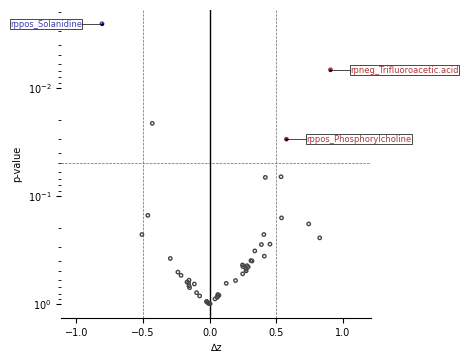

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Phosphorylcholine""",0.072128,-3.055312,-0.72547,-1.094427,-0.026359,-1.240776,0.430148,0.261736,-0.842994,-1.148287,1.429513,-1.874284,-0.029841,1.297002,0.229325,1.52232,0.264086,-0.298835,-0.404654,-0.172687,-0.467747,null,0.75994,-0.774641,0.176643,-0.155624,-0.458423,0.128544,null,null,null,0.045892,null,null,null,null,…,null,-1.461949,null,null,null,null,null,null,null,null,0.990329,1.269444,0.049673,0.086431,0.403452,0.159466,0.460879,-0.623836,1.248747,0.579182,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.575151,0.030001,0.367515
"""rpneg_Trifluoroacetic.acid""",-0.645465,-1.850586,-0.508841,-1.646591,-0.534271,-0.378969,0.497714,1.494652,-0.403837,-0.598273,1.798179,0.090629,-0.738507,-0.676306,-0.437854,0.227053,0.42522,0.828664,-2.248674,-0.662264,-0.415972,null,1.7346,0.875863,0.61742,-0.760872,0.129687,-1.415675,null,null,null,0.42451,null,null,null,null,…,null,-1.464462,null,null,null,null,null,null,null,null,1.7346,0.937479,0.7277,0.323701,1.207484,0.082876,0.666556,-0.721928,1.958211,0.363959,null,null,null,null,null,null,null,null,null,null,null,null,null,null,0.90564,0.006847,0.167748


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,19-00084,14-00126,17-00649,14-00528-Bridge,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,12-00127,13-00123,13-00157,13-00195,13-00331,14-00092,15-00482,15-00051,14-00083,15-00276,15-00653,16-00035,16-00056,16-00886,16-00504,16-00811,16-01061,16-01151,17-00021,17-00444,17-00834,17-01054,18-00260,19-00092,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Solanidine""",1.544853,0.472242,-0.703594,-1.324906,0.009148,0.189381,-0.793779,-1.168735,1.444071,-0.644689,-0.644579,-1.167288,1.775658,0.432514,-0.872972,-0.714825,-0.974972,-1.231009,0.493893,-0.889953,1.728559,null,0.590767,1.500949,2.165771,-0.828569,0.151359,1.713837,null,null,null,0.643716,null,null,null,null,…,null,0.572608,null,null,null,null,null,null,null,null,-0.945688,-0.768177,-1.178214,0.425275,-1.089149,-1.130848,-0.19713,0.124524,-0.703007,-1.03452,null,null,null,null,null,null,null,null,null,null,null,null,null,null,-0.808155,0.00257,0.12595


============ B_FLT3-ITD-WT ============
Transcriptomics


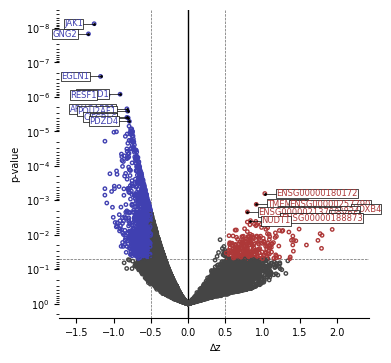

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""WDR54""",null,-1.052432,-0.438112,0.061917,-1.894626,null,-0.509965,1.482147,null,0.895704,null,-0.804622,0.794418,0.269823,-1.234979,0.420595,1.427968,-1.073409,0.332252,1.030009,-0.040962,-0.256816,-1.270928,-0.832465,null,-0.146552,null,null,null,null,0.278264,-0.91024,0.671882,2.491906,-0.033181,null,…,-1.320453,null,-0.27552,-0.24129,null,null,null,-0.26676,-0.643612,-1.32965,-0.610116,-1.267315,0.202394,-0.202769,null,-1.281203,0.203419,0.559597,-0.73723,null,null,3.462205,0.806437,null,null,0.995895,null,-0.48653,0.510683,1.319463,-0.263666,null,1.663205,-0.206221,1.026044,0.03817,0.446923
"""NFIX""",null,-0.842594,0.400398,-0.203715,2.075853,null,-0.237274,0.093641,null,-0.853611,null,-0.288666,-0.683287,-0.453699,-0.507309,0.12135,-0.650129,-0.020277,0.322765,-0.546427,0.176157,-0.675166,-0.031787,-0.078747,null,-0.551304,null,null,null,null,-0.195123,-0.017216,-0.196816,0.423054,-0.306655,null,…,-0.911118,null,-0.579532,0.097662,null,null,null,-0.17286,-0.847887,-0.774276,-0.322273,-0.896565,-0.634908,-0.471157,null,-0.683169,-0.623397,-0.466087,-0.027233,null,null,2.499943,2.252053,null,null,1.043426,null,0.482443,3.840886,-0.205411,3.692708,null,0.63784,-0.572759,1.798017,0.010389,0.249084
"""UQCRC1""",null,0.373525,-0.610121,0.10761,-2.108221,null,0.129405,0.164249,null,-0.035084,null,-0.54277,-0.693195,-0.458696,-0.901196,-0.434967,-0.322488,0.012998,-0.22211,1.394038,0.243657,0.414242,-1.697563,-1.133457,null,0.56929,null,null,null,null,0.174806,-0.429299,-0.796686,0.589275,0.348205,null,…,-2.263315,null,1.604573,-1.098831,null,null,null,1.383931,3.964205,-1.164085,0.142458,0.773156,-0.174314,-0.328454,null,0.457969,0.20756,-0.951445,-1.757733,null,null,1.953802,0.597425,null,null,1.05759,null,0.070688,-0.580614,0.590358,0.027245,null,-0.012517,1.234218,0.649468,0.046316,0.479554
"""LRRC23""",null,-0.881403,0.709285,-0.144571,-1.617031,null,0.749363,1.174783,null,-0.587759,null,-0.955226,3.346227,-0.296697,-0.817844,-0.02081,-0.765692,-1.258033,0.324448,-1.3713,-0.845106,0.295018,-0.776146,0.34311,null,0.537359,null,null,null,null,-0.49568,-0.109171,1.013869,2.328935,-0.515852,null,…,-1.807056,null,0.477822,0.314871,null,null,null,1.260433,-1.213851,0.617129,-0.424693,-0.659431,0.811309,-0.492669,null,-0.469353,-0.775237,2.047337,0.308479,null,null,1.120902,0.756479,null,null,0.382609,null,-0.373589,1.869116,0.35258,-0.341557,null,1.26884,0.047143,0.66845,0.037936,0.44651
"""ERCC1""",null,-1.291935,0.299444,-0.643345,-1.041674,null,0.375871,0.231883,null,0.159313,null,-0.98112,-0.127423,0.161422,-0.990988,-0.083948,2.534056,-0.633803,-0.394588,0.565434,-0.882488,-0.800391,-1.288926,-1.090957,null,-0.325921,null,null,null,null,1.043368,-0.579291,0.314218,0.416416,0.913815,null,…,-1.711218,null,0.136466,0.106601,null,null,null,2.011343,0.85051,-1.134797,-1.141162,-0.222077,-0.396796,0.301688,null,-0.834174,-0.705265,1.699987,-1.632871,null,null,1.611056,1.226344,null,null,2.333068,null,-0.62371,1.472

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""NFYA""",null,-1.151035,-0.042486,-0.267834,-1.00357,null,1.091672,-0.072624,null,0.816145,null,1.82974,0.387871,-0.848053,-0.166267,-0.112172,2.941192,-0.048801,0.383866,0.070035,-0.598243,-0.756761,-0.942015,-0.891239,null,-0.770068,null,null,null,null,-0.535155,2.879025,3.273823,-1.027059,0.351248,null,…,-1.384646,null,-0.101216,0.756151,null,null,null,-0.337822,-0.601959,-0.412165,-0.4439,0.652067,-0.750435,-0.403679,null,-0.561274,-0.621906,1.592199,-0.387504,null,null,-0.655164,-0.42634,null,null,-0.472049,null,-0.972797,-0.608173,-0.141301,-0.764447,null,0.747586,-1.065161,-0.573141,0.023393,0.35903
"""ST7""",null,0.03225,-0.303084,1.198863,-0.60808,null,-1.339226,1.35495,null,-1.33663,null,-1.07622,-0.512491,-1.271845,0.937296,1.274992,-0.017568,0.9529,1.620058,1.496615,0.236236,-0.460884,-0.059822,-1.167325,null,-0.102756,null,null,null,null,0.677432,4.33137,-0.012319,-0.523145,0.431184,null,…,-0.800097,null,-0.411596,0.526776,null,null,null,-0.790624,0.572844,0.25871,0.306296,-0.754822,-0.002998,-0.411752,null,-0.011016,-0.311359,0.535254,-0.511907,null,null,-0.93493,0.184012,null,null,-0.120291,null,-1.25022,0.076615,-0.219624,-1.366994,null,-1.359481,-0.095935,-0.669019,0.021055,0.342649
"""COPZ2""",null,-0.064936,-0.611785,0.03502,-0.700114,null,-0.615649,-0.277486,null,-0.45797,null,0.016307,0.151363,-0.542785,-0.628858,-0.623652,-0.621806,-0.700114,-0.348085,-0.530363,-0.091797,-0.118457,-0.700114,-0.410251,null,0.01782,null,null,null,null,-0.630567,-0.468109,-0.602979,0.28125,-0.156353,null,…,-0.700114,null,1.094282,-0.700114,null,null,null,2.707114,0.37286,-0.260697,-0.467778,0.0227,0.105311,-0.151838,null,-0.276027,2.222482,0.247519,1.425312,null,null,-0.668225,-0.385389,null,null,-0.334563,null,-0.520579,-0.613505,-0.700114,-0.090624,null,-0.63128,-0.283232,-0.555999,0.001669,0.109964
"""MSL3""",null,-0.373164,-0.382357,0.610623,-0.880298,null,-0.713617,-1.171085,null,-1.239397,null,-0.199356,-0.139963,1.349247,1.019639,-0.96701,3.434238,-0.05459,-1.641795,-0.566202,-1.617699,0.755794,-1.056113,1.615907,null,-0.277291,null,null,null,null,0.305283,1.20675,0.506835,-0.234006,-0.366023,null,…,-1.613516,null,-0.767506,-0.886142,null,null,null,0.758352,1.299414,0.285201,-0.617121,2.04437,-0.301247,0.893206,null,1.402579,-0.66523,1.464344,-0.071794,null,null,-0.731925,-0.988446,null,null,0.277078,null,-1.338611,-0.82875,-1.231137,0.185122,null,0.004157,-0.108493,-0.626164,0.025035,0.370102
"""CREBBP""",null,0.99875,0.060735,-0.175126,1.058944,null,-0.182175,-0.491348,null,-0.70532,null,0.616474,-0.003704,-0.962207,1.480126,-0.435899,-0.540487,0.236358,-0.653401,-0.555874,0.00628,-0.30274,2.934193,4.931393,null,-0.102631,null,null,null,null,-0.390674,-0.174168,-0.277199,-0.951382,-0.540173,null,…,-1.522258,null,-0.327025,0.558576,null,null,null,-0.550957,-0.741466,2.203312,-0.041016,-0.561594,0.4377,-0.307678,null,-0.488052,0.456621,-0.304043,0.015815,null,null,-0.934781,-1.151475,null,null,-0.037867,n

Proteomics


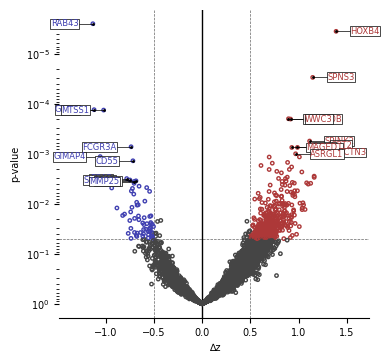

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB8""",-1.445862,0.112973,0.008697,-0.947694,null,null,null,null,null,null,-2.427172,-1.001652,-2.140759,-1.533461,-1.301862,-1.002473,-1.014477,-1.405277,-1.228186,-0.931267,-0.073886,-0.289237,0.249241,0.301607,-0.451498,-0.068058,-0.332712,0.732112,-0.49716,0.385148,0.766515,0.688441,-0.92362,0.453115,0.746895,-0.482869,…,-0.527577,0.795512,-0.370168,-1.757202,0.13967,-0.694007,1.04708,1.016636,1.050496,-0.06045,0.763946,1.592201,1.260938,-0.275848,0.333629,0.879544,0.4838,0.770952,-1.374792,0.958603,0.055175,1.195784,null,-0.448863,-0.854385,1.098889,1.12992,0.454289,2.175674,-0.547747,-0.170895,1.913146,1.319706,1.489803,0.864307,0.015518,0.665444
"""ABHD17B""",-1.036827,0.293729,-0.419048,-0.490123,null,null,null,null,null,null,-1.446795,-0.88562,-2.606136,-1.795205,-1.69122,-1.41509,-0.688364,-1.594178,-1.00848,-0.977308,0.176054,-0.460315,0.385921,0.205835,-0.083676,-0.275922,-0.639795,0.521203,-0.430814,0.210515,1.729716,0.974702,0.29364,-1.261988,0.946837,-1.478728,…,-0.618126,1.499486,-1.303097,-0.633133,-0.502784,-1.093477,1.052776,0.963728,0.714894,0.23575,1.184637,0.138406,-0.650952,0.015346,-0.103728,0.215176,0.502967,1.212219,-1.674854,1.328072,-0.529133,1.108749,null,1.0143,-0.301315,0.853434,0.632797,0.013536,-0.269929,1.483319,-0.493475,1.867337,1.134183,0.003483,0.695608,0.014086,0.665444
"""ACADVL""",-2.094354,0.485774,0.121976,-0.278192,null,null,null,null,null,null,-2.25454,-1.365735,-1.299466,-1.243973,-1.25481,-1.178931,-0.737651,-1.571397,-0.888036,-1.188466,-0.219446,-0.468275,0.306548,-0.178889,0.205028,0.24656,0.194831,0.101735,-0.680715,0.387092,0.441451,0.275445,-0.495232,1.150276,0.160607,-2.203504,…,0.298962,1.786991,-0.305544,-1.564031,-0.07958,-1.624576,0.772985,0.985126,0.815071,0.688115,0.757503,0.996295,1.030744,0.089985,0.138717,0.312842,0.977395,0.915292,-1.702825,2.530324,-0.795148,1.45967,null,0.06508,-1.275783,0.613026,1.476641,0.051886,1.534169,0.042933,-0.588138,1.026469,1.740982,0.51918,0.658065,0.041875,0.665444
"""ACY3""",-1.222216,-0.363953,1.167079,-0.023956,null,null,null,null,null,null,-1.469923,-0.693959,0.702468,-0.429699,-1.177096,-1.886609,0.38821,-0.902289,-1.097151,1.311883,-0.285838,0.682844,-0.162979,0.123891,-0.412867,0.553109,0.352855,1.316193,-0.115133,-0.072563,1.672523,0.893291,1.139936,-0.420539,1.307454,1.162832,…,0.688551,-0.760164,-1.627517,-1.577319,-0.427443,-0.440731,0.222736,0.335163,-0.196929,-1.385331,-0.437457,-0.984176,-1.192925,-0.468905,0.274864,0.547563,-0.502037,0.783219,-1.543461,-3.090115,-0.952908,1.416367,null,-0.237048,-0.43165,0.619282,-0.177406,0.707607,0.940963,1.416456,0.698127,1.965991,0.577142,-0.575363,0.683174,0.018244,0.665444
"""ACYP2""",-1.06206,0.341416,0.033563,0.515507,null,null,null,null,null,null,-1.505542,-1.035942,-1.056114,-0.702883,-1.097848,-1.840589,-1.308323,-1.403602,-1.952727,0.455338,-0.90982,-0.365298,0.876764,-0.080079,-0.735482,-0.240528,0.445621,-0.342904,-1.031861,0.853289,1.505597,-0.057979,-0.7

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALOX12""",null,2.454338,null,null,null,null,null,null,null,null,0.418164,0.402131,0.285794,1.366413,0.221772,0.414944,0.012403,-1.513726,-0.623121,1.553247,0.097569,1.530428,1.420441,-0.965351,-0.913701,-0.821169,-0.782621,0.034016,-2.569187,-0.178731,0.20387,-0.953351,1.067608,0.091384,1.951467,0.15208,…,-1.225833,0.956131,0.13675,2.874366,0.458476,-1.310812,-0.210551,-0.124454,0.433366,0.260933,0.029081,-0.235336,-1.25069,0.420765,-0.005045,-0.410169,0.056893,-0.833371,-0.491393,0.2007,-0.955367,null,null,-1.567005,-1.149624,0.699884,-0.546201,-0.692334,-0.166306,0.703981,-0.98831,-0.335138,-0.985905,-0.432102,-0.584327,0.032184,0.665444
"""ARHGAP12""",-0.195948,1.350022,0.505483,0.013669,null,null,null,null,null,null,-2.220444,-1.6594,-1.394344,-0.796608,0.42708,-1.562165,-0.806493,0.101817,-1.073163,-0.357691,-0.947157,0.36911,-0.924198,0.560299,-0.78721,-1.167406,0.721616,0.536605,-1.159154,0.901701,0.828782,-0.800143,-0.808066,-0.680324,0.601222,0.220434,…,-0.836272,-0.393548,0.27891,-0.257261,2.311767,0.453769,0.296022,1.326951,1.884532,0.059875,-0.202499,2.431798,-0.021701,1.190868,2.566253,0.900245,1.229804,1.362248,-0.871635,0.854671,-0.824433,-0.863357,null,-1.218939,-1.079752,0.168297,0.30121,-1.209646,-0.704791,-0.63224,-1.178021,-0.077125,0.387867,0.796,-0.524241,0.044031,0.665444
"""C5AR1""",0.418535,1.334816,-0.654137,1.052652,null,null,null,null,null,null,-1.113809,0.475083,-0.423874,-1.301431,0.567798,0.099669,-1.259062,0.34768,-3.141868,-1.346645,0.988541,0.683857,-0.425738,-1.819638,0.668196,0.43036,0.427694,0.132679,-0.495184,0.072377,-0.832036,-0.255813,-1.258324,-1.669007,1.017252,1.267025,…,-1.33266,-1.6392,0.594548,0.74187,1.771684,0.252244,0.435339,1.370126,0.869896,0.188029,0.067483,0.726355,0.334072,0.536376,1.498624,0.712515,0.884621,-1.277002,0.915617,-1.483191,-1.108827,-0.303077,null,-1.601777,-0.507391,-0.297446,-0.830543,0.571013,-0.934075,-0.242541,0.23904,-0.504031,-1.001899,-0.601047,-0.593667,0.008798,0.665444
"""CAMK2D""",0.219702,0.465219,-0.461914,0.08128,null,null,null,null,null,null,-1.799474,-0.57248,1.01143,0.703368,-0.14254,-2.333171,-0.454381,-1.232114,-0.135476,-0.660224,-1.332424,-0.066271,-0.88862,-0.882734,0.433136,-0.937471,0.415807,-0.341281,-0.711237,-0.833691,1.597198,-0.139011,0.596305,0.532387,0.390828,0.133821,…,1.182778,-1.192497,-0.474474,0.586247,2.071923,0.209114,-0.163483,0.382628,1.924293,-0.159184,-0.165665,0.877385,0.308544,1.719643,1.728364,1.273315,1.247684,0.645245,-0.515618,2.75443,-1.011452,-0.460796,null,-1.49881,-2.311044,0.835727,0.693455,-1.958153,-0.352325,-0.954738,-1.157837,-0.493751,-1.221049,1.117027,-0.766278,0.038941,0.665444
"""CD55""",-0.438655,1.310277,-0.571798,-0.393137,null,null,null,null,null,null,-1.753114,-1.051443,0.240109,0.364309,-1.13201,-1.569323,-1.040861,-0.248841,-1.298057,0.047525,0.112315,0.74241,-0.311619,-2.878853,0.080723,-0.032238,0.040884,-0.394894,-1.236266,-0.125674,-1.121636,-0.880952,-1.345117,0.338045,1.

Phosphoproteomics


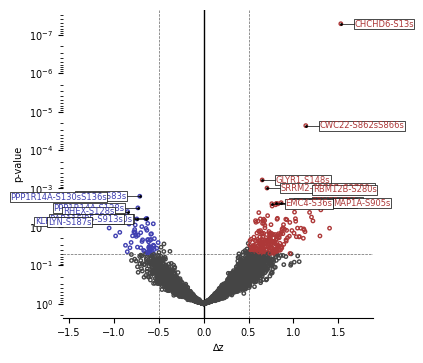

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADNP-S415s""",-0.453605,-0.491106,1.202209,null,null,null,null,null,null,null,-0.556783,-0.598557,-2.750404,0.077379,-0.995858,-1.794818,0.666392,null,-1.408664,-0.347842,-0.870487,-0.069985,-0.112092,null,-0.020843,-0.435868,-1.440847,null,-0.940883,-0.054033,2.228751,0.007371,0.192415,null,null,-0.599489,…,1.039704,0.182195,null,-0.633514,-1.117487,0.140214,null,-0.280987,0.527286,0.405735,-0.050654,1.081078,0.106317,0.431825,0.632491,-0.869007,1.314882,2.113571,-0.98961,null,-0.802136,1.192013,null,-0.163331,-1.170738,1.078778,1.227482,null,0.567555,1.17497,null,1.566415,1.560568,0.276878,0.86644,0.013575,0.997127
"""ANK1-T1378t""",-1.94472,-0.761142,-1.278617,-0.353938,null,null,null,null,null,null,-2.52058,-0.280871,1.944302,-1.181878,0.613246,-0.26733,-0.130285,-0.132268,-0.898145,-0.617239,-0.238065,-0.128775,-0.727798,-0.777545,0.25325,-0.537492,-0.716608,1.003076,0.076036,0.083071,1.508534,1.598033,-0.370351,-0.95499,-0.402412,1.387363,…,0.332151,-0.065907,-0.863561,0.490009,-0.212588,-0.794709,0.161482,-0.072652,0.421347,-0.115423,-0.265583,-0.025749,-0.93358,-0.581722,0.605402,-0.656517,1.090369,-0.536044,-1.630934,-0.483612,-1.609684,null,null,0.025284,1.968783,0.584407,-0.026945,1.226572,1.680353,1.434806,-1.574515,0.023813,0.284722,1.976888,0.808275,0.037636,0.997127
"""ANKZF1-S56s""",null,-1.417056,1.159908,-0.400019,null,null,null,null,null,null,-1.812174,-1.59701,-0.636571,0.052559,-0.080213,-2.369074,-1.107936,-0.402833,-0.349291,0.288822,-0.591931,0.25888,-0.397326,0.361462,-1.050852,-1.444108,0.466174,-0.483162,-0.604286,1.121998,0.449552,1.425625,-0.919456,0.823878,0.075817,0.306048,…,-0.836218,-0.298644,-0.277123,-0.896433,0.734967,-0.24693,0.867953,-0.036862,1.706342,0.111257,-1.150191,2.350598,0.419528,0.599018,0.003794,0.198489,-0.448116,1.297784,-2.518086,-2.949281,-0.290507,1.465918,null,-0.631348,0.667828,0.733573,0.800328,0.142676,1.283649,0.108173,-0.57824,0.551358,1.159758,1.1874,0.681929,0.009095,0.997127
"""ARGLU1-S77s""",-1.905707,-1.418846,0.805915,-1.537333,null,null,null,null,null,null,-1.271377,-0.743349,-3.044555,-0.589062,-1.037642,-2.162759,0.516303,-0.457538,-0.047703,0.290034,-0.929447,0.223331,0.25026,0.420538,-0.031151,0.638319,0.541887,0.51712,0.19415,1.44855,1.69619,0.704848,0.645781,1.609877,1.1101,0.015528,…,0.754212,0.550096,-1.23365,-2.064832,-1.212875,0.042739,-0.591462,-0.008567,-0.456607,0.44424,-0.429915,1.482703,-0.10563,1.038875,-0.405859,-0.647984,-1.419975,1.155085,-1.875284,-0.522936,-0.231871,0.7557,null,0.016428,-0.238174,1.102784,1.216383,-0.491836,1.283582,0.731932,-0.711963,0.768539,0.565403,0.075139,0.500887,0.043657,0.997127
"""ATAD2-T1245t""",-1.393218,null,0.513164,-0.009996,null,null,null,null,null,null,-1.436322,-1.290366,null,-1.648115,-0.454177,0.098083,-1.338229,-0.254454,-2.208102,-0.323362,0.488764,-1.043397,-2.100384,-0.18109,-0.486028,0.700455,-1.033845,-0.193208,-0.68874,0.327791,0.342567,1.00408,-1.447717,-1.270944,-0.08016,-0.339319,

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADAM10-S740s""",null,2.384576,null,0.110112,null,null,null,null,null,null,-0.276448,-0.305911,-1.517582,0.33564,0.041079,-1.132842,-0.292501,-0.482653,-0.508803,-0.014454,-0.920106,1.34234,-1.031474,-1.539894,-0.618006,-0.213228,-0.725665,-0.255584,-0.787977,-0.048246,0.706962,0.061648,-0.826169,-0.529593,1.746151,0.241816,…,-0.595879,0.388352,0.038119,2.705736,1.331804,0.571578,0.857248,-0.549635,1.56552,-0.551713,-0.987671,2.061585,1.110887,1.152986,2.162282,-0.771982,1.510965,-0.171235,-1.326476,-1.814754,-0.817469,null,null,-1.325478,-0.422464,0.754459,-0.040425,-1.30022,-0.774751,-1.076303,-0.271467,0.011603,-0.467563,0.019984,-0.522445,0.035967,0.997127
"""ARHGAP30-S291s""",0.03264,1.796118,0.782238,null,null,null,null,null,null,null,null,-0.389863,-1.455548,0.533116,null,null,null,0.509521,-0.735725,null,0.119932,0.500792,null,0.081179,-0.209159,-0.127272,null,-0.37958,null,0.043575,0.230219,0.137082,-3.508699,null,0.852545,-0.230212,…,null,-1.927879,null,null,null,0.647123,1.085959,null,0.813825,-0.248531,null,1.039325,null,0.582019,2.013657,null,1.220147,null,-0.860396,-1.853687,0.836419,null,null,-0.979831,null,null,null,-1.384694,-0.92742,null,-1.021918,-0.737721,0.347254,-0.262926,-0.83076,0.008446,0.997127
"""ARHGAP6-T821t""",-1.027282,2.434764,-0.009913,-0.146106,null,null,null,null,null,null,0.347062,0.396951,null,1.606099,0.352075,-1.212809,0.089049,-0.779362,null,2.509144,-0.610616,null,0.062529,-0.280698,null,-0.545727,-0.850511,-0.067195,-0.877393,-0.311009,0.528391,null,-0.644347,0.061827,1.868161,1.811002,…,-1.087392,0.737949,-0.668185,3.22817,0.414895,null,0.342711,-0.604454,-0.713128,null,-0.510721,0.492286,-0.64959,null,1.09801,-0.865444,0.974799,0.378998,null,-0.235362,-1.084825,null,null,-1.705185,-0.101963,-0.898618,-0.59307,-0.685667,0.215651,0.519361,-1.016549,null,-0.330369,-0.611046,-0.61718,0.021419,0.997127
"""BIN2-S462sS476s""",0.923808,0.923581,null,0.099686,null,null,null,null,null,null,-1.339298,-0.831983,null,0.859468,0.038303,-1.490079,-0.458411,0.027725,null,0.419682,-0.073805,null,-0.675114,0.548031,null,-0.93714,-0.737568,-0.019735,-0.952789,0.142472,0.08674,null,-0.742638,-0.859345,2.240378,1.792352,…,-1.703785,-0.401839,-0.885188,0.906248,1.901063,null,0.12029,1.247999,2.279002,null,0.469626,1.186632,1.503405,null,1.66253,0.394388,1.168043,-0.032601,null,-1.99949,-1.405995,0.988129,null,-1.157388,-1.043867,0.016807,-0.111109,-0.850459,-1.510348,-0.818899,-0.446001,null,0.364674,-0.991933,-0.610404,0.03353,0.997127
"""BNIP2-T237t""",-0.322796,-0.136139,1.100396,null,null,null,null,null,null,null,-2.07559,-1.771262,null,-0.234354,-0.253807,-0.987451,-0.284614,0.11555,-0.784544,0.176659,-0.314096,0.104937,-0.242022,-0.343699,-1.329434,0.466779,-0.979794,0.404487,-1.175418,0.361801,0.133098,-0.183706,-0.335768,-0.719044,1.454784,0.76458,…,-1.668578,-0.315032,-0.124961,0.648582,1.887172,0.105152,0.435086,1.928871,0.309622,-0.006385,0.909478,0.457274,-0.354791,1.479507,1.9303

Acetylomics


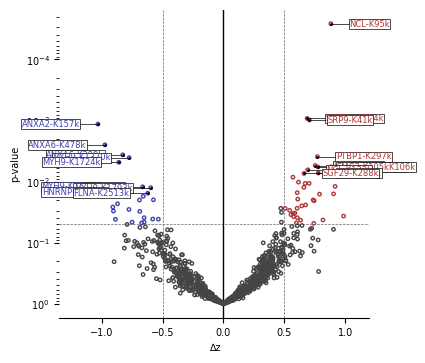

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACADVL-K278k""",null,null,-0.571502,-1.435405,null,null,null,null,null,null,0.327638,0.209687,0.257099,1.355141,-0.106049,-1.892081,-0.890472,-1.046532,0.519124,-0.977388,0.140921,0.424356,0.659687,0.499975,0.281272,0.903723,-0.227061,-0.416734,0.356573,-0.035611,0.061377,-0.71516,0.462771,1.191718,-0.530978,-1.450591,…,0.553948,-1.220264,-0.119653,-0.138604,-0.861513,-1.868151,-0.756475,-0.461686,-0.832999,1.542721,0.638131,-0.465058,0.245015,0.291519,-1.001664,-0.929305,-0.115212,1.556959,-2.334407,1.340564,0.656707,0.251664,null,2.342539,0.188364,-0.07537,1.908212,-1.062734,2.124438,0.841959,-0.315262,0.824621,1.752055,0.334349,0.90425,0.015884,0.516646
"""ACLY-K468k""",null,0.895967,0.627986,0.342354,null,null,null,null,null,null,null,-1.504687,null,-0.55471,-0.246891,-1.734019,-0.968175,-0.447893,null,0.524138,-0.324139,null,0.567695,0.569846,null,0.47785,null,0.311827,null,0.078542,-0.181811,null,-0.193409,2.988121,-1.024834,-0.276721,…,-1.385977,-0.836678,-1.170068,null,1.662733,null,-0.540128,null,0.929714,null,null,1.645407,1.141439,null,1.374729,null,-0.75946,0.353374,null,-1.023163,-1.579401,null,null,0.290764,null,0.992812,null,0.462312,0.289947,null,-0.047671,null,1.284919,0.768497,0.671359,0.010716,0.491235
"""C19orf53-K25k""",null,null,0.926868,0.599331,null,null,null,null,null,null,-2.179671,-0.915337,null,0.908351,0.222192,-3.484106,0.778312,0.29682,0.462329,0.381424,-0.091617,0.62748,0.419983,0.341886,null,0.606206,0.248457,-0.144539,-0.23573,0.682264,1.31457,-0.249315,-0.105344,0.750261,-0.387944,-0.61933,…,0.586411,-0.149151,0.237174,null,-0.305281,-0.409025,-0.561821,0.675125,-0.928491,-0.696762,-0.152639,1.426855,0.064841,1.464887,-2.033007,-1.774162,-1.836127,0.942415,-2.206217,-2.789895,0.145254,null,null,0.585747,0.318508,0.934357,1.383036,-0.606442,0.144027,-0.090128,0.789268,0.895186,0.177325,0.168352,0.506851,0.02751,0.597551
"""CLYBL-K57k""",null,-0.047146,1.018559,-3.777735,null,null,null,null,null,null,0.191067,0.16385,1.457353,0.756006,-0.054624,0.720396,0.6432,-0.832126,1.295447,-0.304517,null,0.403232,-0.961849,0.2501,-0.486839,-0.56477,-0.220222,0.281094,-0.712861,0.592326,0.907997,-0.023429,0.58287,1.060654,-1.373029,0.865245,…,0.708677,-1.082245,-0.520092,-0.562722,-0.720241,-1.395143,-1.342648,-0.087014,-0.438004,-1.198624,-0.14945,0.324702,-1.572087,-0.614403,-1.143098,-0.446911,-0.631438,1.102806,-1.326876,1.549791,1.01766,0.496898,null,-0.06288,1.087541,-0.024298,1.068165,null,2.225425,-0.139153,-0.388127,0.912541,0.623518,0.195422,0.643284,0.025019,0.597551
"""FH-K292k""",null,0.680339,-0.330202,-2.830589,null,null,null,null,null,null,0.679668,1.331405,1.017069,1.085208,0.167561,-2.24353,0.068025,0.106746,2.41131,-1.410817,0.107799,0.227153,0.113311,1.247972,-0.990103,0.838416,-0.199205,1.840303,0.459892,-0.194749,-0.36801,null,0.481188,-0.080584,-0.46163,-0.158157,…,0.516326,-0.96932,0.346576,-1.46401,-0.726508,null,-0.224316,-0.726294,-1.247583,-0.642616,-0.112254,-0.94

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACTA1-K193k""",1.151633,1.607819,-0.336804,-0.789807,null,null,null,null,null,null,0.098297,-0.045064,-0.895211,0.200841,0.034,-1.56414,-1.369342,0.167136,-0.418544,0.669515,0.5518,0.98401,0.530473,-0.755259,1.004771,0.230808,0.866882,0.202548,-0.052651,1.982329,0.050626,-1.006883,0.676273,-0.965751,-0.690437,0.438422,…,0.16552,-0.496834,-0.517302,2.027019,1.740206,1.023056,-0.862925,0.516384,0.955497,-1.075279,-0.661716,0.499711,-0.026848,-0.286618,1.226458,0.178598,-0.08516,-1.409882,0.568064,-0.420685,-1.4875,-3.664835,null,-1.472229,0.460322,-0.22584,-1.712662,0.87908,-0.335165,-0.725998,0.406197,-1.418306,-1.112752,-0.230068,-0.903492,0.030371,0.611972
"""ANXA2-K157k""",null,null,1.07822,1.424044,null,null,null,null,null,null,-0.240137,-0.52316,null,0.399092,-0.309362,0.240176,-1.705626,-0.351122,null,-1.096675,0.355502,1.098601,0.200067,null,0.200884,0.059901,1.62027,-0.348928,-0.687483,0.374766,-0.8403,null,-1.635897,-1.298276,0.637385,-0.470149,…,-0.869765,-1.628987,0.961246,-0.100955,2.234968,null,0.56156,1.459666,1.004888,-0.055953,1.195935,1.656176,1.263201,0.711612,1.411694,1.090997,1.769584,0.417022,null,0.788132,0.347996,0.095201,null,-0.818381,-0.78641,-0.579435,-1.233588,-1.540408,-2.383265,null,-0.064334,-1.547846,-0.628085,0.008585,-1.030883,0.001145,0.267415
"""ANXA5-K97k""",0.768473,0.764017,0.241693,1.929886,null,null,null,null,null,null,-0.737879,0.165528,-0.286956,-0.206335,null,null,null,-0.815836,-0.595382,null,0.207541,0.806839,-1.025623,-2.366113,0.006747,0.30047,1.170739,0.417137,-1.557267,0.858908,-2.155714,-2.567859,0.424172,-0.54065,0.580699,0.44203,…,null,-0.654604,0.31317,1.137604,1.479558,-0.007685,-0.260822,1.454535,1.044977,0.595533,0.453592,0.731867,-0.405483,1.140796,1.606795,0.901611,1.605902,-0.144891,0.630584,-0.674456,-0.664887,null,null,-1.927827,-0.286614,null,-1.029223,-1.248413,-0.749189,null,0.842278,-0.535451,-1.318972,-0.189376,-0.823245,0.01669,0.519612
"""ANXA6-K299k""",-0.266229,null,-1.088952,1.548525,null,null,null,null,null,null,-0.498015,1.318309,1.56694,0.389875,1.933035,-0.519516,0.321228,0.542129,0.162867,0.604993,1.686274,1.940098,0.995713,-1.163898,2.392997,1.696738,1.300896,-0.475337,-0.50599,1.442764,-0.318916,-1.35872,-1.696896,-0.636739,2.204522,-0.492726,…,0.846568,-0.106901,-0.105184,0.280915,-0.801486,-0.19097,0.031551,-0.535556,0.323936,-1.195553,0.261653,0.50964,-0.873648,-0.326353,-0.174283,0.6144,1.139986,-1.063463,-1.755196,-0.133844,-0.418038,-0.619949,null,-0.567034,-0.075122,-0.156584,-0.699586,-1.491302,-0.840119,-1.27142,0.200082,0.568598,-1.507467,-1.894125,-0.826701,0.003654,0.447568
"""ANXA6-K478k""",1.164593,-0.197061,0.49214,1.668289,null,null,null,null,null,null,-0.253066,0.952052,null,0.175466,-0.737312,2.108807,null,0.893778,null,null,0.924292,null,null,-1.483979,null,-0.242477,-0.056836,-0.282171,-1.081796,1.301815,-1.565225,null,-1.756854,-0.779126,1.096918,-1.061558,…,-0.558033,-0.662744,0.193087,0.924728,1.111532,null,0.0437

Lipidomics


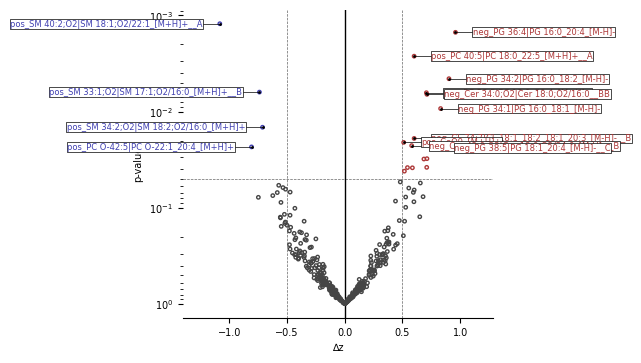

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-1.026088,null,-0.117171,null,-1.456102,-1.695909,-0.666708,-1.43029,-0.247797,-0.193849,-0.469651,0.955736,0.357302,1.52066,0.260954,-0.610372,-0.865169,-1.239476,-1.643506,-0.499413,-0.804387,-0.717376,0.41998,-0.015566,1.633892,0.439267,-0.722465,-0.404761,-0.500751,-0.864926,1.717083,-0.177731,-0.922053,-0.296107,-0.585334,0.28702,…,-0.077692,0.031548,-0.914923,-0.258494,-0.654589,0.460993,-1.400365,0.660105,-1.135166,2.309031,0.687791,-0.684941,-0.144148,-0.064927,-0.832699,0.409253,0.147075,0.381762,-0.095872,2.137214,null,null,1.737035,0.944677,-0.125704,1.122952,0.613295,-0.841942,2.390645,0.004682,-1.065086,0.434039,0.950928,1.076928,0.710044,0.038041,0.694047
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-1.340335,null,0.218527,null,-1.932322,-2.406405,-0.68671,-0.571188,-0.919682,0.759857,-1.572058,0.960614,-0.119528,2.181545,0.169754,-1.92751,-0.011521,0.430112,-0.226195,0.765619,-1.613844,-0.5874,-0.474094,-0.155141,-1.071227,-0.053454,-0.338196,0.494564,-0.106739,0.382773,0.760043,1.031869,-1.114737,0.564197,0.826685,-1.914357,…,-0.152852,1.22022,0.821289,-1.637335,-0.028234,-0.979288,-0.498128,0.511179,-1.515896,0.658523,0.918499,0.438067,0.714617,0.105111,-0.269862,-0.935576,-0.814874,0.330286,-0.636788,0.94519,null,null,0.685042,1.021064,-0.160527,0.791535,0.917158,0.080528,1.255364,0.154534,1.222365,1.526971,2.502309,-0.212387,0.959211,0.001498,0.256949
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.201948,null,0.807437,null,-2.425376,-1.950197,-0.901433,-0.469489,-0.874007,0.291913,-0.094215,0.806944,-0.816506,1.147944,-0.377379,-1.134662,-0.889379,-0.800744,-0.474485,-0.280492,-1.107187,-1.276204,0.049753,-0.080536,1.342462,0.411602,-0.525378,-0.953551,-0.840016,-0.53714,0.80944,0.249893,-0.399752,-0.336232,0.019916,0.035402,…,0.087302,0.558435,-0.618646,-1.374801,-0.293283,1.155505,-1.346216,0.877172,-1.080304,2.390239,0.475893,0.161114,0.27159,0.216312,-1.009873,-0.022114,-1.458699,0.44636,0.009011,2.172177,null,null,1.524705,1.441831,-0.314636,1.469702,0.440681,-0.948954,2.636316,0.011458,-0.250176,0.833936,1.209136,0.070808,0.79655,0.024037,0.5889
"""neg_PG 34:2|PG 16:0_18:2_[M-H]…",-0.860827,null,0.214143,null,-2.285054,-2.733674,-0.90161,0.149202,-0.69581,-0.138814,-0.744371,-0.498259,0.258655,1.043455,0.897362,0.484119,0.832347,-0.810865,1.019337,0.205088,0.09749,-0.059863,0.137274,1.425652,-0.762361,0.035546,-0.94593,-0.801565,-1.078435,-0.614504,0.666295,0.998967,-0.568409,-0.499817,-0.770458,-0.77007,…,-0.251847,1.884311,0.477229,-1.345769,0.173794,-1.647833,-0.431287,-0.272515,-1.373416,0.148059,-0.188654,0.510904,2.020612,-0.363926,-0.360044,-0.220717,-0.113946,0.804216,0.075392,2.515141,null,null,0.124661,0.144209,0.32372,-0.721573,1.534172,0.068811,1.330544,0.230418,0.910563,2.071497,1.864777,1.325967,0.902722,0.004551,0.32433
"""neg_PG 38:4|PG 18:1_20:3_[M-H]…",0.649278,null,0.700724,null,-2.122897,null,-0.379281,-1.054205,-0.325795,0.26149,-0.439199,0.322172,2.76

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""pos_SM 34:2;O2|SM 18:2;O2/16:0…",-0.937639,null,-1.081971,null,0.55091,1.094313,-0.544383,0.088746,1.10462,-0.350267,-0.877878,-1.765617,2.502524,0.556313,0.029076,-2.007571,-0.158079,-0.11448,0.290828,1.105793,-0.70794,-0.215718,-0.538314,0.945664,-1.611254,-1.878051,-0.883852,-1.140067,-0.84647,-0.934947,0.295353,0.093994,-1.07946,1.554317,0.791486,0.192729,…,0.544783,0.621257,0.270435,1.848861,1.043835,0.744117,-1.301189,-0.397645,0.201695,1.253746,-0.627496,1.002989,0.559709,0.330906,-0.229451,1.379897,1.650492,1.183369,-0.822692,-0.770238,null,null,-2.207772,-1.488786,-0.584517,0.095584,-1.130708,-0.257467,0.815421,-0.94943,-0.541291,-0.076978,-0.968027,0.021187,-0.713018,0.014554,0.554658
"""pos_SM 33:1;O2|SM 17:1;O2/16:0…",0.937661,null,-1.447156,null,1.548402,1.395582,0.525834,0.171584,1.767521,-0.237558,-0.773187,-1.972775,2.274442,1.596801,-0.18164,-1.159549,0.154445,-0.229402,1.385898,0.727872,-0.519985,0.409457,-1.45008,1.000561,-1.071178,-2.051166,0.008151,-0.626108,0.748042,-0.930657,-0.214571,0.141193,-0.982275,1.314518,1.27547,0.647458,…,0.990747,0.775325,-0.226708,1.88123,1.603735,0.274564,-1.08,-0.803016,-0.096004,0.165264,-1.206447,0.161333,0.932001,-0.012076,0.074243,0.076165,1.450533,0.591841,-1.223821,-0.307324,null,null,-1.668652,-2.014154,-0.014034,-0.297648,-0.950741,0.260687,0.078878,-0.415803,0.080842,-0.827775,-1.130283,-0.648652,-0.739935,0.006274,0.32433
"""pos_SM 40:2;O2|SM 18:1;O2/22:1…",0.970345,null,-1.329058,null,1.652121,0.935363,0.886017,0.735755,2.042047,-0.88764,0.057865,-2.072394,1.686721,1.528247,-0.060278,-1.002918,-0.414336,0.150204,1.223817,0.857427,-0.080357,0.274652,-1.186525,0.735654,-1.390508,-1.64105,-0.329278,-0.848619,0.106047,-0.615394,-0.182578,-0.216951,0.632632,1.016985,1.469386,0.373793,…,-0.272758,-0.244454,0.699895,1.963752,1.42705,1.244911,-0.02442,-0.193641,1.312231,0.449668,-0.375188,1.484729,0.764989,0.200323,0.391396,-0.305128,0.828026,-0.553282,-0.141538,-1.903087,null,null,-1.493064,-2.475641,-1.432773,0.165444,-0.098266,-0.551035,-0.314461,-0.611775,0.083438,-1.932495,-0.609532,-1.778874,-1.083239,0.00122,0.256949
"""pos_PC O-42:5|PC O-22:1_20:4_[…",1.091798,null,0.429372,null,-2.878438,-0.029464,-1.508027,-0.231138,-1.33116,-0.26284,0.208687,-0.258291,-1.001176,0.0213,-0.257877,0.66177,-1.310124,0.744896,-0.375911,-1.8706,-0.268576,-0.517183,0.295484,-0.67006,-1.244778,-0.030952,0.912621,-0.503743,0.258227,0.216417,-0.404223,-0.370007,0.380409,2.069868,0.493401,1.220726,…,-1.432849,-0.43856,0.81706,1.244825,1.179258,0.899507,1.214973,0.911103,0.560933,0.409824,0.329947,2.712752,1.246473,1.412482,0.332589,1.274175,0.574351,-0.19548,1.435892,-0.364305,null,null,-1.610751,-2.807569,-0.338199,-0.198632,-0.078384,0.596322,-1.195202,-1.219916,0.081064,-1.341538,0.825643,-0.958147,-0.808364,0.023307,0.5889


Metabolomics


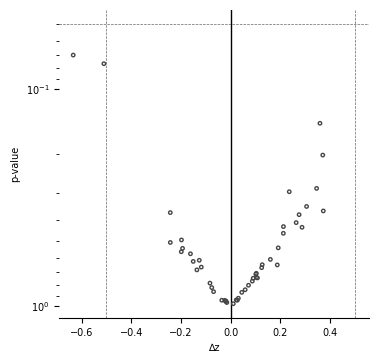

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,16-00088,C-09-0143,C-08-2480,C-12-0858,C-09-2182,C-10-3265,93-C-154,C-00-0561,C-05-0927,C-99-0027,C-04-1161,C-09-1033,C-99-1700,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_FLT3-ITD-WT ============
Transcriptomics


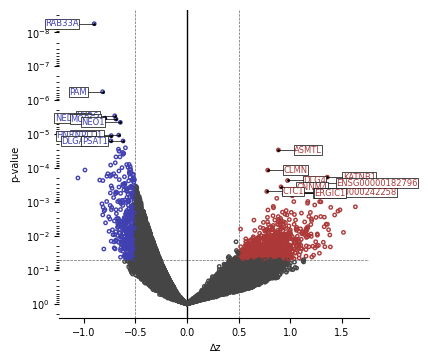

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""DVL2""",null,1.150481,null,1.327235,-0.844594,null,0.528803,-0.641897,-0.070615,-0.31883,0.495186,-0.42691,-1.119147,-0.992159,0.947469,0.939434,-1.605305,-1.342513,null,-1.346957,-1.441467,null,null,1.535643,1.655545,0.973347,-0.518894,-0.519336,null,-1.044483,0.094492,0.183691,-0.897174,-0.355375,-0.143363,0.228876,…,null,null,null,null,null,null,null,null,null,1.196693,null,null,0.704684,0.828436,1.429795,-0.892033,null,null,0.162069,0.522039,1.03427,0.329387,0.138559,null,1.283023,null,null,1.573218,-1.922477,0.838462,1.203288,null,null,null,0.682381,0.018746,0.354184
"""SPPL2B""",null,-0.328634,null,-0.147668,-0.62262,null,0.351164,-0.031094,0.289411,-0.865917,2.613328,1.024182,-0.837658,-0.9117,0.900455,1.249889,-0.97186,-1.260096,null,-0.803246,-1.176115,null,null,0.728158,-0.012178,-0.239692,-0.809942,-0.793959,null,-1.367616,-0.018401,-0.280976,-0.670968,-0.800826,0.444953,-0.378892,…,null,null,null,null,null,null,null,null,null,1.06505,null,null,0.582011,0.469339,2.774198,3.796413,null,null,-0.598697,0.888355,1.637117,0.014714,0.166688,null,1.110331,null,null,-0.336942,-1.091374,0.413662,1.530356,null,null,null,1.005527,0.009272,0.289209
"""WDR54""",null,-0.455207,null,-0.276005,-1.248259,null,-0.156396,-0.338497,0.745688,-0.86771,0.02704,-0.128445,1.19838,-0.401523,-0.235738,-0.3115,-1.444786,-0.2893,null,-0.101274,-1.428224,null,null,2.992813,-1.193014,-0.510437,-0.478187,-0.450866,null,0.277788,0.035958,0.804219,-0.024374,-0.798016,-0.843618,-0.321033,…,null,null,null,null,null,null,null,null,null,1.539326,null,null,2.33936,0.154515,-0.799484,3.615651,null,null,1.413387,0.09924,0.734528,0.302045,-0.391447,null,2.361676,null,null,0.844062,-1.206731,-0.189828,1.055775,null,null,null,0.961073,0.014471,0.32982
"""OSBPL7""",null,-0.178878,null,1.736308,-1.563413,null,0.710496,-0.159174,0.136465,-0.299663,-1.345577,-0.529058,-0.202766,-1.813653,1.295797,-0.901738,-0.839849,-1.025919,null,-0.279759,-1.284132,null,null,2.929904,1.024501,0.575639,-0.42571,0.201558,null,-1.789468,0.346191,-0.07654,-0.168875,-0.551046,-0.323518,0.184447,…,null,null,null,null,null,null,null,null,null,1.617287,null,null,0.17212,0.014195,0.834281,2.642356,null,null,0.18895,0.473626,0.327508,0.325826,0.933463,null,0.814023,null,null,1.570871,-1.892468,0.380974,0.228468,null,null,null,0.698739,0.021266,0.366622
"""TRAPPC6A""",null,0.250637,null,1.308547,-1.181807,null,-0.007801,-0.133608,-0.116754,0.027567,4.705085,-0.665843,-0.616243,0.089894,1.432463,0.524689,-0.742665,-0.912298,null,-1.169653,-0.37975,null,null,-0.210816,2.00545,1.284152,-0.720787,-0.894081,null,-1.34954,0.446793,-0.252707,-0.043844,-1.073381,0.343818,0.169696,…,null,null,null,null,null,null,null,null,null,0.918375,null,null,1.249496,0.687414,-0.88436,1.826117,null,null,0.150233,0.385733,1.898919,0.163041,0.100452,null,0.277246,null,null,1.136582,-1.599466,0.198667,0.561031,null,null,null,0.572291,0.042199,0.431753
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ST7""",null,0.625852,null,2.599456,0.52206,null,-0.789204,-0.379028,-0.289676,-0.191421,1.213148,-1.058577,-1.138345,-0.715415,0.560728,0.380415,-0.702858,-0.920516,null,0.737936,-0.767128,null,null,-0.258469,1.035969,2.634248,0.581826,1.115228,null,-0.382739,1.716707,-0.179692,-1.349384,0.465906,0.633111,0.341736,…,null,null,null,null,null,null,null,null,null,-1.517108,null,null,-1.422654,0.540057,-1.531767,-0.503425,null,null,-1.461653,-0.617696,-1.478376,-0.165365,-0.527033,null,-0.769217,null,null,0.557674,-0.693881,-1.108835,-1.50271,null,null,null,-0.98778,0.000115,0.083378
"""ELOVL5""",null,0.962895,null,1.678667,1.060532,null,0.3674,0.616969,1.671568,-0.133306,0.275894,-1.157149,-1.430937,-0.236391,-0.079908,0.788513,2.025406,-0.266242,null,2.06292,0.517996,null,null,-0.798061,2.782902,0.347056,0.754085,0.495643,null,-0.312044,-0.302194,-0.431779,-1.189539,0.219788,1.142963,-0.062366,…,null,null,null,null,null,null,null,null,null,-1.058195,null,null,-0.825344,2.207377,-1.694753,-2.438056,null,null,-0.772617,-0.893478,-1.665155,-0.958452,0.164042,null,0.258931,null,null,-0.845722,0.301961,-2.205806,0.479655,null,null,null,-0.805121,0.024368,0.377751
"""ACP3""",null,-0.484736,null,-0.882348,0.486754,null,-0.966631,1.108241,0.835449,1.336546,-0.996286,-0.113857,2.108509,-0.286247,-0.907081,-0.775799,2.001697,-0.992064,null,3.41772,2.455037,null,null,-0.9701,-0.987315,-0.663221,-0.25965,1.126154,null,-0.167571,0.206678,-0.505651,0.091692,-0.111687,-0.044461,-0.577867,…,null,null,null,null,null,null,null,null,null,-0.498573,null,null,-0.655894,-0.295996,-0.782653,-0.736341,null,null,0.187008,-0.89741,-0.420816,-0.880548,1.00256,null,-0.118264,null,null,-0.649579,-0.100075,-0.65293,-0.873542,null,null,null,-0.515914,0.007198,0.265407
"""WWTR1""",null,-0.558098,null,0.308912,0.927409,null,-0.385458,0.158064,0.803735,-0.766495,-0.385553,-0.414958,0.065062,-0.724482,-0.164057,3.600001,-0.082251,-0.429475,null,0.197616,-0.431248,null,null,-0.218275,-0.250665,-0.302079,-0.040993,-0.194693,null,-0.532691,-0.374155,-0.50394,-0.17193,-0.727381,-0.440569,-0.766495,…,null,null,null,null,null,null,null,null,null,-0.265685,null,null,-0.711403,-0.516897,-0.468779,-0.766495,null,null,-0.482951,-0.738272,-0.408858,-0.590522,0.26399,null,0.109496,null,null,0.105885,-0.719918,-0.740086,-0.545439,null,null,null,-0.524242,0.001215,0.153602
"""TG""",null,-0.382385,null,-0.757091,-0.586365,null,-0.021226,-0.218724,0.318651,1.124613,-0.616303,0.67736,3.260976,0.07337,-0.505927,-0.629595,1.048776,-0.257449,null,-0.472376,0.120183,null,null,3.802857,0.360788,-0.839265,-0.263049,1.447945,null,-1.063551,-0.075964,-0.865845,1.247099,-0.951643,-0.859566,-0.687122,…,null,null,null,null,null,null,null,null,null,0.03564,null,null,-0.732901,-0.012645,-0.518977,-0.769461,null,null,0.672875,-0.62252,-0.807039,-1.031928,0.239873,null,-0.512031,null,null,-0.866679,-0.211873,-0.866948,-0.618964,null,null,null,-0.536194,0.004212,0.228744
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,

Proteomics


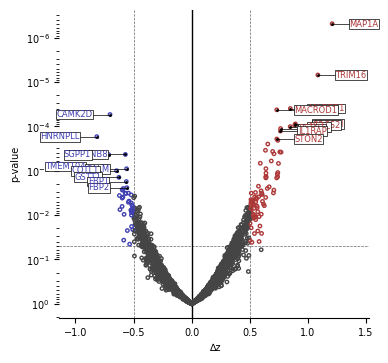

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABI2""",-0.058231,0.405673,0.587413,-1.988668,-0.029116,-0.74663,-1.434282,-1.558773,-0.469858,-0.160422,0.493812,0.844808,0.92697,0.668183,-0.956632,0.096723,-1.18994,0.628207,0.221652,0.116619,-0.949687,0.275336,-1.090828,-0.641853,-1.311231,-1.607015,-0.31648,0.52676,0.537205,0.414851,1.039585,-0.187602,-1.807554,-0.435101,-1.848518,1.028911,…,null,0.807648,-0.14558,0.413775,0.423763,0.547594,-0.644589,0.824183,1.368356,-1.065562,1.958812,1.121578,0.224621,-0.326221,0.321959,1.526641,0.344894,-1.186637,0.232505,1.490111,0.246166,1.611341,0.344437,1.512811,1.501264,1.456959,-0.896925,0.578822,-0.289889,2.177059,0.901329,0.703217,1.078203,-1.168602,0.740861,0.000207,0.1281
"""ADGRG1""",1.573361,-0.285791,0.872193,null,-0.097913,1.61887,-1.563966,-1.525204,null,0.289765,1.163799,null,0.488477,0.128966,-0.45898,null,null,-0.896998,null,-0.006692,-0.666755,-0.042125,null,-1.750218,-0.52079,-0.470859,null,-0.921944,0.242397,-0.22005,null,-1.960479,null,null,-0.930118,null,…,-0.500118,1.884815,1.840049,-1.175609,-0.433805,null,null,1.128604,0.826176,null,null,1.678045,0.245525,0.436434,-0.085376,-0.349956,null,-0.67478,0.802103,1.077452,0.608079,null,1.564418,1.935548,1.281141,0.789412,-1.075622,-0.499274,-0.821529,0.483103,0.775129,1.194506,-0.029948,0.78867,0.740728,0.0011,0.304931
"""ADGRG5""",0.449556,0.67864,0.646936,-0.496104,0.015749,0.589079,-1.432581,-1.724328,-1.027742,1.484779,-0.732994,0.139555,1.300486,-0.903078,-0.40829,-0.239603,-0.593881,-0.596538,-0.671079,0.309586,-1.025739,-0.229696,0.982631,-1.429752,-0.282588,1.670534,0.039052,-0.207741,0.612225,-0.843278,0.9588,-0.782179,-1.911354,0.356,-2.281097,-0.186198,…,0.368475,2.507452,0.820493,0.015102,-0.698665,0.16683,0.878929,1.918918,0.986006,-1.814335,2.482947,0.98349,0.24088,0.384654,0.848566,1.602161,-0.530993,1.295457,0.37296,-0.320946,0.190521,-0.876481,0.638192,1.970172,2.458242,0.878648,-1.376557,0.752038,-0.470949,0.903085,0.667347,0.761795,-0.184045,-0.222207,0.746348,0.000686,0.230307
"""AHDC1""",0.59747,0.691515,0.500231,-1.040213,-1.030739,-0.124381,-2.446149,-2.054311,-1.341507,1.415165,1.357306,0.66643,1.084614,-0.511371,0.168813,-1.511275,-1.230647,-0.008395,-0.180677,-0.397669,-1.170429,0.167515,1.509093,-1.550236,-0.201273,0.909877,0.160817,-0.208136,0.127127,0.639051,0.476157,-1.055155,-1.014152,0.038008,-2.389915,-0.042617,…,-0.954587,1.750998,2.731675,0.596866,-0.738198,-1.139705,0.083824,1.136292,1.557599,-0.190328,2.116971,0.9225,-0.401582,-0.169675,-0.175638,1.247276,0.690837,0.070716,-0.547207,0.897646,0.392516,0.391336,0.434621,0.508031,0.994568,1.443479,-1.08383,1.225504,-0.9347,1.408796,0.695269,0.22785,0.617026,-0.037427,0.684699,0.000603,0.221005
"""AIF1L""",0.047358,-0.131057,0.583363,-0.847063,-0.211401,0.754314,0.136448,-1.676356,-0.805351,0.138854,0.149069,0.231842,-0.095707,0.72699,-1.135485,0.359363,-1.477131,0.681501,-0.094075,0.420483,-1.099146,-1.366656,-0.249295,-1.43603,-1.412415,0.19529,-0.427399,-1.329909,1.569544,-0.069645,-0.028816,-0.485911,-0.96201

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALDH3A2""",-0.195217,1.866601,1.403399,-1.268379,1.525865,-0.77474,-2.074088,-1.720614,0.471925,1.136656,-0.437282,0.259401,0.668321,-0.233758,1.938026,-0.330848,-1.174427,-0.431685,1.226795,1.674634,0.126712,-0.581138,-1.205515,-1.013613,-0.953694,-0.520845,1.219529,1.995728,1.078209,1.019863,-0.095253,-1.376854,-0.825059,0.99515,-0.317234,0.55146,…,0.050104,1.85577,0.64681,-1.723698,-1.083438,-0.987858,-0.600918,-0.303384,-0.991022,-0.766392,-0.152864,-0.061879,-1.001817,0.905563,-2.005334,1.147824,-1.104036,0.684809,-0.582978,-0.677353,-0.413746,-1.313536,0.458884,0.14713,-0.391607,-2.056901,-1.148402,-0.993412,0.502856,-1.354326,-0.400219,0.759188,-1.072235,-0.447086,-0.594698,0.002758,0.483113
"""ANXA5""",0.079743,1.852847,0.450433,-1.284661,1.207428,0.44147,-1.290637,-0.397091,-0.41688,1.595358,-0.034013,0.481474,1.00468,-0.108695,2.174623,-0.379634,0.163722,1.137378,1.547302,0.801632,0.169144,-0.950003,-0.948393,-1.69699,-0.444067,-1.549579,1.445096,1.563283,-1.151912,1.578179,-0.571435,0.007183,0.80797,0.271811,-0.352727,0.754869,…,-0.220267,-1.209275,0.285406,0.335894,-1.171412,-2.081586,0.227085,0.174478,-1.17515,-1.922148,0.336057,0.10623,-0.685834,0.56212,-1.859731,1.645983,0.037356,-0.221576,-0.21445,-0.529806,-0.007062,0.24119,0.235401,-0.068655,-0.618836,-1.077894,-0.87682,-1.651292,1.394075,0.548564,-1.307625,0.046356,-1.520244,-0.569057,-0.515544,0.008737,0.607429
"""ASAP1""",0.668038,1.896153,1.119109,-1.357365,1.506429,1.085131,-2.352876,-1.492883,0.311092,1.667928,-0.780682,0.876635,0.531866,-0.321426,0.62195,1.023453,-0.173517,-0.105395,1.295344,1.50417,-0.028421,-1.0421,-0.247304,-2.188322,-1.153035,0.504074,0.301172,1.159905,0.49187,1.157793,-0.103451,-1.862048,-0.445705,0.969849,0.466357,0.580511,…,0.872388,0.804595,0.340406,-1.612404,-1.127933,-2.277705,-0.548612,0.133044,-0.677864,-1.053816,0.370364,-0.849391,-0.858165,0.749075,-1.447402,0.738133,-1.13673,-0.969274,0.233608,-0.871659,0.015807,-1.240333,0.876797,0.061574,-0.006994,-0.309279,-0.068705,-1.485746,1.200989,-1.005858,0.003927,-0.115602,-1.665667,0.623396,-0.539501,0.00483,0.548197
"""CAMK2D""",0.371061,0.884899,0.459874,-1.057028,0.111803,1.349624,-0.799511,-1.544851,-0.884285,-0.185523,0.961912,0.813622,2.345711,0.09545,1.607058,0.477939,-0.835253,0.516146,1.39743,-0.258557,-0.73301,-0.124762,-0.750095,-1.171558,-0.190787,-0.455806,1.19158,0.098785,-0.200319,1.928837,-0.277695,-0.611166,-0.48411,1.124068,-0.756334,0.101849,…,0.261812,-0.294775,0.383388,-0.915246,-1.031057,-1.77322,-0.162463,-0.061685,-0.545048,-1.661538,0.786567,0.239305,-1.350401,-0.718821,-1.680273,0.143496,-0.103762,-0.947197,-0.692535,-0.429313,-0.308685,0.024161,-0.153694,-0.430074,-0.40382,-0.858112,0.02218,-0.962502,0.966978,-0.415657,-0.60248,0.292688,-1.83105,-1.691656,-0.702811,0.000054,0.086925
"""CCDC88B""",-0.332911,1.135595,1.194287,-1.204605,1.378338,0.41626,-1.858977,-1.244434,-0.088061,1.214696,-0.081815,0.367365,0.498731,-0.315515,0.488521,-0.356886,-0.842936,-0.193677,1.492309,1.6477

Phosphoproteomics


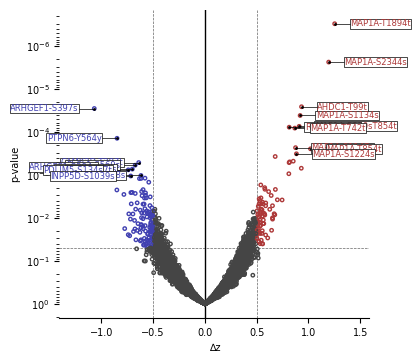

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACTN2-S355s""",-0.477878,null,null,-0.42121,0.160644,null,-2.369863,null,-1.29062,null,null,0.255552,0.352314,0.16499,null,-1.305221,null,null,0.590601,null,null,null,1.512002,null,-0.237232,null,-0.882855,0.247883,null,null,-0.054486,null,-1.115547,null,-1.705255,-0.245525,…,null,2.130852,0.201401,-0.088595,null,0.568093,-0.940664,null,null,-0.075319,null,null,-0.55969,-0.081946,-0.58056,2.018544,-0.019644,-0.729165,-0.653901,2.016331,0.106863,1.587577,null,0.035063,null,null,null,null,1.008684,1.011575,null,null,1.941227,-0.619524,0.55645,0.040201,0.971555
"""ACTN4-S367s""",-0.477878,null,null,-0.42121,0.160644,null,-2.369863,null,-1.29062,null,null,0.255552,0.352314,0.16499,null,-1.305221,null,null,0.590601,null,null,null,1.512002,null,-0.237232,null,-0.882855,0.247883,null,null,-0.054486,null,-1.115547,null,-1.705255,-0.245525,…,null,2.130852,0.201401,-0.088595,null,0.568093,-0.940664,null,null,-0.075319,null,null,-0.55969,-0.081946,-0.58056,2.018544,-0.019644,-0.729165,-0.653901,2.016331,0.106863,1.587577,null,0.035063,null,null,null,null,1.008684,1.011575,null,null,1.941227,-0.619524,0.55645,0.040201,0.971555
"""AHDC1-S1064s""",0.333966,-0.034904,0.779729,-0.820004,-1.139667,0.076078,-2.567423,null,-0.969495,null,1.796654,-0.063199,0.067417,null,-0.247801,-0.272212,-1.645961,-0.195921,0.029617,-0.225276,-1.933921,-0.037921,1.634697,-0.490406,0.76452,null,0.015337,0.498972,1.413052,1.085695,0.521538,-0.918218,-0.887687,0.510848,-1.776306,-0.339859,…,-1.064606,1.643892,-1.140776,0.125052,-0.172221,-0.824017,0.488742,1.264427,0.976177,-0.755419,2.038486,null,null,0.155245,0.218003,0.812672,0.517706,0.044597,0.111155,0.63304,0.590872,null,1.113787,0.352235,1.261739,1.160426,null,0.482944,null,1.432808,0.279408,0.218266,0.937539,0.063255,0.678668,0.000371,0.238893
"""AHDC1-S1187s""",-0.035698,0.165879,0.983652,-0.55762,-0.766938,0.30378,-3.263991,-1.82006,-1.366098,1.31402,1.402203,0.684705,0.176632,-0.155105,0.808527,-1.601106,-2.511681,-0.150546,-0.11006,-0.407863,-1.217312,0.275055,1.81133,-0.745439,-0.364539,0.889001,-0.176964,0.111867,0.552627,0.150409,0.365688,-0.081489,-0.807516,0.610414,-2.832604,-0.471498,…,-1.301694,1.907593,-0.61542,1.325261,-0.929893,-1.25749,0.320119,0.521683,0.538344,-0.4819,1.445501,-0.138873,0.540202,0.383136,-0.088777,0.900299,0.23378,0.347402,0.328851,0.478673,0.326514,-0.073793,1.551242,0.843297,1.251665,1.414023,-0.748712,0.833421,-1.000031,1.172022,0.120888,0.316076,-0.026528,0.983998,0.523821,0.003593,0.589099
"""AHDC1-S1476s""",0.142826,0.145572,0.608599,-0.548866,null,0.325248,-2.091316,-1.539517,-0.104164,0.945889,1.480197,0.824694,0.483989,-0.571585,0.138582,-1.370055,null,0.40944,0.672862,-0.567282,-1.112702,0.295635,1.576607,-0.255476,0.579375,1.133527,0.424463,0.704482,0.264708,-0.046815,0.96471,-0.284419,-0.394272,null,-1.956197,0.304744,…,-1.052759,1.545477,-0.966176,1.068986,-1.28341,-1.319233,-0.686337,null,null,-0.741782,null,0.939344,0.973758,-0.46325,0.836246,0.938878,0.160586,0.032545,-0.217903,1.31622

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACBD5-S444s""",-0.498441,1.606546,0.082821,0.046209,-0.94636,null,null,null,-2.120104,1.831734,null,-0.167877,null,-0.49086,null,null,null,0.34287,0.971712,null,-1.056805,-0.119864,0.880389,null,1.220874,0.81444,0.914504,1.344484,null,null,-0.169311,null,-1.067287,null,null,0.266463,…,-1.092414,null,-0.065944,null,-1.44879,-0.400723,1.349452,0.647649,-0.084326,-0.264501,null,0.426054,-1.497302,null,-0.07602,null,-0.826503,null,null,-0.277701,null,-1.254995,null,1.11504,null,null,-2.384217,0.167002,-1.030551,null,-0.629414,-0.584489,-1.769826,-1.77294,-0.694835,0.008113,0.726997
"""AFDN-S1282s""",1.366413,2.689138,0.696356,-1.532227,1.067294,0.187788,-2.76714,null,-0.23436,-0.516452,-0.191361,-0.289559,0.458214,-1.100701,1.712666,0.46837,1.365294,0.167207,1.210211,-0.302894,-0.687573,0.126503,0.448841,-1.183032,-0.33455,-1.070708,0.531744,0.736162,0.817629,3.177992,0.165667,-1.180102,-0.312801,-0.119595,-0.078718,-0.282033,…,-0.198013,0.991379,0.230303,-0.882639,-1.135315,-1.396676,-0.603829,0.140156,0.083194,-0.5204,0.159183,0.383211,-1.191032,1.229053,-1.449977,0.602037,-1.116317,0.274552,-0.868216,-0.1097,-0.643951,-1.073749,-0.333945,0.965077,-0.784194,-1.370239,-1.199231,-0.648209,0.717577,-0.66044,-1.08859,-0.237188,-0.688698,-0.356626,-0.527635,0.003238,0.576034
"""AKAP13-S2563s""",-0.780748,1.147231,0.769678,-0.757212,-1.010213,null,null,-0.978497,-1.821581,2.134096,0.989224,1.268724,-1.560093,0.072736,null,null,null,0.436689,1.486324,null,0.170298,-0.541466,1.575451,-1.535304,null,0.8143,0.555894,1.197202,null,null,-0.391683,null,0.572933,0.922695,null,0.454954,…,-0.114006,1.546811,0.130443,-0.0071,-2.782204,-1.660748,-0.755266,-0.037871,0.063134,-0.528792,null,0.288107,-1.913962,-1.042814,null,0.876714,-0.469815,-0.352911,-0.844416,-0.874936,0.354215,-0.701632,null,null,null,null,-2.015067,-0.186459,null,0.057266,0.182432,-0.867101,-1.342889,0.346617,-0.653997,0.004457,0.634865
"""ANKRD11-S1079s""",null,null,1.084445,0.024828,0.943065,null,-2.6198,null,-0.069014,2.400091,null,0.849717,-0.486532,-0.193086,null,-0.146886,null,-0.497221,0.511648,null,-1.73491,-0.545126,1.459746,null,null,0.292688,0.772444,null,null,null,0.814257,null,-0.597637,1.544292,null,0.206897,…,0.484118,1.78277,null,null,-1.373655,-2.09499,-0.910206,null,null,-1.719994,null,-0.87171,-0.828325,0.084304,null,null,-1.293789,0.63845,-0.464547,null,0.949068,null,null,null,null,null,-1.342286,null,0.003948,-0.150919,null,null,-0.050846,-1.186718,-0.689176,0.020764,0.875713
"""APBB1IP-S526sS531s""",-0.382369,0.44991,null,-1.565977,-0.063988,0.058052,null,-1.797115,-0.753577,0.97286,null,0.397742,-0.760325,-1.246395,0.674153,null,null,null,2.120915,null,null,null,null,null,0.700082,-0.265605,0.877713,1.033393,-2.290319,null,null,null,null,0.64988,-2.817381,0.371685,…,-0.804336,null,-0.581437,null,null,null,-0.937043,null,null,-1.670909,null,0.521506,0.193394,-0.382186,-0.614598,null,-1.380421,null,null,-0.138733,-0.630474,null,null,1.107385,null,-0.368479,-0.57518,-0.740699,null,null,

Acetylomics


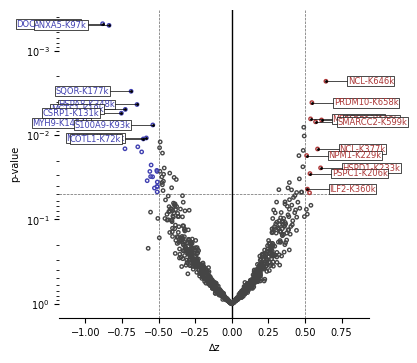

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""HSD17B10-K53k""",null,null,0.049665,-0.462614,null,-0.502973,null,null,null,0.598267,null,0.765471,0.19323,null,-1.637365,null,null,-0.991612,-0.328562,-1.145843,1.114293,null,null,null,-0.804228,null,-1.30584,null,1.749956,-0.514504,0.134852,null,null,0.494485,null,null,…,-2.580175,-0.158475,null,null,null,null,null,1.438611,1.706713,null,1.721128,null,null,0.028908,null,-0.03019,null,null,null,null,0.188401,0.018819,null,0.208076,1.421314,-0.866209,null,null,null,null,-0.664411,0.316903,0.005177,0.821821,0.531156,0.04823,0.704609
"""HSPD1-K233k""",null,null,null,1.833775,-0.11122,-1.814731,null,null,null,0.652604,-0.035363,0.199822,null,0.1552,-3.061523,null,null,-1.762235,-0.560065,-1.08503,null,null,0.724787,-0.315956,-0.256898,-1.814731,-0.417012,-0.413075,null,-0.792362,1.781279,null,null,-0.073029,-0.273959,1.102761,…,null,0.216883,0.321876,null,null,null,-0.250336,-0.746428,1.820651,null,2.188126,-0.348767,null,null,1.222191,0.459679,null,1.324559,1.597541,null,null,null,0.670978,1.186756,0.680165,0.400621,-0.74774,null,null,-1.249082,0.728724,null,null,-0.794538,0.606627,0.024399,0.695509
"""ILF2-K360k""",-0.983688,-1.137425,null,-0.323406,0.114153,-0.028941,null,null,null,0.528061,-1.002412,-0.500795,null,1.001098,-0.313552,null,null,null,1.119358,1.010953,null,null,0.530032,-0.240625,0.387135,0.961679,-0.311581,-0.132418,1.474136,-0.294827,2.804554,null,0.279716,1.079938,-1.758287,null,…,-0.50133,-0.545143,-1.285249,1.040518,null,null,null,2.331516,0.079661,null,1.346021,0.892694,1.217907,null,3.671789,-0.765894,null,-0.002037,0.284644,0.304354,null,null,-0.942297,-0.441666,0.605915,-0.190365,0.359541,null,-0.025886,-0.551056,0.414729,1.129213,-0.035732,0.410104,0.516849,0.043619,0.704609
"""MEAF6-K69k""",-0.234828,-0.868567,0.723742,0.23968,-1.043721,-0.459344,-0.753921,null,-1.260276,-0.741183,0.938704,0.077424,0.261972,0.849534,-0.730037,null,null,-0.290559,-0.831944,0.859088,-2.753862,0.149077,0.50878,-2.212477,0.14239,0.103378,-0.763475,-0.140882,-0.909967,-1.750707,-0.111265,-0.314444,-0.438644,-0.451382,-1.989553,0.354326,…,-1.123539,1.050165,-1.448168,-1.542114,1.379773,0.827242,-0.115087,1.002396,0.812911,0.135065,0.849534,0.049877,1.225319,-0.161582,0.78425,-0.712521,0.68075,0.988065,-1.01506,0.760365,-0.163174,0.65368,1.026281,1.244427,0.795396,1.615435,0.024702,0.122645,-1.070791,0.918004,0.575657,2.309682,0.113478,-0.88336,0.53811,0.006401,0.537892
"""NCL-K377k""",null,-1.467285,null,0.266595,null,-0.249284,null,null,null,-0.53277,-0.700884,-1.116224,-1.060186,0.192427,-0.593752,-1.735937,null,null,0.642379,0.446246,null,null,1.92301,null,-0.020847,0.314392,-1.434321,-1.107983,-1.310708,-0.592104,-3.631338,null,-0.662976,0.041009,null,-1.277745,…,null,-0.209728,null,0.444598,3.373404,0.754455,0.599526,2.829506,0.983551,null,-0.054634,0.246817,0.965421,-1.417839,0.497339,-0.519584,null,null,-0.573974,null,0.868179,1.553819,0.096009,1.008273,0.892901,-0.275655,-1.098094,-1.02887,-0.653086,0.807196,-0.27071,1.220888,0.613679,0.110303,0

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACAA2-K234k""",0.931684,0.142314,0.637275,2.444232,null,0.309474,-0.051324,null,-0.244962,0.150217,-1.11238,0.157133,-0.756719,-0.388215,-1.250693,-0.92467,null,0.048458,-0.711274,null,-0.74684,1.231032,1.186575,0.074145,2.078692,0.918841,-0.670768,0.16306,-0.484046,null,0.946503,null,0.705444,null,0.473276,0.789419,…,0.578074,-2.485628,-0.48207,-1.586595,-1.803944,-1.092621,1.426646,-0.663852,0.760769,null,null,0.131446,0.834865,-0.448479,-0.181733,-0.393154,0.166024,-0.517636,0.479204,-0.904911,0.661974,null,null,1.151008,null,-2.367074,1.584718,null,-1.260573,-0.509732,1.456284,-1.477921,-1.87474,-0.498295,-0.50994,0.047055,0.704609
"""ACAT1-K190k""",null,0.257117,1.381559,1.746127,null,-0.418406,0.37864,1.33152,null,1.10992,null,0.615251,1.06703,null,1.310075,null,null,0.538049,-0.146767,-0.125322,0.93121,0.228523,1.188552,null,1.881946,1.77472,0.646704,null,null,1.131365,0.490869,null,null,0.031943,-0.741513,-0.229688,…,-0.348034,0.015501,null,-1.899552,-5.695347,null,0.332175,0.459416,0.385073,-0.698623,0.186205,1.074178,null,-0.176075,0.06697,0.014787,0.758934,0.281422,-0.734365,null,-0.192517,-0.784403,-0.267575,0.144887,0.4008,-0.415547,-0.584249,-0.397676,-0.884481,-0.998855,0.803254,-0.97741,-0.827891,-0.663018,-0.554552,0.030952,0.695509
"""ACTA1-K63k""",1.279586,0.064322,null,0.154014,null,null,null,null,null,0.304343,-0.367337,-0.147907,null,-1.3278,null,2.024915,1.304851,null,1.20379,-0.314911,null,null,-0.497833,-0.400687,-1.183788,-1.334117,1.443811,0.327082,0.154014,null,0.023897,null,0.224757,0.152751,2.315466,null,…,0.665818,-1.085253,0.277814,null,null,0.877867,-0.866707,-0.29528,null,-0.046846,-1.004403,null,null,-1.233055,-0.252885,-1.373278,-0.347125,-0.725221,0.762909,-0.942503,null,null,null,-0.506676,null,null,0.511519,-0.079691,null,-2.105974,null,-0.425826,-0.71729,1.940747,-0.510543,0.040533,0.704609
"""ANXA5-K97k""",0.514886,null,0.018263,null,1.694632,null,0.278297,null,null,0.948632,null,0.298546,0.735489,null,1.170301,0.147939,0.2751,0.32732,1.822518,0.78238,null,null,null,null,-1.385284,null,2.184861,1.428204,null,0.068245,null,1.121278,1.020035,0.129438,-0.658467,1.257689,…,-0.934502,-1.822228,0.294283,0.186006,1.096766,null,0.233963,-1.310684,-2.014056,null,-0.471966,-1.129513,null,0.67794,null,-0.921698,-0.227918,0.018263,-0.307846,-0.273743,-0.019038,null,-0.546566,-1.694342,-2.770714,null,null,null,-0.215129,-0.430404,-0.301452,null,-1.033262,-1.029682,-0.838658,0.000497,0.232422
"""ARHGDIB-K30k""",-0.682343,0.472983,null,-0.996328,1.27963,0.767886,null,-0.781222,0.646456,null,1.288304,0.200632,-1.339804,0.443493,0.655129,-0.638108,-1.8342,null,0.77656,0.611761,null,null,-0.953827,-1.157658,0.420074,null,-0.209544,-0.484585,0.468646,2.320465,0.28997,-0.442084,-0.044832,-1.52195,-0.592137,-0.459431,…,1.066241,-0.605148,-1.634707,-0.346674,null,-0.96944,-2.831666,-1.103014,-0.646781,0.906664,-0.690149,null,-1.046635,0.374971,2.042909,-0.511473,-0.758671,-1.031023,-0.441216,0.14512,1.357693,0.234459,0.028026,-2.762278,-

Lipidomics


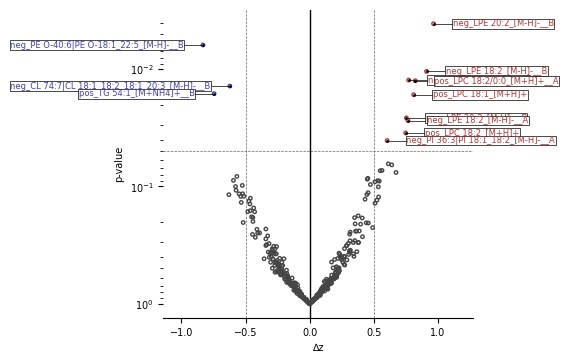

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 18:2_[M-H]-__A""",1.487469,-0.242082,1.382833,-1.442663,1.572284,0.947479,-1.372938,-1.049814,0.742296,-0.810813,-0.73762,-0.54008,-0.347719,-0.511068,-0.00235,0.057534,-0.831268,-0.140255,1.567605,-0.649223,0.640155,null,-1.159694,-0.198811,-0.764777,0.074608,-1.143035,-1.221603,null,null,null,-0.735205,null,null,null,null,…,null,null,0.026641,null,null,null,null,2.870511,1.402782,0.456273,1.384558,-0.448212,-1.072956,0.859541,null,-0.889304,1.525827,null,null,0.867305,null,null,1.105516,null,null,null,null,null,null,null,-0.394375,0.320999,null,null,0.767998,0.027386,0.93935
"""neg_LPE 18:2_[M-H]-__B""",1.515134,-0.086405,1.599206,-1.3446,1.540604,0.887104,-1.096864,-0.838119,0.412085,-0.918415,-0.734319,-0.698294,-0.518957,-0.555639,-0.034275,-0.403196,-0.958333,-0.098217,1.293776,-1.258591,0.283088,null,-1.533028,-0.0444,-1.030973,-0.854145,-1.174325,-1.480202,null,null,null,-0.693116,null,null,null,null,…,null,null,0.47688,null,null,null,null,3.316429,1.729896,0.861625,1.078031,-0.012259,-0.821952,1.214386,null,-1.2639,0.862296,null,null,0.771601,null,null,0.360982,null,null,null,null,null,null,null,0.324837,0.622685,null,null,0.912342,0.010431,0.706326
"""neg_LPE 20:3_[M-H]-__B""",0.529591,-0.574107,0.452924,-2.615174,0.433758,-0.333663,0.058727,-1.514595,-0.248483,-1.625134,-0.248415,-1.121812,0.11445,0.57736,1.504859,0.910616,-0.859032,-0.698837,0.210495,-0.595619,1.509057,null,-0.144553,0.133272,-0.699769,-2.281749,-0.841431,-0.214418,null,null,null,0.985297,null,null,null,null,…,null,null,1.319314,null,null,null,null,1.550551,1.541317,0.020981,1.237471,-0.387404,-1.178709,2.160506,null,-1.025336,-0.128726,null,null,0.877425,null,null,0.268918,null,null,null,null,null,null,null,0.066576,1.559864,null,null,0.755316,0.026003,0.93935
"""neg_LPE 18:1_[M-H]-__B""",2.974421,-0.457184,1.221243,-0.220565,0.938767,1.61545,-0.356188,-0.16777,0.206227,0.034513,0.33194,-0.97205,-1.48927,-0.314015,-0.748875,-0.502411,-1.865092,-0.108389,1.526326,-0.760201,-0.576967,null,-0.766859,-0.377938,-0.695372,-1.686574,-0.768327,-1.938257,null,null,null,-0.262381,null,null,null,null,…,null,null,0.186807,null,null,null,null,2.180469,1.205393,0.561707,0.039412,0.688701,0.044811,0.642893,null,-0.781266,0.995097,null,null,2.452611,null,null,-0.336624,null,null,null,null,null,null,null,0.318395,-0.131404,null,null,0.77297,0.012372,0.706326
"""neg_LPE 20:2_[M-H]-__B""",0.758684,1.3697,0.62232,-0.069464,1.109727,0.031245,-1.161717,-0.356975,-1.628751,-0.715723,-0.593223,0.292726,-0.458148,0.599951,-0.178725,-0.308491,-1.681264,0.329815,0.459945,-2.433675,-0.482019,null,-1.565815,0.998895,-0.289896,-1.733751,-1.0963,-1.018402,null,null,null,-1.251427,null,null,null,null,…,null,null,0.36584,null,null,null,null,2.756734,0.438056,1.172026,1.006001,0.965363,0.117883,2.139054,null,-1.260607,0.410242,null,null,1.545142,null,null,0.20659,null,null,null,null,null,null,null,0.116867,0.115117,null,null,0.967225,0.004091,0.706326
"""neg_PI 36:3|PI 18:1_18:2_[M-H]…",-0.035399,-0.41

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PE O-40:6|PE O-18:1_22:5_[…",-1.000735,1.384294,-1.101545,0.094914,-0.475853,-2.069418,-0.098392,0.299136,0.792255,0.614269,0.595297,0.875491,-0.035622,0.23733,0.294285,-0.207252,0.573322,0.884543,-1.420887,0.206019,0.657881,null,0.305327,0.473444,1.937471,2.348098,0.423957,1.078468,null,null,null,0.887542,null,null,null,null,…,null,null,-1.24946,null,null,null,null,-1.12254,-0.559979,0.501222,-0.158553,-0.820448,-0.041078,-1.342832,null,0.520181,0.838959,null,null,-2.352186,null,null,-1.141272,null,null,null,null,null,null,null,-1.032062,-0.724079,null,null,-0.832103,0.006212,0.706326
"""neg_CL 74:7|CL 18:1_18:2_18:1_…",-0.303081,2.57726,0.26454,2.687139,-0.338206,0.396007,-1.952132,2.366636,-0.216261,-0.501104,0.304513,0.220935,-0.716722,-0.208396,-0.306735,0.287964,-0.059564,0.790459,1.063991,-0.148191,0.191304,null,-1.152118,-0.172997,-0.75933,1.377287,-0.361221,0.12199,null,null,null,-0.198966,null,null,null,null,…,null,null,-0.145771,null,null,null,null,-0.42921,-0.595888,0.389683,0.553992,-1.247622,-0.159346,-1.205326,null,-0.016224,-0.52972,null,null,0.084,null,null,-1.179609,null,null,null,null,null,null,null,-1.64132,-0.37496,null,null,-0.622566,0.013923,0.706326
"""pos_TG 54:1_[M+NH4]+__B""",0.765672,-0.953269,1.15793,0.481248,-1.990249,-0.675754,-1.07914,1.562179,1.510938,1.456651,-0.772306,1.263734,0.363693,2.169569,0.998459,-0.992012,-0.276211,-1.303053,0.061021,0.796472,1.158052,null,0.405383,0.041011,1.352076,-0.185607,-0.154116,-0.605203,null,null,null,1.12263,null,null,null,null,…,null,null,0.02352,null,null,null,null,-1.422996,-0.807159,1.310611,-0.650618,0.083773,-1.40412,-0.395807,null,-0.181092,0.28012,null,null,-1.460701,null,null,-2.299404,null,null,null,null,null,null,null,-0.815459,-0.036333,null,null,-0.745055,0.016152,0.706326


Metabolomics


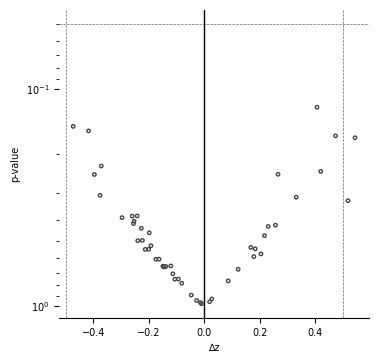

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,17-00881-Bridge,11-00261,12-00032,11-00382,11-00388,11-00416,11-00465,12-00145,12-00196,12-00294,12-00383,13-00075,13-00581,13-00584,17-00641,14-00817,15-00571,15-00764,15-00811,16-00120,16-00271,16-00498,16-00731,16-01098,16-01185,17-00028,17-00115,17-00123,17-00634,18-00007,13-00016,12-00268,16-00120-Bridge,16-00731-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ B_FLT3-ITDxNPM1-WT ============
Transcriptomics


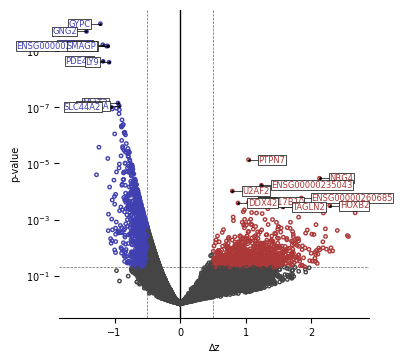

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CFH""",null,-0.32883,-0.503599,-0.407937,-0.526328,null,-0.501488,-0.449388,null,-0.481821,null,-0.452197,-0.317656,-0.503194,-0.48791,-0.402652,0.153041,-0.520931,-0.493545,-0.296135,-0.305689,-0.466458,-0.489032,-0.505017,null,-0.506534,null,null,null,null,0.066802,-0.221191,-0.485859,2.035743,-0.517999,null,…,-0.502221,0.458896,null,-0.476366,-0.49484,null,-0.513764,-0.466868,null,null,null,-0.526328,-0.207197,-0.371975,0.052549,-0.257074,-0.484877,-0.502142,null,-0.526328,-0.460673,3.690437,-0.327168,null,null,0.81461,0.693017,3.679044,null,-0.419752,2.677158,-0.222868,null,2.618249,1.606442,0.036459,0.333714
"""FUCA2""",null,0.213553,-0.764967,0.071093,-0.940642,null,-1.499777,-0.489264,null,-1.845033,null,-0.805703,-1.536435,-1.373133,-1.128104,-0.85072,-1.208112,1.476065,0.165446,0.782369,1.137211,-0.395128,-0.76456,-1.167495,null,0.188494,null,null,null,null,-0.039304,0.039208,-0.775646,0.289153,0.877803,null,…,0.303491,0.901387,null,0.268734,-1.737592,null,0.956691,-1.37243,null,null,null,0.806107,1.245769,-0.938732,-0.078582,2.192875,0.713013,1.132675,null,2.033421,0.688388,-1.077076,-0.624171,null,null,-0.311296,0.926975,0.855539,null,1.489764,1.198887,0.759375,null,0.667746,0.912162,0.003839,0.123221
"""ARF5""",null,0.407444,0.366249,0.651356,-2.47218,null,-0.121,0.8191,null,0.286408,null,-0.291772,0.191556,-0.708616,-0.169232,-0.618091,0.833014,-0.414794,0.902315,0.995721,0.406745,0.348899,-0.081831,-1.168449,null,-1.039314,null,null,null,null,-0.09391,-1.032456,0.405578,0.518932,-0.158368,null,…,-1.470737,-0.838618,null,-0.897188,-2.087765,null,-0.182625,-0.562848,null,null,null,2.767249,0.191541,0.188615,-0.439902,-0.179292,-0.316748,2.486394,null,0.148846,-0.888398,-0.065378,-0.815645,null,null,1.650985,-0.767284,0.901047,null,0.951391,1.186032,0.065243,null,1.574855,0.908125,0.033023,0.324437
"""AK2""",null,-1.257061,-0.434805,0.487746,-1.106296,null,-1.026549,-0.150258,null,0.01773,null,-1.155377,-0.532733,0.812343,-1.029908,-0.854017,0.39233,-0.442109,-0.282098,0.639685,-0.542877,-0.554365,-1.397995,0.120079,null,0.798084,null,null,null,null,-0.017912,-0.142685,-0.112546,-0.180791,-0.305939,null,…,-0.017312,-0.258693,null,-0.547245,-1.243523,null,1.812586,-0.655145,null,null,null,1.539547,-0.106996,-1.275947,-0.890638,0.984802,0.758394,-0.503744,null,-0.608458,-0.311559,1.599321,-0.653448,null,null,-0.065025,1.842737,0.493418,null,-0.298909,1.945049,1.368737,null,3.494262,1.433513,0.028647,0.309762
"""SLC25A13""",null,-0.132611,0.123971,-1.106632,-0.562309,null,-0.357439,-0.135693,null,-1.830763,null,-0.225919,-1.509431,0.150932,1.720358,-0.052729,-0.402309,0.627388,-0.40335,-1.445863,-1.052773,-0.289335,0.818106,3.241241,null,0.388483,null,null,null,null,1.197907,1.210674,0.354939,-1.068413,0.350465,null,…,-0.818387,1.269047,null,0.417244,-2.231642,null,0.520541,-0.072823,null,null,null,-0.423873,0.01435,0.230472,-1.055821,0.242789,0.447851,-0.203005,null,-0.135461,0.583598,1.23967,-0.085713,n

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""SEMA3F""",null,-0.066749,-0.458714,-0.574205,-0.694194,null,-0.324255,-0.648206,null,-0.648084,null,3.186308,-0.673926,2.251813,-0.395676,-0.301065,-0.679282,0.382268,-0.66738,-0.640319,1.73841,-0.118234,0.066522,0.547737,null,0.912172,null,null,null,null,-0.654464,-0.650015,-0.694194,2.889418,-0.357672,null,…,-0.179077,-0.574043,null,0.772403,-0.682259,null,-0.193853,0.260634,null,null,null,-0.576227,-0.592034,-0.052681,-0.045306,-0.68043,-0.203403,-0.673313,null,0.355639,0.527086,-0.694194,3.615014,null,null,-0.601283,-0.226317,-0.59948,null,-0.180192,-0.678895,-0.66911,null,-0.637981,-0.586654,0.001275,0.070338
"""THSD7A""",null,-0.452308,1.789751,-0.513861,0.642176,null,-0.506503,-0.235128,null,-0.506478,null,3.012729,-0.512006,0.136647,-0.439377,5.437892,-0.505675,0.330276,0.653831,-0.511889,-0.185331,-0.510821,0.629499,-0.508811,null,0.860391,null,null,null,null,0.4215,-0.50443,-0.502015,1.425109,-0.408473,null,…,-0.49958,0.087576,null,-0.472424,-0.513315,null,-0.509395,0.838726,null,null,null,-0.508464,0.111495,-0.46155,0.298361,-0.204087,-0.509651,-0.510995,null,-0.510167,-0.509618,-0.426598,-0.252488,null,null,-0.3475,-0.50851,-0.513861,null,-0.487736,-0.512461,-0.505828,null,-0.510432,-0.55287,0.000721,0.050221
"""TMEM132A""",null,-0.795875,1.366782,-0.590171,-0.795875,null,-0.63043,-0.677616,null,-0.677301,null,-0.01628,-0.587399,-0.693153,0.181132,-0.646106,-0.642489,1.648725,-0.657969,-0.685042,-0.55757,-0.112292,-0.423265,-0.511994,null,-0.444316,null,null,null,null,-0.523428,-0.644396,-0.415351,-0.682803,0.136068,null,…,4.020981,-0.707597,null,0.757051,-0.673109,null,1.46359,-0.479053,null,null,null,1.630965,0.159424,0.35172,-0.644181,1.469392,-0.007073,2.533281,null,1.696131,2.225416,-0.53071,-0.306096,null,null,-0.522819,-0.64548,-0.51752,null,0.525895,-0.638506,-0.666864,null,-0.603137,-0.500968,0.035522,0.331475
"""KDM7A""",null,2.092836,0.270257,0.995006,0.20145,null,-0.51611,-0.718422,null,-0.528639,null,-0.358267,-0.733533,0.517854,2.19448,-0.803984,0.071544,0.027447,-0.863423,-0.700616,-0.470609,1.521788,0.115683,-0.095904,null,-0.91568,null,null,null,null,-0.995038,-0.121949,-0.545461,-1.036294,0.159557,null,…,0.519356,-0.765499,null,1.602565,-1.256248,null,-0.308048,-0.210241,null,null,null,-0.354692,-0.239002,-0.106944,0.836308,1.84434,1.766639,0.246741,null,0.360276,1.920717,-0.903917,3.217452,null,null,-0.753289,-1.219075,-0.946136,null,0.354576,-0.882716,-1.372256,null,-1.004119,-0.950696,0.002863,0.108233
"""MARK4""",null,0.357943,1.320816,-0.641248,1.113934,null,0.930581,-0.744002,null,-0.851834,null,1.462653,-0.630732,0.910257,-0.585272,-0.276069,-0.656915,0.165634,-0.781345,-1.092268,-0.197015,0.611577,3.934336,3.170083,null,-0.998382,null,null,null,null,-0.195228,-1.130397,0.18932,1.095406,-0.289596,null,…,-0.338645,-0.405051,null,0.337759,-1.664982,null,-0.520708,0.535387,null,null,null,0.716968,-0.167662,-0.27375,-0.522408,-0.697895,1.068921,-0.103842,null,-0.418859,0.072294,-0

Proteomics


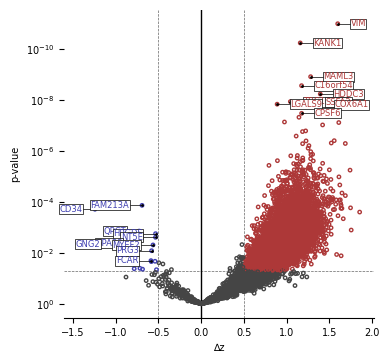

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS""",-1.542259,-1.395823,-0.447862,-0.980851,null,null,null,null,null,null,-1.947741,-1.136345,-1.120729,-0.939463,-1.616692,-1.874056,-0.217609,-0.456842,-1.511112,-0.832212,-0.748149,-0.401336,0.450722,-0.796796,-0.682444,0.138926,-0.347163,0.467166,-0.936152,0.857692,2.113329,0.791053,-0.308266,1.023863,0.542062,0.3426,…,-0.031399,1.46986,1.405213,0.285131,-0.128239,0.343336,-0.42078,-1.988544,-0.236326,-1.397439,-0.034244,1.58668,0.135788,-0.206442,1.022811,1.102638,-0.013074,0.928004,0.054984,0.159476,0.366877,0.970719,-1.267366,2.645251,-0.18844,-0.013034,null,0.70166,1.336155,0.708376,1.706465,1.578477,0.316274,-0.136293,0.870115,0.009994,0.017451
"""AACS""",0.016082,0.891129,0.014929,0.230692,null,null,null,null,null,null,-2.154921,-2.036157,0.586052,0.044943,-1.254978,-1.919572,-0.983412,-0.481312,-1.884537,-0.58567,-1.136294,0.515246,-0.747527,0.509453,0.612145,0.656307,-0.171533,-0.217533,-0.81261,0.097776,-0.319522,-0.960065,-1.13896,-2.883177,0.162554,-0.091256,…,0.368588,-1.067844,1.252179,-0.501623,-0.753393,-0.789782,-0.314534,-0.266404,1.436187,1.556085,0.029323,0.206673,1.82686,-0.603951,-0.186946,1.051341,0.529674,0.916148,1.730691,-0.131115,0.849734,-0.400351,-0.354508,1.41537,-2.019163,1.083997,null,0.887867,-0.319743,1.710934,2.057709,1.274579,0.507716,0.761482,1.118099,0.002742,0.007738
"""AAGAB""",-0.618605,1.092347,0.103645,0.071595,null,null,null,null,null,null,-2.510515,-2.470933,-0.670336,-0.968585,-0.292929,-0.822523,-1.921802,-1.082432,-1.353139,-0.438344,-0.97086,-0.404948,0.233059,0.080315,-0.240851,0.042966,-0.103969,-0.46013,-0.664431,0.246239,-0.266921,0.975007,-0.644519,-1.278079,0.085209,0.16072,…,0.040528,-0.830976,0.87779,-0.380387,-1.154639,-1.146293,-0.645516,-0.191312,1.884401,0.652709,0.748392,-0.131609,1.855103,-0.217422,-1.114269,1.671624,-0.052839,-0.266978,2.161232,-0.276165,0.936151,-0.834007,0.013851,1.742052,-1.213686,0.33313,null,1.381746,0.373073,1.750704,2.40928,0.452147,0.892648,0.916453,1.194558,0.001875,0.006304
"""AAK1""",-0.207097,1.02427,0.009679,-0.033026,null,null,null,null,null,null,-1.689299,-2.03898,-2.07001,-0.8117,-0.413482,-2.366944,-1.3957,-1.303839,-1.260513,-0.104213,-0.959681,-0.405905,-0.786658,1.283918,0.075197,-1.203633,0.144542,-0.16955,-0.742618,0.58737,-0.363489,-0.120275,-0.885915,-0.648691,-0.160846,0.122917,…,0.481692,-1.030489,-0.087672,0.111969,-0.151138,-0.596446,-0.380569,-1.146551,1.230414,0.089163,0.396183,1.171746,1.470221,0.621141,-0.204764,2.463535,0.590068,0.554144,2.023098,0.569228,0.775063,1.620893,-1.274666,-0.375303,-1.276747,0.101477,null,0.850621,0.237815,1.66316,1.993524,0.70526,1.411545,0.694378,1.075034,0.001991,0.00649
"""AAMDC""",-0.206425,-0.716536,0.783744,-0.058159,null,null,null,null,null,null,-1.037646,-1.939039,-1.345919,-0.033993,-1.129138,-1.613604,-1.352352,-0.391569,-1.6348,0.33674,-1.712471,-0.055434,-0.386299,0.672554,0.572812,0.658969,-1.539663,-0.659174,-0.148407,-0.30471,0.390307,0.0286,-0.746569

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AHSP""",-0.927681,-0.804271,-1.094587,0.667918,null,null,null,null,null,null,-0.350053,-1.259629,-0.550695,-1.264223,-1.109643,0.10557,0.290306,-0.96631,null,-1.084175,0.372638,0.027763,-0.409492,-0.73969,1.112539,-0.946855,-0.838155,-0.197818,1.776707,-0.397934,1.119548,2.016705,-0.747401,-1.580697,0.124796,1.971159,…,0.650593,1.371802,0.309726,null,0.389878,-0.713967,-1.071377,1.557006,-0.766302,0.28428,0.868452,-0.658408,0.996198,-0.718245,-1.538931,0.379879,0.04834,-1.18117,2.008374,-0.083024,0.734904,-0.81887,0.373411,0.345216,null,-0.152695,null,-1.37307,-0.132375,0.262137,-0.972053,-0.309784,-0.787189,-0.667555,-0.583228,0.022191,0.032334
"""APP""",-0.508249,1.435003,-0.713875,0.333159,null,null,null,null,null,null,-2.216796,-0.230126,-0.169105,0.113517,-0.440136,-0.366757,1.629585,0.763995,-0.572198,2.215416,-0.425326,0.97802,0.041514,0.084344,-0.308671,-0.086823,-0.054991,0.527503,-2.605791,0.95549,0.421679,-0.450899,0.660291,0.708331,1.136829,1.12354,…,-0.292029,-1.387204,1.202318,0.930668,-1.86927,0.880809,-0.315481,1.14343,0.413139,0.132786,-0.833366,0.608893,0.190356,-0.547569,1.282595,-1.046919,-2.452934,1.046084,-1.017768,0.081033,-0.652907,0.910869,-0.072257,-0.802389,-0.729685,-0.911552,null,0.616827,-0.709378,0.193389,-0.133616,-1.574339,-1.262393,-1.319051,-0.715978,0.040593,0.053806
"""CA4""",-0.505503,1.853652,-0.062877,0.788238,null,null,null,null,null,null,0.150503,0.284747,0.420607,-0.942779,0.87467,0.656352,-0.949527,-1.534105,-1.696643,0.487961,1.499225,0.561396,0.335748,-1.435309,0.648274,0.217959,0.368464,-0.342047,-1.474572,0.110213,-0.542245,-0.222716,-0.395078,-0.912452,0.622129,2.795059,…,-0.163547,0.786483,0.589671,-2.888126,0.066479,-0.442531,-1.235947,0.700633,1.33489,1.065416,1.043224,-0.58343,1.279759,0.474854,0.52019,-0.251903,-1.68437,-0.018495,0.120882,0.107217,0.187143,-0.834081,-0.786453,-0.814721,-0.718903,null,null,-0.561314,-0.319181,0.614044,-0.985499,-1.255667,-0.360418,-1.465767,-0.685789,0.043973,0.057653
"""CD34""",-1.33872,-0.980798,1.080388,-0.131088,null,null,null,null,null,null,-0.660135,0.297102,-0.850579,0.941584,-1.443437,-1.528937,0.518846,-0.072907,-0.629734,-0.02597,-0.018339,-0.166496,1.03868,-2.054367,-0.424055,0.094191,0.973697,0.987715,-0.44802,1.132376,1.150005,0.767481,1.480259,-0.149164,1.650466,0.193302,…,-0.913241,0.151168,-0.447166,0.862103,1.416539,1.066651,0.618699,0.106913,-1.849179,1.148626,-0.642678,0.794784,-0.990593,-0.608879,1.740851,-0.905314,-1.568392,0.253007,-0.313234,-0.459378,-0.165622,0.65807,-1.681517,1.681857,0.484016,-0.958597,null,-0.065967,-0.864971,-1.499578,-1.121057,-0.881617,-1.388331,-2.070577,-1.242501,0.000196,0.00258
"""FAM213A""",-0.657608,-0.488876,-1.063258,-0.249946,null,null,null,null,null,null,1.325273,1.082037,-1.188197,0.512927,-0.084716,0.342491,1.499779,-1.158423,-1.465799,-1.409161,-0.377131,-1.269111,1.180676,-0.677315,1.510378,1.119643,-1.477385,-0.206249,-1.686288,-1.001344,1.862104,-0.209077,1.295828,2

Phosphoproteomics


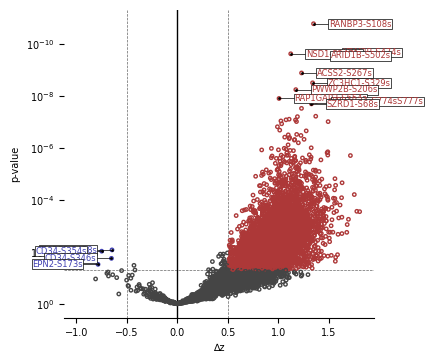

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAK1-S20s""",-0.232702,0.797706,-0.735363,null,null,null,null,null,null,null,-1.530117,null,-2.493254,-0.6046,-0.76177,-1.265441,-1.106084,null,-0.510382,-0.590834,-1.100266,-1.147387,-0.583367,null,-0.292071,-0.106818,-1.024001,null,-0.417458,null,-0.313824,0.018426,null,null,null,null,…,0.053347,null,0.235535,null,-0.651687,0.01545,null,-0.730482,1.019936,-0.220521,null,1.661606,null,1.047111,-0.54162,null,0.404963,1.057119,2.168077,0.231329,null,2.085892,-0.893581,null,-1.332266,0.479436,null,0.354492,null,1.92029,1.802266,0.59829,1.556108,1.191039,1.308435,0.000891,0.006309
"""AAK1-S637s""",0.209207,0.115947,0.35562,-2.246627,null,null,null,null,null,null,-1.994915,-1.04469,-2.21904,-0.008995,-1.190808,-0.222406,null,-0.580768,-0.771075,-1.137394,-1.708731,-0.272672,-0.711491,0.364697,-1.024219,-1.228444,0.602022,-0.524817,-0.70452,-0.248658,-0.117671,0.067946,-1.041467,0.529182,0.463319,-0.106077,…,1.033709,-0.133804,-0.775556,0.367483,null,0.016048,-0.128321,-0.729273,2.315736,-0.10871,0.734946,1.813779,1.123318,1.505859,-0.030029,2.082634,0.744922,0.132706,1.918748,0.594209,0.512056,-0.269078,-0.872749,-0.679597,-0.991204,0.314926,null,0.580794,0.857347,1.269899,1.498213,-1.273079,1.495296,0.772235,0.777003,0.048365,0.07253
"""AAK1-S670sT674tS678s""",null,null,0.455455,null,null,null,null,null,null,null,-1.329943,-0.843083,null,0.45729,-0.454744,-1.302413,-1.110538,-0.810255,-0.249454,-0.338462,-0.847554,0.090271,-0.573825,0.550462,-2.846388,-0.93214,0.023267,-0.734712,-0.796241,0.452822,0.01258,0.052558,-0.850748,0.82642,0.761471,0.012194,…,1.518777,-0.788581,-0.460917,-0.195487,-1.237785,-0.243975,-0.648986,-1.214978,0.999944,-0.095225,0.374329,1.433229,1.511664,1.262773,-0.237777,2.402747,0.875055,0.016575,1.413604,0.866005,-0.55373,1.60941,-1.704015,-2.134276,-0.983334,null,null,0.789232,0.80306,1.606202,1.584997,0.50505,0.892894,0.858839,1.121168,0.000056,0.001679
"""AAK1-T606t""",-0.322396,0.10375,0.797769,0.103229,null,null,null,null,null,null,-1.806668,-1.441886,-2.269473,-0.775226,-0.606671,-1.972968,-1.451819,-0.869878,-0.559534,0.112661,-0.834578,-0.410351,-0.803694,1.262689,-0.663979,-1.717362,0.311043,-1.273521,-1.136501,0.306615,-0.183597,-0.34626,-1.348001,0.265863,0.722519,0.430393,…,0.259503,-0.860097,0.07884,-0.073961,-0.500951,-0.410384,0.003157,-0.442278,0.693932,-0.456918,0.879153,1.262155,1.7895,1.254882,-0.215905,2.262415,1.042247,0.375981,2.247974,0.817115,0.935572,1.692447,-1.248356,-0.904164,-0.90432,0.234047,null,0.315854,0.345743,1.355507,1.921856,0.894243,1.619147,0.325176,0.984317,0.003636,0.013175
"""AAK1-T620t""",0.072488,0.740562,1.172272,0.321233,null,null,null,null,null,null,-0.852024,-1.044581,-3.257378,0.309102,0.42675,-1.865965,-1.930165,-0.343035,-0.950522,0.530462,-0.786894,-0.008177,-0.952786,0.500628,-0.201836,-0.633322,0.518022,-0.484048,-0.629117,0.580817,-0.517839,-0.11533,-1.282316,-1.164193,0.168741,-0.061063,…,-0.165353,-0.820662,0.542815,0.047126,-1.084356,-

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CD34-S346s""",null,0.063058,1.120947,null,null,null,null,null,null,null,-1.317259,-0.160925,-2.700304,0.586749,-0.670761,-1.370247,0.852105,-0.136859,0.186199,-1.142135,-0.787312,-0.210035,0.953325,-1.577913,-0.075095,-0.047604,0.655045,0.309244,-1.332409,0.503259,0.830898,0.601078,2.238049,0.545286,2.520212,-0.297206,…,-0.908231,-0.58923,-0.470297,0.161699,0.598381,2.039444,1.213285,0.494197,-1.336076,0.732561,-0.458657,0.545028,-0.233918,-0.949577,1.669703,-0.411437,-1.595445,0.875193,-0.380193,-0.626359,-0.637682,0.70481,-1.772988,0.566256,0.292568,-1.406932,null,0.377439,-0.503779,-1.121407,-0.149171,-0.291896,-0.54515,-0.983003,-0.651383,0.017858,0.035276
"""CD34-S354s""",-1.618267,-1.11668,1.958265,-0.991315,null,null,null,null,null,null,0.114072,0.888858,-2.48028,0.883387,-0.850715,-0.284197,0.113928,0.855026,-0.223354,-1.321128,-0.403195,-0.155042,0.92805,-1.381269,-1.004414,-0.28729,0.351885,1.42487,-0.952712,1.419019,1.190473,0.378664,0.253574,-0.262158,2.545778,0.032186,…,-0.832147,0.35343,0.074428,1.150968,0.007571,0.488595,-0.471669,-0.356323,-1.009799,1.17663,-0.247456,1.344565,-0.914251,-0.831002,2.271337,-0.794689,-1.048564,0.041079,0.698611,-0.525723,0.582767,0.867925,-1.552121,-0.594256,0.991243,-1.374141,null,-0.228127,-1.576584,-0.30062,-0.640791,-0.262431,0.067213,-1.013964,-0.748172,0.009484,0.023245
"""EPN2-S173s""",-0.710011,null,0.694811,-0.040187,null,null,null,null,null,null,null,-1.133907,null,-0.50706,-1.602406,0.911018,-0.819221,-1.100723,null,-1.534418,0.522351,null,0.80767,-1.774378,null,-0.650272,null,-0.019721,null,0.384179,1.448661,null,-1.127879,0.47843,0.829367,0.530691,…,1.397282,0.099133,null,1.142407,-0.35651,-0.123517,-0.295357,null,0.421182,null,-0.451098,null,1.646831,null,null,0.58823,1.674747,null,2.254858,null,1.582419,-1.529612,null,0.428978,-1.5465,-0.504758,null,0.046698,-1.133595,-0.059498,null,-1.627187,-0.850992,null,-0.784253,0.030422,0.050978
"""TMCC2-S438s""",null,0.056561,0.614041,-0.909539,null,null,null,null,null,null,-1.113322,-0.843715,-0.598489,-0.925826,0.040148,-0.111869,-0.262181,0.645241,-0.686115,-1.835026,0.887963,1.45842,-0.836594,-0.555604,0.343363,-1.211728,-0.078738,0.701002,-0.03244,0.190329,1.940259,1.898093,-0.751159,0.809917,0.418399,1.944143,…,-0.900324,1.318238,-0.343879,-1.78458,1.688483,0.338387,-0.984157,0.023939,-1.653267,-0.105342,0.187101,0.289658,0.570334,-0.656196,-0.077084,0.839883,0.322645,-0.625749,2.116427,-0.529384,0.675161,-0.680976,-0.989041,-0.849691,-0.995419,-1.036113,null,-0.090553,-0.805664,0.22137,-0.483203,-0.32583,-0.888259,-1.186714,-0.646167,0.008448,0.021761


Acetylomics


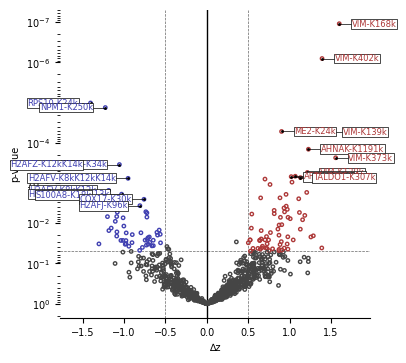

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AFF1-K582k""",0.335458,null,1.287542,1.21415,null,null,null,null,null,null,-1.225531,-0.635264,null,-0.297214,0.529286,-0.237802,-1.174702,0.545785,-0.423744,0.075009,-0.797457,-0.287035,-0.434572,0.622133,-1.611365,-0.890581,0.493548,-0.274924,-0.402916,0.015207,0.367671,-0.136104,0.432122,-0.009838,1.248278,-2.074025,…,0.823204,-0.718885,-0.477171,0.007344,-1.596027,0.922403,0.127411,0.036903,0.186696,0.51056,0.881271,0.79717,0.623821,0.65219,0.720542,0.875113,0.380134,0.269087,-1.381011,0.149421,-0.039505,1.010615,-0.873794,-2.955334,1.758643,1.408186,null,0.14344,0.36939,1.156336,1.661479,0.316377,1.129406,1.053988,1.019724,0.000694,0.044449
"""AHNAK-K1191k""",null,null,null,null,null,null,null,null,null,null,-0.609267,-0.655949,null,-1.299473,-0.340781,-1.389246,null,0.516503,-0.696333,-1.686588,0.13243,0.126161,0.577373,-0.82262,-1.918211,-1.074377,0.09713,-0.778826,-0.526309,1.006713,-0.270561,-1.385017,-1.037076,-0.984889,0.266037,-0.180721,…,1.164022,-0.683952,1.547828,0.991069,-0.896021,-1.564318,0.108448,0.267825,1.404507,-0.031958,-0.312094,1.866247,1.55968,0.176083,-0.156375,1.089091,1.043496,0.080302,1.556658,0.37515,0.782281,0.060146,null,-1.704012,-0.430115,1.846903,null,1.27368,0.134571,1.359318,1.299524,0.410037,1.379052,0.92938,1.227894,0.000144,0.0184
"""ANP32A-K110k""",null,null,-0.299153,null,null,null,null,null,null,null,-0.424204,-0.640791,-3.162024,-2.77064,-1.751482,-0.297133,-2.602714,0.216477,-2.610303,-1.567142,0.404115,-0.047912,0.348013,0.699144,-0.032561,0.446113,-0.118122,-0.155164,-0.034705,-0.474498,-0.832718,0.649112,0.647515,-0.4412,0.299297,0.238401,…,0.733028,-1.313967,0.179325,0.818416,-0.105586,-1.381779,-1.674326,0.475953,0.98781,0.407519,0.142201,-0.132464,0.47263,1.792753,1.334075,0.145899,-0.142764,0.630342,0.27825,1.395904,-0.7633,-0.561523,0.052611,0.584133,-0.424697,null,null,0.292691,-0.363625,0.712131,0.897741,0.495734,0.892535,0.362686,0.523047,0.025958,0.267009
"""ANP32B-K110k""",null,null,-0.299153,null,null,null,null,null,null,null,-0.424204,-0.640791,-3.162024,-2.77064,-1.751482,-0.297133,-2.602714,0.216477,-2.610303,-1.567142,0.404115,-0.047912,0.348013,0.699144,-0.032561,0.446113,-0.118122,-0.155164,-0.034705,-0.474498,-0.832718,0.649112,0.647515,-0.4412,0.299297,0.238401,…,0.733028,-1.313967,0.179325,0.818416,-0.105586,-1.381779,-1.674326,0.475953,0.98781,0.407519,0.142201,-0.132464,0.47263,1.792753,1.334075,0.145899,-0.142764,0.630342,0.27825,1.395904,-0.7633,-0.561523,0.052611,0.584133,-0.424697,null,null,0.292691,-0.363625,0.712131,0.897741,0.495734,0.892535,0.362686,0.523047,0.025958,0.267009
"""ANXA1-K161k""",null,0.601939,0.213971,1.168451,null,null,null,null,null,null,0.630197,0.56775,-2.569193,-1.413066,-0.747546,1.664407,-0.764254,-0.040134,-1.391334,-1.509763,0.988067,-0.248921,-0.710208,-1.682603,0.242013,-0.67463,-0.704741,-0.448194,-0.278839,-0.311216,-1.619149,-1.410279,-2.792868,-1.917988,0.404944,0.928753,…,-0.224636,-0.496119,1.272255,0.09

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ALDH7A1-K93k""",null,-0.023,0.046363,-1.445426,null,null,null,null,null,null,0.99697,0.412987,-0.791612,0.572163,0.816999,0.148165,-1.167779,-1.263905,-0.464888,0.194758,1.427443,0.362771,0.705608,1.174836,-0.130333,0.422891,-0.080574,0.885855,-0.038327,1.040046,-0.348891,-0.113741,-0.873611,-0.229448,1.250021,0.653787,…,null,1.076394,-2.101419,0.150263,-1.624469,0.110838,-0.440811,0.184517,null,0.483843,-1.175185,-0.682865,-1.241621,1.208444,1.238659,-2.466396,-1.596094,0.471259,-0.308093,-0.619152,null,0.866273,-0.179978,0.757719,-0.332608,-0.508784,null,-1.126054,-0.031446,-1.392172,0.648307,-0.349666,-0.575795,-1.352595,-0.662881,0.036446,0.306696
"""ANXA11-K408k""",0.146405,0.346242,null,-0.251065,null,null,null,null,null,null,0.159036,-0.602776,null,0.903411,-0.206942,-0.048099,-1.767318,null,null,-0.762854,1.128591,null,-0.547511,null,null,0.05952,0.537314,null,-1.458926,-0.197048,0.072185,null,0.615733,null,null,2.259321,…,-0.199041,null,0.517308,-1.165957,0.866739,-1.019641,null,0.03608,0.276869,null,null,0.194825,-0.172353,null,1.476164,-1.057269,-0.93254,null,-0.244895,1.41707,0.010244,-1.245938,null,null,0.448117,-1.150471,null,-2.251144,0.254728,0.2963,-1.119536,-1.529426,-0.778163,-0.290683,-0.973803,0.017343,0.237997
"""BLVRA-K269k""",1.260637,-0.928464,1.503401,3.931043,null,null,null,null,null,null,1.19658,null,0.312833,0.315031,0.334481,0.945819,-0.614211,0.934911,-0.687314,0.347246,0.288146,-0.425172,1.261715,-1.396622,2.1192,-0.821028,0.2204,0.305033,-1.679482,0.299341,-1.066599,-0.125922,0.051604,0.300636,0.464094,0.809296,…,0.120087,-1.693425,-0.399217,-0.904221,-0.603211,-1.778745,0.168243,1.262627,1.548593,1.369252,-1.029451,-0.942655,-0.781477,-0.750149,-0.838381,0.139237,-0.587817,0.946265,1.02151,-0.703122,0.901107,-1.39154,0.100813,-0.175506,-1.394672,-0.555873,null,-0.481985,-0.72504,0.31214,-0.579229,-0.653753,-0.996775,-1.55906,-0.736815,0.005171,0.129374
"""CCAR2-K215k""",null,-1.595981,null,-0.129649,null,null,null,null,null,null,0.699275,0.236656,null,1.466169,0.409146,-0.799735,-0.076127,0.352773,-1.270218,-0.075911,1.486164,-1.297127,0.355011,2.105233,-1.921747,1.354083,1.720729,1.499855,2.112917,1.183332,0.606282,-0.923058,0.94724,1.933113,0.359049,0.974604,…,0.865334,-0.452478,-1.023465,-0.779599,-1.674159,-0.100809,0.06058,-0.555102,0.988198,-0.322279,0.588027,-0.558811,-0.91287,0.961246,-0.563671,-1.266921,0.795009,0.377242,-0.786351,-0.394513,-0.564693,-0.437988,-1.284753,-1.291377,0.653406,-0.319515,null,-0.539652,0.170099,0.172617,-0.314979,-0.968203,-1.469294,-1.31869,-0.647446,0.02641,0.267009
"""COTL1-K72k""",-0.328809,null,1.364761,null,null,null,null,null,null,null,null,-0.976327,null,0.151207,null,null,null,1.942342,null,null,1.043722,null,null,-0.093782,null,0.060671,0.204546,0.051813,0.378566,-0.150424,null,null,0.307782,-1.062395,1.108073,0.626383,…,null,-1.020952,1.539683,0.556143,null,null,0.366682,-0.207788,null,null,-0.764997,-0.684585,1.615304,null,-0.53128

Lipidomics


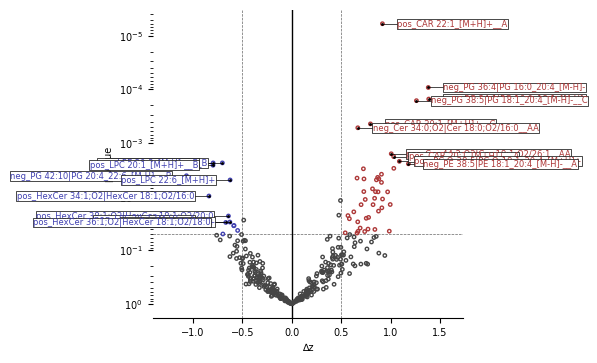

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPG 18:0_[M-H]-__A""",0.207264,null,0.009843,null,null,null,null,-0.671926,-3.084814,-0.626124,-0.559052,0.127463,-3.918838,-1.251469,-1.313047,-0.178312,0.155247,-1.49335,-0.233815,-0.010606,0.309195,0.5105,-1.01285,0.126134,0.710277,0.544393,-0.581155,0.952186,-0.098639,0.929812,-1.055715,0.071139,1.383071,-0.990469,-0.091,-0.411431,…,1.138978,-1.184113,-1.284489,-0.472194,-2.200263,0.5147,0.417679,0.384227,0.776708,1.260723,0.070628,0.839909,-0.420967,-0.790856,0.214582,0.89625,1.470955,0.873993,1.494056,0.105975,-0.227746,-0.512046,0.613668,-1.011364,null,null,0.094922,0.001746,1.314456,0.437056,1.028189,0.446243,0.831853,0.549278,0.660333,0.004533,0.073283
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-1.304298,null,0.205666,null,-1.877715,-2.336927,-0.671176,-0.559277,-0.89684,0.730015,-1.528752,0.924474,-0.121785,2.107107,0.158423,-1.873054,-0.017167,0.410613,-0.225106,0.735596,-1.569228,-0.574981,-0.465229,-0.156281,-1.043631,-0.057784,-0.333594,0.473044,-0.109398,0.364759,0.730195,0.993495,-1.085776,0.540492,0.794747,-1.860314,…,-0.021828,0.976691,0.444138,0.547362,-0.154064,1.175937,0.78952,-1.591981,-0.033355,-0.954576,-0.48851,0.489138,-1.474352,0.631859,0.883681,0.418319,0.686194,0.095807,-0.267403,-0.912236,-0.795319,0.313918,-0.62282,0.909535,null,null,1.017552,1.520874,1.923878,0.151462,1.420306,1.782571,1.387895,0.680967,1.381063,0.000093,0.013984
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.215346,null,0.795471,null,-2.441927,-1.966074,-0.915823,-0.483266,-0.888357,0.279216,-0.10746,0.794978,-0.830775,1.136461,-0.391025,-1.149383,-0.903751,-0.814991,-0.488269,-0.294001,-1.121868,-1.291125,0.036713,-0.093762,1.331255,0.399075,-0.539235,-0.968015,-0.854319,-0.551013,0.797477,0.237136,-0.41343,-0.34982,0.006833,0.022341,…,0.769201,0.748982,-0.021423,1.039508,0.074314,0.546116,-0.632635,-1.389862,-0.30681,1.144033,-1.361237,0.865305,-1.094948,2.380518,0.463456,0.148231,0.258864,0.203508,-1.024416,-0.035257,-1.473879,0.433882,-0.004088,2.162146,null,null,0.321056,0.892991,0.797209,2.014038,1.861902,1.040461,0.748887,1.351352,1.26125,0.000163,0.013984
"""neg_PG 34:2|PG 16:0_18:2_[M-H]…",-0.835229,null,0.259231,null,-2.285279,-2.742033,-0.876752,0.193112,-0.667221,-0.100126,-0.716662,-0.466087,0.30455,1.103579,0.954836,0.534101,0.888643,-0.784361,1.079024,0.250012,0.140463,-0.019744,0.180968,1.492705,-0.734978,0.077395,-0.921876,-0.774893,-1.056783,-0.584441,0.71958,1.058284,-0.537509,-0.467674,-0.743222,-0.742827,…,0.759907,0.835589,-0.930589,0.429675,-0.215208,1.95968,0.527086,-1.328964,0.21815,-1.636504,-0.397901,-0.236251,-1.357112,0.191948,-0.150869,0.561372,2.098452,-0.32932,-0.325366,-0.183514,-0.074807,0.860002,0.117964,2.601947,null,null,1.316481,-0.178241,1.869377,1.441341,0.763475,0.719842,0.969252,-0.32875,0.918256,0.011128,0.117939
"""neg_PI 37:4|PI 17:0_20:4_[M-H]…",-0.030635,null,0.941094,null,-2.497806,-2.970579,0.055936,0.03974,-0.594966,1.095485,-0.881239,-0.572112,-1.539933,0.417872,0.703239,0.1

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 22:6_[M-H]-__B""",0.849367,null,0.031787,null,1.708379,2.899714,1.185776,0.897843,1.486716,0.566569,0.142487,0.606828,-0.168329,0.657245,0.539455,2.111066,-0.193652,0.119072,-0.012136,0.227433,1.745584,1.547921,0.195106,0.396514,0.288138,1.652541,-0.467357,0.183066,-0.370741,0.979318,1.354223,-1.098798,-0.142795,-0.859321,-0.577494,0.133305,…,-0.91685,-0.167379,-1.907159,-1.339492,-0.523074,-1.592387,-0.837193,-0.280005,-0.215144,-0.069901,-1.017903,-0.713653,-0.659353,-1.336236,-1.281093,-0.577475,-1.933429,0.906945,-0.512646,0.474645,-0.965213,-0.033517,-0.798691,-0.832855,null,null,0.047762,-0.857765,-0.761787,-0.026857,-0.539149,-1.234506,-0.848415,-0.806571,-0.702342,0.002361,0.068809
"""neg_LPE 20:4_[M-H]-__C""",-0.486943,null,-0.550064,null,0.850925,2.97328,0.633296,1.316761,1.057219,0.448861,-0.372532,0.900762,0.408161,1.206719,0.597235,2.344475,0.192454,-0.1446,0.537863,0.502638,1.805623,1.714076,0.388701,0.801507,-0.032222,1.801542,-0.151948,0.088034,-0.170661,0.670652,1.211284,-0.201296,-0.016441,-0.524137,-0.719961,-0.443606,…,-1.127747,-0.011003,-0.596675,-1.265776,-0.511359,-0.904149,-1.02334,-0.689428,-0.730094,0.076844,-1.269168,-0.685736,-1.204941,-1.018033,-0.944807,-0.438171,-1.732455,0.731644,-0.560886,0.052475,-0.909417,-0.619417,-1.092435,-1.365755,null,null,0.67325,-0.873128,-0.797531,0.009647,-0.897497,-0.92119,-0.905023,-0.209733,-0.547815,0.042911,0.257114
"""neg_LPE 20:3_[M-H]-__A""",1.205097,null,-0.2184,null,0.617152,1.246762,0.055522,1.581159,1.324491,0.569077,0.146862,0.76101,0.788886,0.71653,0.367447,2.237402,0.409421,0.265589,0.379175,0.732943,2.085296,2.099378,-0.041772,0.945805,0.521256,0.697178,-0.04214,0.825283,-0.044636,1.259571,0.823761,0.869629,-0.271897,-0.913501,-0.200461,0.989606,…,-1.106745,0.824392,-0.527032,-2.051485,-0.287089,-0.138439,-1.849282,-1.122963,-1.654828,-0.371178,-0.829711,-0.876634,-1.207626,-0.520825,-0.704616,-1.009419,-1.390606,-0.269678,-1.296364,0.06553,-1.827329,0.133678,0.004088,-1.482949,null,null,0.673051,-1.769745,-1.472172,0.139295,-1.013001,-0.764734,-1.295248,-0.441094,-0.830362,0.026877,0.196145
"""neg_LPE 20:3_[M-H]-__B""",0.597151,null,-0.313505,null,1.602151,2.736388,0.908907,1.118107,1.363475,-0.057893,-0.182132,0.230342,0.90974,0.774876,-0.033594,2.286808,-0.195486,-0.159195,0.162951,0.23873,1.577189,1.565417,-0.130087,0.611049,0.681549,1.562332,-0.461451,0.414928,-0.418844,0.588027,0.197098,1.075647,-0.240234,-1.11893,-0.319892,0.42561,…,-1.322666,0.069516,-0.442533,-1.215641,-0.119509,-0.492087,-1.014909,-0.134439,-1.320452,-0.001982,-0.939821,-0.770132,-1.143195,-0.778107,-0.940616,-0.94276,-1.748157,0.165092,-0.606503,-0.057239,0.064995,0.225836,-0.806671,-1.141994,null,null,0.201773,-0.817486,-1.27183,-0.30403,-1.125837,-0.711576,-1.200804,-0.465928,-0.795725,0.002363,0.068809
"""neg_LPE 18:1_[M-H]-__A""",1.502238,null,-1.43667,null,0.968894,2.100821,0.555655,2.330463,0.930707,-0.338651,0.698958,1.886084,1.345159,-0.816675

Metabolomics


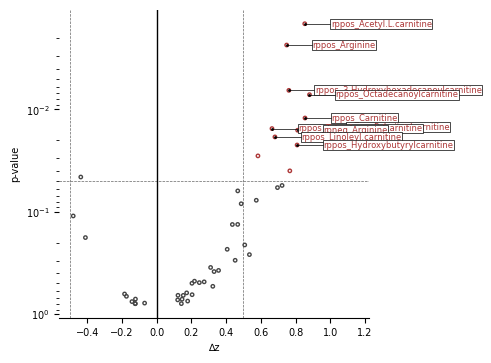

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_3.Hydroxyhexadecanoylcar…",0.627262,null,-1.728641,null,-1.173779,-0.84158,-1.000139,-0.923439,-2.181236,-0.919689,-0.579179,0.082419,-1.473882,-0.512808,-2.129273,-1.217991,-1.588233,-1.032691,-1.963764,-0.376579,-0.819717,-1.310512,-0.515021,-0.38647,1.454946,-0.264087,-0.882361,-0.891168,-0.470562,1.005753,0.522939,-0.229449,-0.464548,-1.375386,0.093458,-0.459609,…,1.405613,0.100269,-0.274047,0.472574,1.113026,-0.421497,0.434716,0.135653,0.037356,0.708997,0.040625,0.606192,2.465368,0.483378,-0.694471,0.865921,1.481337,1.168988,1.92229,1.10073,1.513613,-0.335591,2.359188,0.44346,null,null,0.100071,0.421228,0.28873,0.087038,1.291219,1.484238,1.238767,0.540662,0.76167,0.006525,0.088097
"""rppos_Acetyl.L.carnitine""",1.665457,null,-1.215304,null,-2.789439,-0.690226,-1.338227,1.303796,-0.707346,0.230492,0.436804,0.456092,-0.43065,-0.293198,-1.367427,-0.22048,-1.620034,0.135837,0.378186,0.483009,0.070968,-2.194102,1.23043,-0.122903,1.815929,-1.668681,-0.674515,-0.464662,0.683773,-0.090329,-0.133137,0.100574,-2.635757,-0.690593,1.554094,-1.87758,…,0.045952,-1.004947,0.392409,0.780311,0.651253,1.300663,-0.609512,1.300113,0.450839,0.195933,0.57115,-0.186318,1.611606,0.48636,-1.22579,0.346405,-1.050748,-0.343177,0.473576,-1.067694,0.871053,0.275676,-1.548762,0.375803,null,null,0.132057,1.079936,1.188326,-0.034954,1.3909,1.049922,0.589209,0.712224,0.853271,0.001459,0.05772
"""rppos_Arginine""",0.84406,null,-0.748368,null,-0.358998,-0.761296,-0.227874,-2.979938,0.662461,1.52451,0.028864,1.28337,-0.000367,0.019274,1.056697,1.078023,0.482683,-1.884898,1.570979,1.261979,0.557614,-0.071675,2.156052,0.220687,-0.566167,-0.085609,0.274503,0.057158,-1.20592,1.319299,0.47461,0.759909,-2.02005,0.972984,0.403817,-1.814312,…,-1.016832,0.367677,-2.10274,-0.398923,1.737171,0.21304,-0.915441,-0.431769,-0.640186,-0.254855,-0.013253,0.074592,-0.328334,0.081285,-0.548406,0.44657,-0.356315,0.431033,0.462211,-1.169373,-0.607425,-0.182714,-0.57642,0.19517,null,null,0.709278,1.704419,0.352811,0.542514,0.904255,0.223661,0.32615,0.598016,0.748978,0.002356,0.05772
"""rppos_Carnitine""",-0.629036,null,-0.075422,null,-3.177657,-0.860112,-1.458331,0.426135,-0.916754,-0.291709,-1.229098,0.47321,-0.054967,-0.423866,-1.620205,-0.409276,-1.653238,-0.20421,0.183168,-0.355954,-0.270061,-2.449391,1.108858,-1.028242,1.111794,-1.840371,-0.077061,-0.273083,0.527298,-0.326387,-0.247441,0.395245,-2.339368,-0.01544,1.067889,-1.884087,…,0.453257,-0.621301,0.555392,0.427468,0.767449,0.822672,-0.0717,1.121326,1.064094,0.618091,0.59413,0.293402,1.97242,0.70535,-0.104651,0.937036,-0.922418,-0.104,0.360421,-0.222589,1.270876,1.074336,-1.481506,1.316374,null,null,-0.590249,0.944409,1.182983,0.029119,1.039198,1.389985,0.604637,1.518105,0.854747,0.012151,0.097959
"""rppos_Dodecanoylcarnitine""",1.887397,null,-2.031757,null,-2.605235,-2.07261,-2.543125,-0.550198,-2.003355,0.024818,0.127185,0.21801,-1.757611,0.23158,-1.667495,-1.181468,-0.918559,-0.508848,-0.805886,-

Feature,14-00240,16-00538,16-01109,17-01060,C-05-0664,C-04-1820,C-07-3682,C-10-1211,C-10-3429,C-08-2091,C-13-0276,C-08-3337,C-98-0846,C-10-3924,C-09-3512,C-09-1906,C-09-5462,C-08-3493,C-04-3407,C-09-1074,C-09-4769,C-10-3906,C-07-2070,C-05-2179,C-05-2448,C-07-2900,94-C-279,C-05-1287,C-04-1098,C-09-5381,C-09-1608,C-02-0218,C-96-117,C-95-054,C-05-0569,C-12-4258,…,C-01-1599,C-08-2081,C-09-0923,93-C-201,C-12-2943,C-01-1998,C-95-068,C-01-1665,C-99-2136,C-05-1782,PS88-0050,C-01-2163,C-02-0350,C-01-0171,C-99-1077,C-05-0004,C-05-3159,C-05-4372,PS89-0158,C-98-0031,94-C-077,C-98-0033,C-98-0665,C-02-1356,16-01109-Bridge,17-00313,C-09-0261,C-05-0319,C-01-2143,C-12-1118,C-11-0287,C-04-0434,PS88-0140,C-99-2065,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


============ W_FLT3-ITDxNPM1-WT ============
Transcriptomics


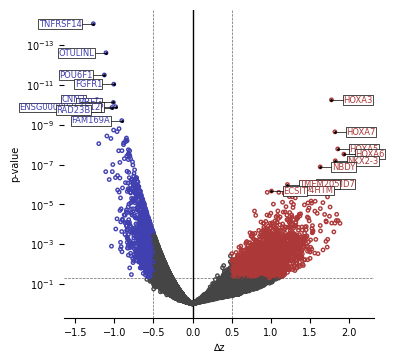

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CFH""",null,-0.419743,null,-0.300003,-0.071576,null,-0.034972,-0.331211,0.338654,-0.305222,-0.407625,-0.436365,-0.457552,-0.451397,-0.449195,-0.440591,-0.431809,-0.446545,null,-0.449215,-0.431296,null,null,-0.241238,-0.406321,-0.448796,-0.431973,-0.450129,null,-0.448103,-0.437409,-0.453296,-0.290196,-0.420021,-0.401995,-0.458831,…,null,null,null,null,null,null,null,null,null,null,null,null,0.44252,-0.254446,0.098552,-0.304644,null,null,0.466453,2.289905,null,-0.040876,-0.269321,null,1.095952,2.767053,-0.000606,0.307169,0.108583,null,1.671646,3.119914,0.09323,null,0.89003,0.007977,0.063627
"""GCLC""",null,-0.779628,null,3.251799,-0.035278,null,-1.062479,-0.856715,0.150343,0.229391,0.442985,0.120671,0.065886,-0.836676,0.066064,-0.146082,-1.850207,-1.659575,null,1.267079,-1.57713,null,null,-0.527841,2.907332,0.316861,0.474414,0.623558,null,-0.486678,-0.040041,-0.875383,-0.792107,0.064358,0.559348,-0.027198,…,null,null,null,null,null,null,null,null,null,null,null,null,0.312367,1.97465,0.677215,-0.65376,null,null,-0.651127,-0.360782,null,2.390925,0.637891,null,1.404549,0.850006,0.115577,0.337401,0.062388,null,0.147703,-0.261264,1.543592,null,0.654777,0.017185,0.098098
"""STPG1""",null,1.440963,null,0.720995,-0.604218,null,0.697071,-0.573471,0.013952,-0.894797,-0.936394,-1.394744,-0.699423,-1.214689,-0.647833,-0.423162,-1.437633,-1.186205,null,0.984154,-1.331961,null,null,1.661679,0.541317,0.343312,0.031733,-0.026622,null,-0.2936,1.730815,-1.377696,0.952192,-0.465656,0.803647,1.359714,…,null,null,null,null,null,null,null,null,null,null,null,null,-1.113547,-1.121598,-1.317772,0.436422,null,null,0.975286,3.146036,null,2.489418,0.430505,null,0.559789,1.910122,0.968459,0.883894,0.533805,null,1.48741,-0.193242,0.33781,null,0.799554,0.02522,0.1228
"""NIPAL3""",null,-0.434655,null,2.176189,-0.959271,null,2.316196,0.140326,0.168375,-0.756568,-0.131397,-1.266103,-1.051806,-1.144849,-0.7429,-0.758754,-1.308893,-1.098898,null,-0.503362,-1.28406,null,null,0.759854,1.341902,0.948253,-0.771478,0.304439,null,-1.321987,1.954701,-0.85027,0.5416,-0.945374,-0.015796,0.14694,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.737397,-0.370313,-0.98535,-0.502892,null,null,-0.098878,1.152939,null,3.033719,-0.039496,null,0.986585,1.119467,0.2718,0.718233,0.772891,null,1.417769,0.391624,1.068958,null,0.629617,0.032368,0.140436
"""CCM1""",null,-1.371004,null,0.776401,-0.929662,null,-0.032994,-0.413658,-0.371206,-0.82614,0.521171,-0.146989,-1.219237,-1.70419,-0.973312,-0.762246,-1.703531,-1.50283,null,-0.010456,-1.579245,null,null,0.862961,1.074216,-0.071216,0.334235,0.634832,null,0.370691,0.399638,0.520814,0.02939,-0.763595,-0.147578,0.718691,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.679755,0.195865,-0.436109,-0.648558,null,null,-0.252254,0.379769,null,2.195403,-0.031634,null,1.737907,1.516629,0.447772,-0.302201,0.446816,null,2.348388,0.01255,0.878572,null,0.599632,0.037998,0.153229
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""CD38""",null,0.283719,null,3.169849,-0.456701,null,0.393501,0.478465,0.867104,1.60371,0.137936,-0.574594,0.119681,-0.714681,-0.729394,-0.415706,-0.956575,-0.664674,null,-0.58691,-0.898181,null,null,0.425785,1.619141,2.279496,-0.968249,-0.75594,null,-0.91223,-0.060532,-0.568671,-0.722986,-0.546652,0.765047,-0.217491,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.402888,-0.988165,-0.904206,-0.586707,null,null,-0.952489,-0.62442,null,-0.732926,0.046737,null,-0.668041,-0.851923,1.130366,-0.846459,0.167956,null,-0.772027,-0.769326,-0.340861,null,-0.621609,0.001741,0.027995
"""ST7""",null,0.666891,null,2.605984,0.564914,null,-0.72342,-0.320416,-0.232627,-0.136091,1.243917,-0.988083,-1.066456,-0.650921,0.602906,0.425746,-0.638584,-0.852436,null,0.777016,-0.70173,null,null,-0.201966,1.069837,2.640167,0.623635,1.14771,null,-0.324063,1.738671,-0.124566,-1.273805,0.509743,0.674024,0.387743,…,null,null,null,null,null,null,null,null,null,null,null,null,-1.43527,-1.427949,-1.428024,-0.017695,null,null,-0.81885,-1.056997,null,-1.428388,-0.163136,null,-1.445543,-1.274431,-0.450811,-1.424205,-0.423768,null,-0.7581,-0.744189,-1.330097,null,-1.199965,8.8678e-9,0.000008
"""THSD7A""",null,-0.491301,null,-0.317074,-0.391713,null,0.010268,-0.021278,0.071762,-0.491301,-0.39447,3.35102,1.732693,0.359967,-0.471107,2.443584,-0.444713,-0.458666,null,-0.474496,-0.491301,null,null,0.093665,-0.370269,-0.488706,-0.488373,-0.470537,null,-0.112647,-0.0091,-0.143838,-0.40494,-0.437329,0.44565,-0.491301,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.491301,-0.491301,-0.491301,-0.488995,null,null,-0.491301,-0.425419,null,-0.491301,-0.477416,null,-0.491301,-0.488323,-0.465341,-0.371835,-0.488581,null,-0.395074,-0.377017,-0.491301,null,-0.569528,0.000043,0.003488
"""MPO""",null,0.386311,null,0.47071,0.294997,null,4.987777,1.028082,0.562809,0.129424,-0.473504,0.169293,-0.822221,0.488382,-0.823358,0.83779,0.511859,0.003306,null,1.257225,-0.387467,null,null,0.112621,-0.690398,0.970734,-0.817408,-0.825487,null,-0.6365,0.212363,0.661714,1.981697,-0.644516,0.919947,1.454571,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.763644,-0.812321,-0.814144,-0.390744,null,null,-0.611866,-0.535545,null,-0.783267,-0.296637,null,-0.805814,-0.598658,-0.643978,-0.645869,0.057646,null,-0.688756,-0.518103,-0.578444,null,-0.7241,0.000001,0.000378
"""YBX2""",null,-0.386894,null,-0.260759,3.685379,null,-0.377786,-0.45069,1.802552,-0.45069,5.234386,-0.45069,0.324067,-0.45069,-0.379758,0.270084,-0.188857,-0.393372,null,0.847933,-0.365166,null,null,-0.257045,-0.147017,1.955276,-0.45069,-0.410907,null,-0.45069,0.149841,-0.45069,-0.306995,-0.45069,0.006612,0.070711,…,null,null,null,null,null,null,null,null,null,null,null,null,-0.45069,-0.45069,-0.378893,-0.45069,null,null,-0.45069,-0.45069,null,-0.45069,-0.304373,null,-0.45069,-0.45069,-0.45069,-0.45069,-0.45069,null,-0.372687,-0.226631,-0.392963,null,-0.50933,0.000243,0.009495
…,…,…,…,…,…,…,…,…

Proteomics


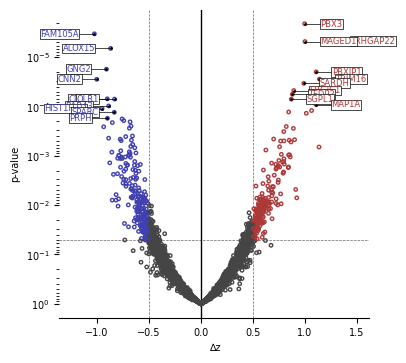

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABI2""",-0.00038,0.446361,0.621378,-1.859398,0.027657,-0.663311,-1.325522,-1.445407,-0.396778,-0.098791,0.531239,0.869249,0.948372,0.699159,-0.865544,0.148841,-1.09022,0.660662,0.269148,0.168001,-0.858856,0.320846,-0.994775,-0.56241,-1.207024,-1.491865,-0.249075,0.562969,0.573026,0.455199,1.056821,-0.124965,-1.684985,-0.363308,-1.724433,1.046542,…,0.119665,-1.201371,-0.561473,0.255244,1.114578,null,1.356915,2.06608,-1.626381,-2.310142,-0.227315,0.73389,2.248337,1.085851,1.833392,0.520226,0.829635,0.822285,-1.100177,0.853522,0.405793,1.215766,0.331605,-0.054619,0.634907,2.024571,0.40954,1.052702,0.49022,-1.590797,0.762579,0.116837,-0.706212,0.025253,0.568522,0.019375,0.499168
"""ADA""",0.150323,-0.236686,1.071398,-0.404753,-0.680808,0.376636,-1.361596,-0.852346,-1.101649,1.35638,2.023416,1.012907,-0.604391,0.110861,-1.201085,-0.69691,-1.829463,0.356384,-0.135248,0.151209,-0.94024,-0.073402,1.105175,0.727097,0.355903,1.259734,-0.965605,0.015348,0.414542,-0.500294,0.788741,-0.794098,0.451459,-0.242365,-1.813532,0.211688,…,-0.676428,-1.015473,-0.1633,-0.401074,1.482326,1.039979,1.529963,-0.012905,-1.304989,-1.899084,-1.523535,-0.052463,1.462789,0.266055,1.394282,-0.317747,1.364064,0.40476,0.679795,-0.364581,0.774818,1.429648,0.098414,1.496391,-0.348504,1.935064,-0.19557,1.027983,0.929765,-0.047218,1.365814,1.971706,-1.002386,-0.035936,0.511102,0.026802,0.55114
"""ADAM17""",-0.666384,1.25331,0.929364,-1.300409,-0.580253,-1.041285,-2.801405,-1.499057,-1.079686,2.045253,-0.161785,0.610431,0.500275,0.154016,0.436297,-0.497467,-1.231462,0.115612,1.58486,0.465919,-0.314397,-0.940521,-0.037255,0.156034,-0.881959,0.168965,0.413572,0.9796,0.443355,1.784549,0.158762,-2.308414,-0.460272,0.546896,-1.930236,0.552203,…,0.560236,-1.406506,0.332424,-0.605992,0.089265,-0.762977,1.643663,0.257746,0.927643,-1.446872,-1.189879,1.557243,1.41506,1.278792,0.612541,0.860124,0.391162,0.6482,0.168072,-0.074453,-0.116114,1.564268,2.20173,0.148279,-0.403171,1.646678,1.590453,-0.844473,0.434098,-1.960878,1.459884,0.596222,-0.965448,0.676797,0.60617,0.009438,0.364918
"""ADAM28""",0.610203,-0.21524,-0.519088,-1.16874,0.226055,1.328617,-2.310944,-1.406646,-1.433211,1.296521,-0.659952,-0.445038,-0.472825,-0.748718,0.51448,0.4418,null,0.195241,-0.327869,0.340643,-1.18858,-0.668759,-0.679001,-0.235522,0.394439,0.824642,0.320431,1.130868,1.070943,-0.398518,-0.025636,-0.089714,-0.758077,0.029635,-2.130536,0.692292,…,-0.441875,-1.36834,-0.472358,-0.315911,0.725586,-0.039189,1.336129,1.097859,0.365056,-1.410991,-0.961607,0.825128,1.973841,0.514718,1.270353,null,0.79024,1.029572,-0.001363,-0.64272,-0.506384,1.461514,0.746125,1.14402,0.861761,1.60946,1.865272,-0.081484,-0.134405,-2.016505,1.202859,-0.024318,-1.048745,0.38279,0.56378,0.015322,0.44259
"""ADGRG1""",1.46357,-0.258507,0.814099,null,-0.084481,1.505724,-1.442443,-1.406539,null,0.274614,1.084205,null,0.458675,0.12567,-0.418928,null,null,-0.82465,null,0.000014,-0.611383,-0.032806,null,-1.614963,-0.47618,-0.42993,nu

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ABCB1""",1.15259,-0.324431,-0.041026,0.427585,-0.247469,1.140462,-1.670743,-1.70481,-0.500964,0.907584,1.761952,-0.023557,-0.122592,-0.254873,-0.902476,1.621403,null,-0.236441,-0.002626,-0.143617,-0.004487,-0.210704,0.980329,-1.41987,0.490658,1.817677,-0.646658,0.810668,-0.573634,0.053742,0.507404,-1.53188,-0.877778,0.634729,-0.45717,1.297863,…,-0.492899,-1.15533,0.00695,-0.448846,-0.196852,-0.289072,0.557193,-0.587759,-1.619721,null,-0.691375,0.211539,-0.129223,-0.436889,2.502016,null,-0.057426,-0.447879,-1.546895,-0.780462,-1.387435,0.038231,0.329555,-1.983335,null,0.231702,null,null,null,-1.547344,0.348064,null,-1.510247,-0.76217,-0.547972,0.033616,0.573024
"""ABRACL""",0.113697,0.592662,1.567692,-0.42485,0.324708,0.823223,-1.686111,-1.691591,-0.131146,0.713592,0.953642,0.645533,0.631477,0.149838,-1.381083,0.364593,-1.426985,0.255976,0.582195,1.103802,-0.278788,-0.730761,0.552252,-0.969146,-0.451442,1.440512,0.1947,0.20075,1.069874,0.907231,0.656103,-1.982195,-0.500671,1.42569,-0.71385,0.84376,…,0.893509,-0.630083,1.102979,0.635763,0.63836,0.459669,0.935323,-0.296387,-0.441018,-2.468624,-1.912777,0.215954,0.065518,-0.449622,1.043636,0.815715,-0.266772,0.39816,-2.369929,-2.122427,-2.359047,-0.497641,0.770414,-1.943734,-0.609167,0.724866,0.920704,-0.605823,0.870998,0.060078,-0.830325,0.091862,-1.482429,0.341263,-0.528477,0.030262,0.558632
"""ACTBL2""",0.576413,-0.377116,0.80051,-1.137895,1.784574,0.643557,-0.398524,0.852547,0.666377,0.707253,-0.30709,-0.229244,1.064512,0.323046,-0.28181,1.445691,0.694643,-0.401608,0.008263,1.37815,0.301074,-0.89039,-0.569269,-0.830014,-1.024549,0.291425,0.18507,-0.208517,2.054634,0.191864,0.280273,-1.804339,-0.299032,1.17514,1.205528,0.331286,…,-0.561936,1.422211,-0.744472,2.378471,0.673089,1.586189,0.756601,-0.923146,-1.209937,-1.670417,-1.235461,0.013384,0.135016,-0.780633,1.295245,-0.051391,-0.815306,-0.004335,-0.955847,-0.383011,-1.277264,-0.68324,0.478259,-1.728258,-1.260917,-0.173773,0.388812,0.13473,1.507736,-1.46598,-0.893285,0.384711,-1.288488,-0.072843,-0.545989,0.00712,0.35568
"""ACTG1""",0.948471,0.117821,1.211225,-1.56718,1.130605,0.920404,-0.526554,0.035103,1.188717,1.082811,-0.887678,-0.034452,1.685606,0.652439,-0.900368,0.984374,-0.095107,0.283404,-0.707164,1.506665,0.371386,-0.956317,-1.212736,-0.033895,-0.970151,0.356139,1.065917,-0.609994,1.525275,0.276006,1.226828,-1.649671,0.326213,1.452867,0.090003,1.36765,…,0.572599,0.723162,0.536386,1.980316,0.777171,1.432394,0.717928,-0.829755,-0.966695,-1.68191,-0.969905,-0.365349,0.261701,-0.984302,1.414752,0.279779,-1.076836,0.850566,-0.416811,-1.549772,-1.413734,-1.149254,-0.140753,-1.934491,-1.389433,-0.020477,0.366102,0.126441,1.531835,-0.630223,-1.211755,0.370345,-1.592977,0.57251,-0.548466,0.01156,0.389192
"""ACTN1""",1.119465,0.683537,1.241898,-1.921813,1.607298,0.625964,-1.565053,-0.825129,1.147193,0.803298,-0.927829,0.321462,0.256033,-0.540092,0.028433,0.647505,0.888513,-0.290065,0.372715,1.598177,0.177178,-0.906135,-0.565158

Phosphoproteomics


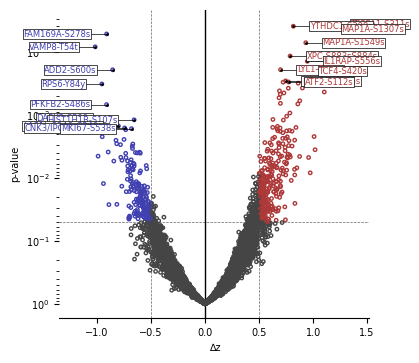

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""AAAS-S495s""",null,0.575293,-0.506975,0.153729,-2.132424,-0.811016,null,null,-2.12073,0.352525,0.870564,1.169342,-0.881179,-1.6062,0.701587,-1.54773,null,0.142035,0.814433,null,-1.26123,0.182964,1.134845,null,0.557168,0.346678,0.352525,0.76415,null,0.434382,-0.214628,null,-0.197087,-0.056761,-1.530189,-0.787628,…,1.251443,0.468995,0.882096,-0.737139,0.894614,-0.15861,-0.489434,0.977563,null,null,-0.483587,null,0.891028,0.730237,null,null,0.843668,0.194658,0.600435,0.545474,0.007556,1.331303,0.565354,0.489928,0.71562,0.95476,0.948913,-0.050914,-0.682383,-0.4602,0.965284,-0.413424,0.305749,1.157414,0.553306,0.002785,0.370855
"""ACIN1-S410s""",-0.103014,0.482353,-0.080356,-0.792438,-2.219645,0.380831,null,null,-2.354485,1.230227,1.197424,0.279415,null,-0.930702,null,-2.74761,-2.198733,0.397749,0.757831,-0.452122,-0.39559,0.140308,0.816446,-0.384676,0.899358,0.724473,0.086902,1.016825,-0.286329,1.419614,0.580179,-0.42461,0.216692,null,-2.394562,-0.132371,…,-1.066049,0.878213,-0.294933,1.239628,-0.366281,0.108687,1.65205,0.80254,0.309044,-1.332289,-1.725691,0.630256,0.967434,0.606491,0.516116,0.993455,0.71762,0.624675,-0.492141,0.483287,0.482486,null,1.059447,null,0.577089,1.370783,0.802247,-0.568538,-0.181703,0.977606,null,1.764375,-0.245783,-0.604306,0.533222,0.012297,0.496297
"""ACIN1-S655sS657s""",null,0.476823,null,-0.724904,null,null,null,-1.114269,-0.781984,1.205794,null,0.04516,null,-0.882786,null,1.14299,-1.2042,null,0.403572,0.291934,null,null,0.507849,null,null,0.407798,1.239234,null,null,1.153081,-1.139194,-1.31705,-0.223026,null,null,-0.272126,…,0.517688,-1.456997,-0.003491,-1.907089,0.846273,-1.019456,1.420207,null,-0.750506,-1.186677,null,null,1.572634,null,null,1.16272,-0.098688,0.435791,null,-1.158418,-0.753007,null,2.250974,null,0.980338,null,1.517539,0.547845,2.53731,-1.539999,null,1.326332,-0.399063,1.104324,0.658487,0.047454,0.69373
"""ADAR-T601t""",-0.257727,1.096093,-0.070833,-0.372804,-1.820731,-0.340424,-2.384128,-2.220598,-1.109619,0.878972,0.498107,0.560958,-0.170933,-1.29635,0.820336,-1.393177,-3.037376,0.417132,0.287532,-0.57059,-0.995455,0.270155,0.866322,-0.917937,0.619615,1.067183,0.536403,1.532184,-1.039904,1.632675,0.153729,-0.368456,-0.314657,-0.640787,-1.833744,-0.621831,…,null,null,0.745262,-2.380486,0.226309,-1.801324,0.712924,1.167321,0.572913,-1.127725,-1.003738,0.768529,1.840389,0.60991,0.039564,0.412246,-0.051013,0.380449,0.217899,-0.666845,1.098236,1.030763,1.690572,0.483634,0.06908,1.516524,1.580889,-0.602717,-1.170583,0.24256,0.85971,0.759733,-0.217072,1.121789,0.574656,0.00381,0.39546
"""AFF1-S750s""",null,0.356465,-0.49676,-1.065898,null,-1.030482,null,null,-1.989901,1.543124,1.15378,-0.211002,-0.983242,-1.377344,0.77608,-1.30888,-0.932658,0.396717,1.310557,-0.473253,-1.047737,-0.983209,1.286104,-0.284953,0.871674,0.331154,-0.171786,null,-1.448951,1.169766,-0.314387,0.148956,-0.707891,null,null,-0.680181,…,null,null,0.329567,-2.143653,-0.413112,-1.945284,2.170102,1.465579,0.615612,-1.216

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ADD1-S586s""",-0.075773,0.269124,1.29825,-0.34709,-0.494313,1.469931,-1.621339,0.434171,-0.493121,-1.095439,0.58677,-0.42802,-1.436249,-1.797927,1.74695,0.838291,0.402633,-0.19788,1.071848,0.565569,-0.47986,0.753121,1.066732,-2.364681,0.576922,-0.832633,-0.738225,-0.474007,-0.455702,0.976584,1.25417,-1.712584,-1.44026,1.10519,0.035316,0.005941,…,1.070629,-0.712339,0.177936,-0.782572,0.12856,1.575278,-0.667081,-1.579406,0.270678,0.142321,-1.847679,-0.223897,0.613964,-1.779409,-0.375438,0.109705,0.240418,-0.284584,-0.826158,-1.56743,-0.788825,-0.022541,0.519727,-2.051963,0.01255,-0.430799,0.849582,-1.023888,0.364548,-0.437977,-0.364639,-1.622935,0.747615,0.312853,-0.54416,0.006438,0.425824
"""ADD2-S592s""",null,null,0.423746,0.664334,null,-0.550888,null,null,null,0.64364,-0.60809,-1.523104,null,-0.848266,2.060924,0.683651,-0.579063,-0.105337,0.520896,1.312055,-1.102688,-1.060118,1.105855,-0.763787,null,1.117783,0.990657,null,0.165919,1.306852,1.199609,-1.455889,-0.62512,null,null,null,…,0.472344,0.996133,0.285365,1.10813,0.006999,-1.635386,-0.243707,null,-1.107294,-1.470474,-1.235081,-0.802711,null,null,-0.493214,0.810242,-1.171561,-0.650289,null,-1.934556,-1.807674,null,null,null,-0.898675,0.521049,-0.139,-0.849664,-0.000135,null,null,1.997076,-1.544823,-0.025878,-0.768614,0.005303,0.41173
"""ADD2-S600s""",-0.04324,null,null,-0.398322,1.927553,null,null,null,0.625174,0.001222,0.029462,0.093777,null,-0.712109,null,0.806744,null,null,0.286788,null,null,null,1.184927,-0.804026,1.768332,1.160613,-0.129063,0.993296,null,null,3.037053,null,0.094015,0.005519,-1.164342,-0.465781,…,0.601858,0.25217,-0.145518,0.421507,null,null,-0.560948,0.000801,null,-1.730754,null,-0.949341,-0.383424,-0.696416,null,null,-2.128857,0.598259,-1.249801,null,-0.740452,null,-0.401712,-1.341903,-0.858923,null,0.113913,-0.625017,-0.071085,-1.148576,null,0.781183,-1.345097,-0.082645,-0.85472,0.000195,0.156903
"""ADD2-S693s""",-0.159796,2.033553,null,1.054655,null,null,null,-1.249196,-0.712381,null,null,-0.38481,null,-1.400717,null,-1.129455,-2.407425,null,0.587927,null,null,null,1.918516,null,1.818134,null,0.098205,2.282173,null,null,0.401171,null,-0.106824,null,-1.728068,-0.497261,…,-0.055397,-0.867609,0.163804,-1.059359,null,-1.318927,-0.590044,0.063858,null,null,-1.609213,null,-0.972007,null,null,-0.024928,null,0.649923,null,null,-1.463682,null,null,null,null,null,null,null,null,null,null,null,-0.959963,null,-0.70411,0.045487,0.676608
"""ADD2-S701s""",0.380452,2.250859,-0.948428,0.681224,-0.796922,-0.678766,-0.727062,null,-0.206311,1.190526,0.144871,-1.08073,1.064398,-0.580678,2.159203,-1.383559,null,-0.487798,0.883927,1.073093,-0.992298,-0.794885,1.853604,-1.102974,2.152396,1.355809,0.3148,1.070331,0.34632,1.769859,0.272863,null,-0.562488,1.063599,-1.224011,-0.85301,…,0.378626,-1.784498,-0.296511,0.492026,-0.032671,-1.295787,0.025808,-0.094933,-1.09253,-3.192104,-2.436787,null,-0.59825,-1.252637,-0.6408,-0.146156,-0.424018,-0.027007,-0.581962,-1.139609,0.2481

Acetylomics


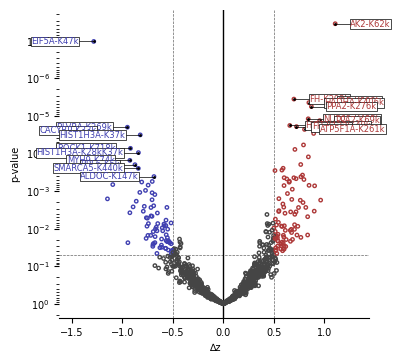

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACADVL-K278k""",-1.875764,0.65362,null,1.331979,null,-1.148325,0.20068,null,null,0.807873,-2.410388,0.192179,1.182986,-1.209675,-0.106247,null,null,-1.104503,-0.219306,-3.558514,null,0.918303,null,-0.153574,0.840301,-0.320972,0.228551,0.753534,null,0.84293,null,-0.841573,null,null,0.671149,0.478334,…,-0.413385,-1.717134,-0.738951,-0.788826,-0.23611,-1.507765,0.841177,0.363521,1.384565,null,0.624698,1.147928,0.575618,-0.68031,-0.001951,-0.552351,0.553707,null,0.61681,0.777197,0.476581,1.244336,0.449412,null,1.57738,0.136815,0.580877,-0.018603,0.941967,-0.018603,0.733376,-0.569003,0.022589,0.439531,0.629937,0.00048,0.013208
"""ACLY-K538k""",null,-0.917926,null,-0.227499,null,-0.627729,0.161848,null,null,1.894565,0.51613,0.443581,-0.080224,null,0.075273,null,null,null,-0.636193,-0.505604,null,null,0.704758,null,-1.478973,-0.801847,1.023974,0.050001,-0.879233,1.749466,0.184822,null,-1.503156,-1.110181,-0.488676,-0.564853,…,-0.741804,0.748877,-0.131444,0.081022,null,-1.499901,1.483453,1.374629,-0.399199,-0.029109,0.843811,-0.026869,1.205347,1.483453,0.649137,null,-0.090139,-0.460866,-1.205704,0.517339,null,1.435086,0.482274,0.32992,0.447208,-0.307303,0.296064,null,0.218678,null,1.119497,-0.915507,null,0.220898,0.51692,0.015731,0.11276
"""AK2-K181k""",-1.18976,-0.236837,-0.039505,-0.084084,-1.527168,-0.485292,-0.324768,null,null,0.004921,0.457405,-0.961754,0.082473,-2.559841,1.898036,-0.762376,null,-1.148862,0.430822,null,-2.099739,1.601526,-0.346239,-0.518011,-0.474046,0.235534,1.039179,2.041179,0.008806,null,-0.293072,null,1.151648,-0.150952,-0.988337,null,…,1.084123,-0.981303,0.45909,0.250867,-0.288318,-0.833516,1.31524,1.059628,null,null,-0.368733,0.565785,null,-0.529258,0.00809,0.690524,1.192546,0.675187,1.744668,null,-0.186737,1.039179,0.851048,1.540179,null,0.708928,null,null,null,-2.498494,1.028954,null,0.807083,0.700421,0.673736,0.010508,0.089318
"""AK2-K62k""",null,0.21108,null,-0.873931,null,null,null,null,null,-0.525266,0.034673,-0.466939,-0.133827,-1.738467,null,null,null,null,2.551807,-0.561558,null,null,-1.621813,1.368417,-0.565447,0.824032,1.761152,null,null,null,null,null,-0.386577,0.616647,null,-1.453313,…,-0.641978,null,null,null,null,-1.845548,1.266021,0.305829,0.393708,null,0.312051,1.133813,0.545359,1.373602,null,0.831809,0.725524,0.768297,0.800701,1.748191,null,0.847363,1.812998,0.733301,null,null,null,null,null,null,0.834401,null,0.150809,null,1.109314,3.5908e-8,0.000034
"""ANXA1-K161k""",null,-2.550991,null,-1.375543,0.934506,-0.061708,0.120862,0.519347,null,-0.750304,-2.150839,-0.228438,-2.542655,-0.216767,-1.200476,null,null,null,0.538521,null,null,null,null,0.668571,null,-0.522717,-0.145907,null,1.567248,null,null,null,null,0.687745,null,null,…,-0.657371,0.192904,-0.265685,1.0931,0.06783,0.123909,-0.020859,null,null,null,0.320938,1.433863,null,1.292142,0.683577,-0.900361,0.475164,null,0.856143,null,1.142085,0.558529,0.225068,0.689412,0.070009,null,0.711087,0.934506,0.67524,null,-0.055872,0.585206,0.405137,-

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ACIN1-K359k""",1.450628,3.188764,0.760562,-0.465213,1.320916,null,null,null,null,-0.831,0.790396,-0.692208,-1.545711,0.215773,null,2.099186,1.450628,0.259875,-0.122774,0.654198,0.358456,-0.12926,-0.012909,null,null,0.01817,-0.221355,0.17686,null,1.684109,-0.31345,-0.293994,-0.728528,0.045462,null,null,…,-0.339123,-1.976493,0.668337,1.152762,-0.49835,0.915808,0.865628,null,0.515407,null,null,-1.026864,null,-1.229215,null,0.232636,-0.684426,-1.454913,-1.041133,-3.180078,-1.057995,-0.701288,-0.270646,0.329919,null,-0.283617,null,null,null,-1.249968,-0.449648,null,-0.531366,0.318154,-0.750848,0.005293,0.05963
"""ACTR2-K336k""",null,null,null,0.877819,1.606323,0.673577,0.184438,null,null,-0.246681,null,0.081667,0.36006,0.084269,-1.710975,-0.139616,null,null,-0.275821,null,null,null,-0.668953,null,-0.828964,-0.196856,1.137999,null,-0.045952,null,-1.958147,null,0.170128,null,1.762432,null,…,0.696218,0.304634,1.041496,2.052852,null,1.122801,-0.83807,-0.568784,null,1.671368,null,null,null,-1.351927,-0.001591,null,-0.957753,0.391281,-1.789029,null,-1.164597,-0.544067,-0.175912,null,-1.444291,null,-1.05402,-1.148986,-0.017202,-3.037895,-1.44299,-0.949948,0.200049,1.47275,-0.892613,0.002655,0.038585
"""ALDH4A1-K402k""",0.3464,null,0.587996,1.809253,0.340205,-0.096881,-0.791671,null,null,0.616315,null,0.239318,1.694207,null,-1.376635,0.640209,null,-1.367785,-2.261604,null,1.278272,-0.362461,0.301266,null,null,-0.008827,-0.395204,-1.739472,1.04818,null,-1.173092,null,0.536668,0.316311,null,null,…,-0.337838,0.048868,-1.049293,1.023939,-0.4895,0.906363,null,null,null,null,-0.125289,null,null,-1.314687,-0.305823,null,-1.013798,-0.905832,0.731361,null,null,-0.680164,null,-1.473982,null,-0.934151,null,null,null,null,-0.142988,null,null,-0.054742,-0.670888,0.010277,0.089318
"""ALDOA-K13k""",null,-1.107549,0.652325,-0.213138,1.238284,0.354854,null,null,1.427948,-0.655352,0.29496,-0.158235,null,-0.027577,-1.15746,1.986955,-0.199162,-0.775139,1.298178,1.148444,1.547735,0.455675,-0.922877,0.73418,-0.772145,-0.296989,-0.58348,null,1.687487,-0.552535,-1.277248,null,-0.383834,0.959779,1.807274,-0.45371,…,0.255765,-0.317973,0.145732,1.662746,-0.110671,-0.159495,-0.97179,-0.85899,1.43793,-0.129187,-2.235545,0.209112,-1.766379,-1.077602,0.344871,-0.18918,0.33988,-0.221123,null,null,-0.996746,-1.836255,0.484623,-1.556751,0.029232,-1.047655,0.186153,-1.526804,0.077346,-1.50684,1.21832,-0.119504,-0.869971,-0.973623,-0.688767,0.002481,0.038585
"""ALDOC-K147k""",1.352033,-0.132345,0.021223,-0.866955,1.421996,0.079409,1.52694,0.755017,1.806791,0.066874,0.764345,0.13293,0.871621,-0.49965,-1.493123,0.69788,-0.669893,-0.111357,0.128149,0.50315,0.661733,1.089672,0.008396,0.566117,-0.046175,-0.218633,-0.232626,-0.157999,-0.08687,0.339904,-3.347138,0.13328,0.247786,-1.807955,1.78347,-0.095032,…,null,null,0.698721,2.063434,-0.250822,-0.375613,-1.201611,-1.644709,-1.551425,0.390044,-0.654735,-1.889579,-0.74452,-0.318913,0.216303,0.239624,-0.584772,0.166979,-0.964903,0.433

Lipidomics


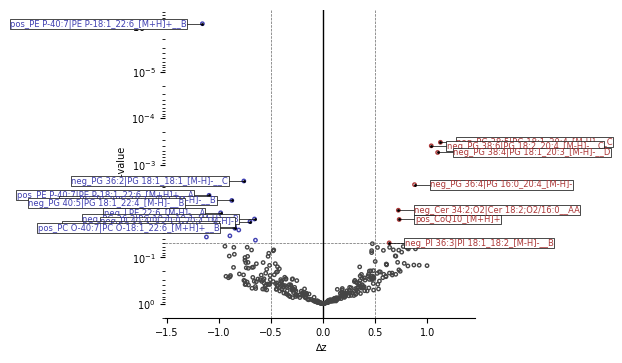

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_PG 38:6|PG 18:2_20:4_[M-H]…",-0.742087,1.078655,1.91827,-1.141714,-1.008244,-0.578941,-0.113546,-2.290288,-1.276848,1.298192,-0.198308,-0.06157,-1.61428,-0.060887,0.016007,1.591977,-1.000198,-0.731714,0.711492,1.059504,-0.737057,null,0.824229,-0.520132,-0.081639,-0.127476,0.492874,-0.924628,null,null,null,1.178657,null,null,null,null,…,null,null,null,null,null,null,0.474994,null,null,null,null,0.92813,0.314859,0.982158,1.485137,null,null,null,null,null,1.474867,null,null,null,null,null,0.543818,null,null,null,null,null,null,null,1.037597,0.000393,0.044775
"""neg_PG 36:4|PG 16:0_20:4_[M-H]…",-0.316601,0.087594,-0.196742,-1.013199,-0.780456,-1.066312,1.191394,-0.160193,-2.269275,0.281452,1.302038,-0.159819,-0.81433,1.398229,0.110227,1.292145,0.402274,-0.204803,1.376283,1.257814,-0.632996,null,-0.432917,-0.751568,0.942824,-0.385994,-0.879761,-0.49474,null,null,null,0.687891,null,null,null,null,…,null,null,null,null,null,null,0.15444,null,null,null,null,1.41161,0.643676,0.662746,1.472513,null,null,null,null,null,0.421202,null,null,null,null,null,0.478129,null,null,null,null,null,null,null,0.877098,0.0027,0.153922
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.060139,0.234452,1.993004,-1.305668,-1.058584,-0.454706,-0.019522,-1.56532,-1.702208,1.070281,0.023995,0.408315,-1.763285,-0.541703,-0.490529,1.348156,-0.347801,-0.990029,-0.28951,0.748162,-1.01619,null,1.754949,-1.298473,-0.200029,-0.51216,0.103243,-0.734497,null,null,null,0.519305,null,null,null,null,…,null,null,null,null,null,null,-0.017078,null,null,null,null,0.961613,0.67597,1.069748,1.240394,null,null,null,null,null,1.484024,null,null,null,null,null,1.315295,null,null,null,null,null,null,null,1.125569,0.00033,0.044775
"""neg_PI 36:3|PI 18:1_18:2_[M-H]…",-0.430546,-0.057657,-1.501212,-2.011983,0.121467,0.003125,0.559475,-2.2841,-1.088657,0.758411,-0.030606,-0.599212,-1.031363,-0.433041,0.32675,2.959132,-0.960177,0.427156,0.144653,0.369369,-0.631076,null,1.53345,0.042624,-1.0948,-0.412789,-0.571178,-1.528276,null,null,null,1.544776,null,null,null,null,…,null,null,null,null,null,null,0.81894,null,null,null,null,0.044607,0.59759,-0.029944,1.741965,null,null,null,null,null,0.640962,null,null,null,null,null,-0.022761,null,null,null,null,null,null,null,0.634095,0.048623,0.649296
"""neg_PG 38:4|PG 18:1_20:3_[M-H]…",-0.523044,0.266284,0.024675,-1.752259,-1.07877,-0.708022,0.867888,-2.070922,-1.461567,0.697949,0.554184,-0.005348,-0.833056,-0.095019,1.080383,2.61824,-1.018769,-1.163923,0.151356,0.379981,-0.255105,null,1.009712,-0.528324,-0.606552,-1.045158,0.020774,-0.340747,null,null,null,1.006108,null,null,null,null,…,null,null,null,null,null,null,0.515885,null,null,null,null,1.621928,0.489748,0.290762,1.457772,null,null,null,null,null,1.247868,null,null,null,null,null,0.945998,null,null,null,null,null,null,null,1.098809,0.000547,0.046743
"""neg_Cer 34:2;O2|Cer 18:2;O2/16…",0.508585,-0.027597,0.826119,-0.705614,-0.123128,-1.002291,-0.113925,0.689102,-0.597968,-1.356178,-0.939039,0.2655

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""neg_LPE 22:6_[M-H]-__A""",-0.445181,0.88255,-1.654498,1.462745,0.605957,0.989506,0.920059,1.557894,1.532592,-1.197453,0.977269,0.916362,0.881925,-1.435496,-0.643177,-0.79822,-0.272524,1.312623,-0.607222,-0.264926,-0.10585,null,-0.213918,1.956848,0.229763,2.356411,-0.759389,1.10258,null,null,null,-0.257326,null,null,null,null,…,null,null,null,null,null,null,-0.26057,null,null,null,null,-1.313909,0.552071,-1.434006,-1.026238,null,null,null,null,null,-1.377353,null,null,null,null,null,-1.013776,null,null,null,null,null,null,null,-0.982374,0.010932,0.339877
"""neg_PG 38:5|PG 18:1_20:4_[M-H]…",-0.251563,-3.181749,0.488636,0.563813,-1.152951,0.878826,0.36775,-1.08796,0.861802,1.920182,-0.190746,-0.292129,0.939145,-1.819524,0.804101,-1.08624,0.143314,0.86448,0.624891,2.080631,0.566788,null,-0.772436,1.736808,0.289063,-0.100857,0.457225,-0.162733,null,null,null,-0.465867,null,null,null,null,…,null,null,null,null,null,null,0.464189,null,null,null,null,-0.199693,-1.599609,-1.188403,-1.342656,null,null,null,null,null,-0.670127,null,null,null,null,null,-0.546724,null,null,null,null,null,null,null,-0.850122,0.020907,0.47668
"""neg_PG 40:5|PG 18:1_22:4_[M-H]…",-0.194854,-3.522088,-1.085501,1.932416,-0.373389,0.656399,0.293127,0.371826,0.417086,0.483863,0.096533,0.411124,0.055384,-0.690536,-0.030269,0.030971,0.748966,0.888665,0.16319,0.162884,0.924385,null,-0.747916,1.190922,0.594051,-0.846254,0.824728,0.786211,null,null,null,-0.788312,null,null,null,null,…,null,null,null,null,null,null,-1.514557,null,null,null,null,null,-1.346544,-0.118558,-1.941573,null,null,null,null,null,-0.90955,null,null,null,null,null,-0.332806,null,null,null,null,null,null,null,-1.177596,0.006768,0.257172
"""neg_PG 36:2|PG 18:1_18:1_[M-H]…",0.007687,-2.164926,-0.139675,-0.058339,-0.680745,2.375887,-0.005477,-0.152341,2.091876,0.533772,-0.23079,0.356608,-0.106292,-1.521987,-0.695074,-1.127857,-0.214618,0.806427,-0.218346,1.462364,0.049406,null,-0.777822,0.593358,-0.380924,0.038467,0.128917,-0.335296,null,null,null,-0.871562,null,null,null,null,…,null,null,null,null,null,null,-0.278244,null,null,null,null,-1.119428,-0.219157,-1.251068,-0.743396,null,null,null,null,null,-0.300428,null,null,null,null,null,-0.020567,null,null,null,null,null,null,null,-0.657665,0.014873,0.400417
"""neg_PG 36:2|PG 18:1_18:1_[M-H]…",0.21554,-1.939957,0.014337,-0.375324,-0.652263,2.590108,-0.058202,-0.319567,1.873386,0.384076,-0.313102,0.175363,-0.385474,-1.279989,-0.328281,-1.144756,-0.278373,0.749681,-0.241927,1.099754,0.368033,null,-0.795581,0.403932,-0.302882,-0.310808,0.39028,-0.653364,null,null,null,-0.595925,null,null,null,null,…,null,null,null,null,null,null,-0.392742,null,null,null,null,-1.07835,-0.094012,-1.112298,-0.607706,null,null,null,null,null,-0.926034,null,null,null,null,null,-0.334342,null,null,null,null,null,null,null,-0.76022,0.002251,0.153922
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…

Metabolomics


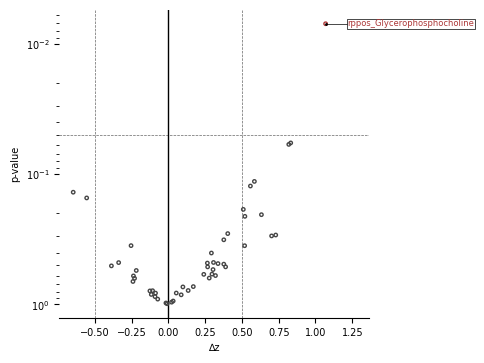

Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""rppos_Glycerophosphocholine""",-1.546781,-0.53245,0.162322,0.334721,-0.56786,-1.216147,-0.081339,-0.683181,-1.726639,0.905563,2.457279,-1.565826,1.280441,1.697364,0.090142,-0.007791,-0.789959,-1.483493,-0.058071,0.818816,-1.224012,null,-0.39918,-1.064859,-0.426491,-0.616062,-0.099802,-0.511531,null,null,null,0.226598,null,null,null,null,…,null,null,null,null,null,null,-0.209355,null,null,null,null,1.163582,1.067879,1.198293,0.15709,null,null,null,null,null,2.023239,null,null,null,null,null,0.988807,null,null,null,null,null,null,null,1.068633,0.007048,0.345367


Feature,13-00033,13-00034,13-00077,13-00149,13-00160,13-00186,13-00226,13-00468,13-00558,13-00602,14-00127,14-00193,14-00528,14-00423,14-00434,14-00514,14-00608,14-00613,14-00711,14-00712,15-00043,15-00888,15-00137,15-00302,15-00287,15-00377,15-00563,15-00578,15-00742,15-00777,15-00813,15-00837,15-00855,15-00870,15-00976,16-00001,…,16-00494-Bridge,16-00627-Bridge,16-01100-Bridge,16-01191-Bridge,17-00741-Bridge,17-00881-Bridge,11-00503,11-00475,11-00376,11-00378,11-00466,12-00123,13-00262,13-00450,14-00495,15-00872,15-00983,16-00041,16-00109,16-00289,16-00292,16-00459,16-00836,16-00844,17-00963,16-01225,17-00025,17-00551,17-00613,17-00775,17-00849,17-00915,19-00154,17-00025-Bridge,delta_z,ttest_p,ttest_p_adj
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64


In [43]:
# key: (subset_id, block)
# value: {"up": top_n_up_df, "down": top_n_down_df}
top_up_and_down = {}

for subset_id in [
    "B_NPM1-WT", 
    "W_NPM1-WT", 
    "B_FLT3-ITD-WT", 
    "W_FLT3-ITD-WT", 
    "B_FLT3-ITDxNPM1-WT", 
    "W_FLT3-ITDxNPM1-WT"
]:
    print("============", subset_id, "============")
    for block in [
        "Transcriptomics", 
        "Proteomics", 
        "Phosphoproteomics",
        "Acetylomics",
        "Lipidomics",
        "Metabolomics"
    ]:
        if (df := comps.get((subset_id, block))) is not None:
            print(block)
            top_up, top_down = plot_volcano_and_select_top_features(
                df,
                0.5,   # effect size
                0.05,  # adjusted ttest p value
                subset_id,
                block
            )
            display(top_up)
            display(top_down)
            top_up_and_down[(subset_id, block)] = {"up": top_up, "down": top_down}

### Compare counts of selected features between black and white patients

#### NPM1

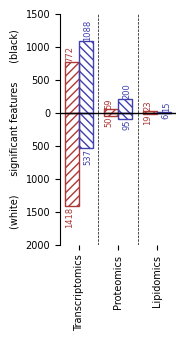

In [44]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_NPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_NPM1-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_NPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_NPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_NPM1-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_NPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_NPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITD

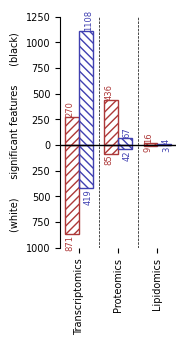

In [45]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_FLT3-ITD-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_FLT3-ITD-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITD-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_FLT3-ITD-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_FLT3-ITD-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_FLT3-ITD-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITD-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()


#### FLT3-ITDxNPM1 vs. WT

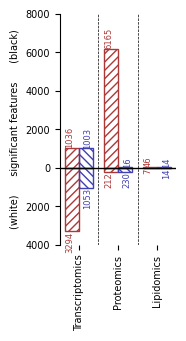

In [46]:
# bar data
x = list(range(1, 4)) * 2
all_up = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Transcriptomics")]["up"]), 
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Proteomics")]["up"]),
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Lipidomics")]["up"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Transcriptomics")]["up"]), 
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Proteomics")]["up"]),
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Lipidomics")]["up"]),
]
all_down = [
    # black patients
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Transcriptomics")]["down"]), 
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Proteomics")]["down"]),
    len(top_up_and_down[("B_FLT3-ITDxNPM1-WT", "Lipidomics")]["down"]),
    # white patients (negative values)
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Transcriptomics")]["down"]), 
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Proteomics")]["down"]),
    -len(top_up_and_down[("W_FLT3-ITDxNPM1-WT", "Lipidomics")]["down"]),
]


# figure and subpanels
fig, ax = plt.subplots(
    figsize=(1.5, 3),
)

# misc parameters
w = 0.35                # bar width
lw = 1                  # line width for borders
hatch = "////"          # hatching for up bars
hatch_down = r"\\\\"    # hatching for down bars
count_pad = 5           # pad the counts from the ends of the bars by a bit


# plot counts of upregulated features
ax.bar(
    x, 
    all_up,
    width=-w,  # align to right edge
    align="edge",
    facecolor="#00000000",
    edgecolor=RED,
    linewidth=lw,
    hatch=hatch
)
# label each bar with the count (if count > 0)
for _x, _all_up in zip(x, all_up):
    if _all_up != 0:
        ax.text(
            _x - w / 1.5,
            _all_up + count_pad if _all_up > 0 else _all_up - count_pad,
            str(_all_up if _all_up > 0 else -_all_up),
            va="bottom" if _all_up > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=RED
        )

# plot counts of downregulated features
ax.bar(
    x, 
    all_down,
    width=w,  # align to left edge
    align="edge",
    facecolor="#00000000",
    edgecolor=BLUE,
    linewidth=lw,
    hatch=hatch_down
)
# label each bar with the count (if count > 0)
for _x, _all_down in zip(x, all_down):
    if _all_down != 0:
        ax.text(
            _x + w / 1.5,
            _all_down + count_pad if _all_down > 0 else _all_down - count_pad,
            str(_all_down if _all_down > 0 else -_all_down),
            va="bottom" if _all_down > 0 else "top",
            ha="center",
            rotation="vertical",
            fontsize=6,
            color=BLUE
        )


# customizations
ax.axhline(0, c="k", lw=1.)
for vlx in [1.5, 2.5]:
    ax.axvline(vlx, c="k", lw=0.5, ls="--")
for d in ["top", "bottom", "right"]:
    ax.spines[d].set_visible(False)
ax.set_xticks(range(1, 4))
ax.set_xticklabels(
    [
        "Transcriptomics",
        "Proteomics",
        "Lipidomics",
    ],
    rotation="vertical"
)
ax.set_ylabel("(white)      significant features      (black)")
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([
    _.get_text().lstrip("−")
    for _ in ax.get_yticklabels()
])

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        "BW_FLT3-ITDxNPM1-WT_sig-feat-counts.png"
    ),
    dpi=400,
    bbox_inches="tight",
    transparent=True
)
plt.show()
plt.close()
